Random Forest

------------------------------------------------------------
DATASET INFORMATION
------------------------------------------------------------
Dataset Shape: (423, 911)

Available Phases:
<StringArray>
['phase1', 'phase2', 'phase3']
Length: 3, dtype: str

Total Features: 908

------------------------------------------------------------
TRAINING FOR PHASE 1
------------------------------------------------------------
Original Shape: (141, 908)
Class Distribution: [99 42]

Shape After Variance Threshold: (141, 898)
Shape After SelectKBest: (141, 240)

Predicted Distribution:
[15 14]

Actual Distribution:
[20  9]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.70      0.80        20
           1       0.57      0.89      0.70         9

    accuracy                           0.76        29
   macro avg       0.75      0.79      0.75        29
weighted avg       0.82      0.76      0.77        29

Precision Score: 0.5714
Recall S

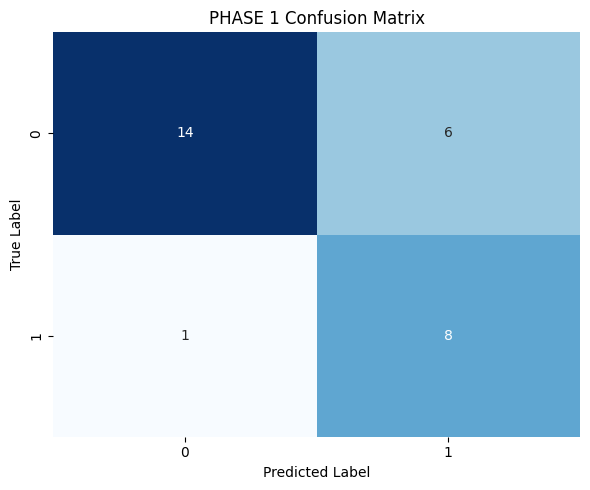


------------------------------------------------------------
TRAINING FOR PHASE 2
------------------------------------------------------------
Original Shape: (141, 908)
Class Distribution: [99 42]

Shape After Variance Threshold: (141, 897)
Shape After SelectKBest: (141, 240)

Predicted Distribution:
[16 13]

Actual Distribution:
[20  9]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.70      0.78        20
           1       0.54      0.78      0.64         9

    accuracy                           0.72        29
   macro avg       0.71      0.74      0.71        29
weighted avg       0.77      0.72      0.73        29

Precision Score: 0.5385
Recall Score: 0.7778
F1 Score: 0.6364
ROC-AUC Score: 0.8222

Confusion Matrix:
[[14  6]
 [ 2  7]]


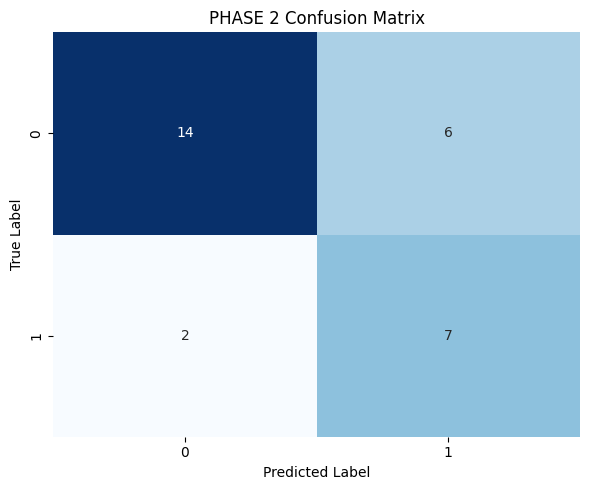


------------------------------------------------------------
TRAINING FOR PHASE 3
------------------------------------------------------------
Original Shape: (141, 908)
Class Distribution: [99 42]

Shape After Variance Threshold: (141, 898)
Shape After SelectKBest: (141, 240)

Predicted Distribution:
[21  8]

Actual Distribution:
[20  9]

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.75      0.73        20
           1       0.38      0.33      0.35         9

    accuracy                           0.62        29
   macro avg       0.54      0.54      0.54        29
weighted avg       0.61      0.62      0.61        29

Precision Score: 0.375
Recall Score: 0.3333
F1 Score: 0.3529
ROC-AUC Score: 0.6333

Confusion Matrix:
[[15  5]
 [ 6  3]]


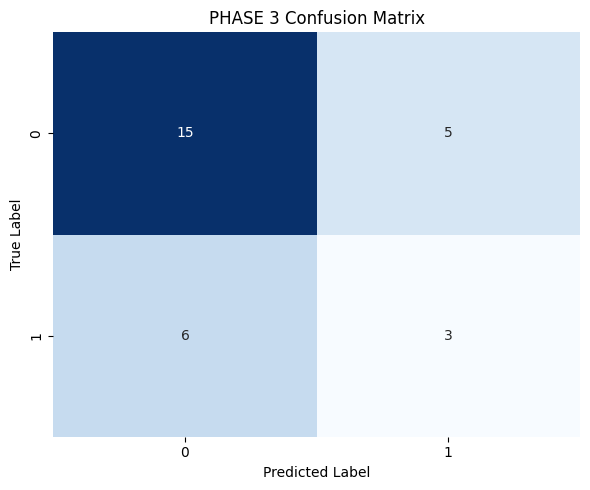


------------------------------------------------------------
FINAL ROC-AUC SCORES
------------------------------------------------------------
Phase 1 ROC-AUC: 0.8389
Phase 1 Precision: 0.5714
Phase 1 Recall: 0.8889
Phase 1 F1 Score: 0.6957

Phase 2 ROC-AUC: 0.8222
Phase 2 Precision: 0.5385
Phase 2 Recall: 0.7778
Phase 2 F1 Score: 0.6364

Phase 3 ROC-AUC: 0.6333
Phase 3 Precision: 0.3750
Phase 3 Recall: 0.3333
Phase 3 F1 Score: 0.3529


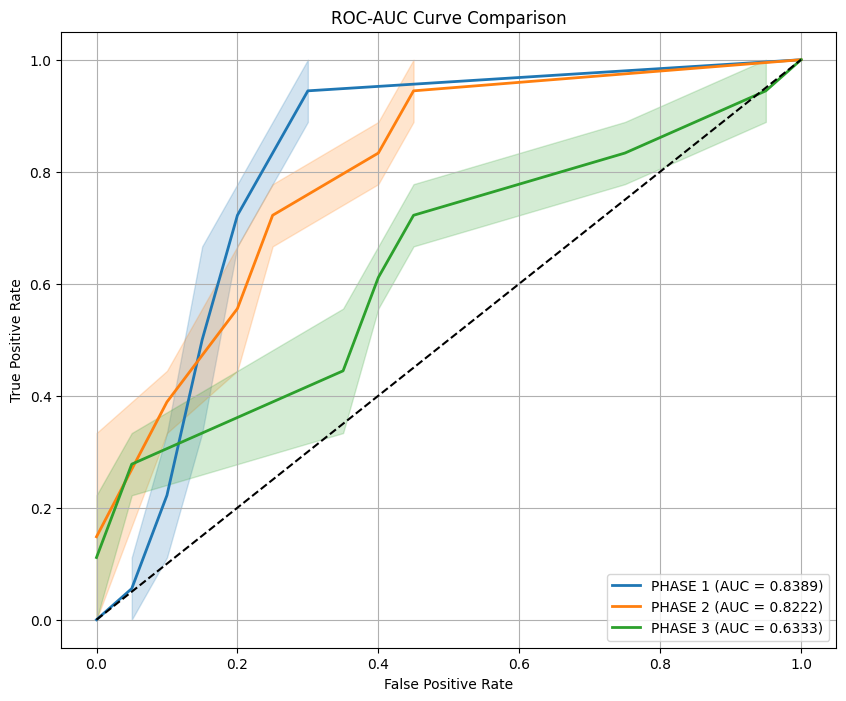

In [5]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.feature_selection import (
    VarianceThreshold,
    SelectKBest,
    mutual_info_classif
)

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_curve
)

import matplotlib.pyplot as plt
import seaborn as sns

# load dataset
df = pd.read_csv("../../data/multimodal_audio_text_features.csv")

print("-" * 60)
print("DATASET INFORMATION")
print("-" * 60)

print("Dataset Shape:", df.shape)

# normalize phase column
df["phase"] = df["phase"].astype(str).str.lower().str.strip()

print("\nAvailable Phases:")
print(df["phase"].unique())

# remove non-feature columns
remove_cols = [
    "participant_id",
    "phase",
    "label"
]

feature_cols = [
    col for col in df.columns
    if col not in remove_cols
]

print("\nTotal Features:", len(feature_cols))

# store roc data
roc_data = {}

# training function
def train_phase_model(df_phase, phase_name):

    print("\n" + "-" * 60)
    print(f"TRAINING FOR {phase_name}")
    print("-" * 60)

    # drop missing values
    df_phase = df_phase.dropna()

    # features & labels
    X = df_phase[feature_cols]
    y = df_phase["label"].values

    print("Original Shape:", X.shape)
    print("Class Distribution:", np.bincount(y))

    # remove low variance features
    variance_selector = VarianceThreshold(
        threshold=0.00001
    )

    X = variance_selector.fit_transform(X)

    print("\nShape After Variance Threshold:", X.shape)

    # keep important multimodal features
    kbest_selector = SelectKBest(
        score_func=mutual_info_classif,
        k=min(240, X.shape[1])
    )

    X = kbest_selector.fit_transform(X, y)

    print("Shape After SelectKBest:", X.shape)

    # train test split
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        stratify=y,
        random_state=42
    )

    # random forest model
    model = RandomForestClassifier(

        # more trees
        n_estimators=700,

        # balanced tree depth
        max_depth=12,

        # reduce overfitting
        min_samples_split=4,
        min_samples_leaf=2,

        # better feature sampling
        max_features="sqrt",

        # handle imbalance
        class_weight="balanced",

        # bootstrap sampling
        bootstrap=True,

        random_state=42,
        n_jobs=-1
    )

    # train model
    model.fit(X_train, y_train)

    # predict probabilities
    y_prob = model.predict_proba(X_test)[:, 1]

    # threshold
    THRESHOLD = 0.34

    y_pred = (y_prob > THRESHOLD).astype(int)

    print("\nPredicted Distribution:")
    print(np.bincount(y_pred))

    print("\nActual Distribution:")
    print(np.bincount(y_test))

    # classification report
    print("\nClassification Report:")
    print(classification_report(
        y_test,
        y_pred,
        zero_division=0
    ))

    # precision score
    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    print("Precision Score:", round(precision, 4))

    # recall score
    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    print("Recall Score:", round(recall, 4))

    # f1 score
    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    print("F1 Score:", round(f1, 4))

    # roc-auc
    roc = roc_auc_score(y_test, y_prob)

    print("ROC-AUC Score:", round(roc, 4))

    # confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    print("\nConfusion Matrix:")
    print(cm)

    # draw confusion matrix
    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False
    )

    plt.title(f"{phase_name} Confusion Matrix")

    plt.xlabel("Predicted Label")

    plt.ylabel("True Label")

    plt.tight_layout()

    plt.show()

    # roc curve values
    fpr, tpr, _ = roc_curve(y_test, y_prob)

    roc_data[phase_name] = {
        "fpr": fpr,
        "tpr": tpr,
        "auc": roc
    }

    return model, roc, precision, recall, f1

# filter data phase-wise
df_p1 = df[df["phase"] == "phase1"]

df_p2 = df[df["phase"] == "phase2"]

df_p3 = df[df["phase"] == "phase3"]

# train models
model_p1, roc_p1, prec_p1, rec_p1, f1_p1 = train_phase_model(
    df_p1,
    "PHASE 1"
)

model_p2, roc_p2, prec_p2, rec_p2, f1_p2 = train_phase_model(
    df_p2,
    "PHASE 2"
)

model_p3, roc_p3, prec_p3, rec_p3, f1_p3 = train_phase_model(
    df_p3,
    "PHASE 3"
)

# final summary
print("\n" + "-" * 60)
print("FINAL ROC-AUC SCORES")
print("-" * 60)

print(f"Phase 1 ROC-AUC: {roc_p1:.4f}")
print(f"Phase 1 Precision: {prec_p1:.4f}")
print(f"Phase 1 Recall: {rec_p1:.4f}")
print(f"Phase 1 F1 Score: {f1_p1:.4f}")

print()

print(f"Phase 2 ROC-AUC: {roc_p2:.4f}")
print(f"Phase 2 Precision: {prec_p2:.4f}")
print(f"Phase 2 Recall: {rec_p2:.4f}")
print(f"Phase 2 F1 Score: {f1_p2:.4f}")

print()

print(f"Phase 3 ROC-AUC: {roc_p3:.4f}")
print(f"Phase 3 Precision: {prec_p3:.4f}")
print(f"Phase 3 Recall: {rec_p3:.4f}")
print(f"Phase 3 F1 Score: {f1_p3:.4f}")

# final roc auc curve
plt.figure(figsize=(10, 8))

for phase_name, values in roc_data.items():

    sns.lineplot(
        x=values["fpr"],
        y=values["tpr"],
        linewidth=2,
        label=f"{phase_name} (AUC = {values['auc']:.4f})"
    )

sns.lineplot(
    x=[0, 1],
    y=[0, 1],
    linestyle="--",
    color="black"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC-AUC Curve Comparison")

plt.legend(loc="lower right")

plt.grid(True)

plt.show()

Random Forest 5 folds

------------------------------------------------------------
DATASET INFORMATION
------------------------------------------------------------
Dataset Shape: (423, 911)

Available Phases:
<StringArray>
['phase1', 'phase2', 'phase3']
Length: 3, dtype: str

Total Features: 908

------------------------------------------------------------
TRAINING FOR PHASE 1
------------------------------------------------------------
Original Shape: (141, 908)
Class Distribution: [99 42]

Shape After Variance Threshold: (141, 898)
Shape After SelectKBest: (141, 250)

----- Fold 1 -----
Fold ROC-AUC: 0.5556

----- Fold 2 -----
Fold ROC-AUC: 0.9375

----- Fold 3 -----
Fold ROC-AUC: 0.8875

----- Fold 4 -----
Fold ROC-AUC: 0.8937

----- Fold 5 -----
Fold ROC-AUC: 0.8772

------------------------------------------------------------
FINAL RESULTS FOR PHASE 1
------------------------------------------------------------

Fold ROC-AUC Scores:
[0.5556 0.9375 0.8875 0.8938 0.8772]

Mean Fold ROC-AUC:
0.8303

Overa

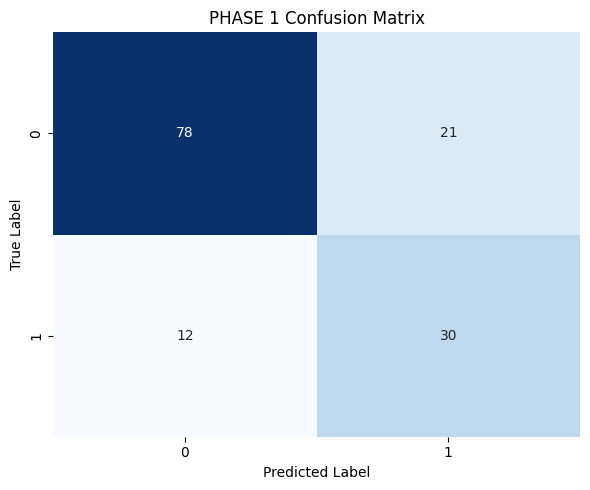


------------------------------------------------------------
TRAINING FOR PHASE 2
------------------------------------------------------------
Original Shape: (141, 908)
Class Distribution: [99 42]

Shape After Variance Threshold: (141, 897)
Shape After SelectKBest: (141, 250)

----- Fold 1 -----
Fold ROC-AUC: 0.7222

----- Fold 2 -----
Fold ROC-AUC: 0.75

----- Fold 3 -----
Fold ROC-AUC: 0.8063

----- Fold 4 -----
Fold ROC-AUC: 0.9

----- Fold 5 -----
Fold ROC-AUC: 0.7485

------------------------------------------------------------
FINAL RESULTS FOR PHASE 2
------------------------------------------------------------

Fold ROC-AUC Scores:
[0.7222 0.75   0.8062 0.9    0.7485]

Mean Fold ROC-AUC:
0.7854

Overall ROC-AUC:
0.7843

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.87      0.85        99
           1       0.65      0.57      0.61        42

    accuracy                           0.78       141
   macro avg       

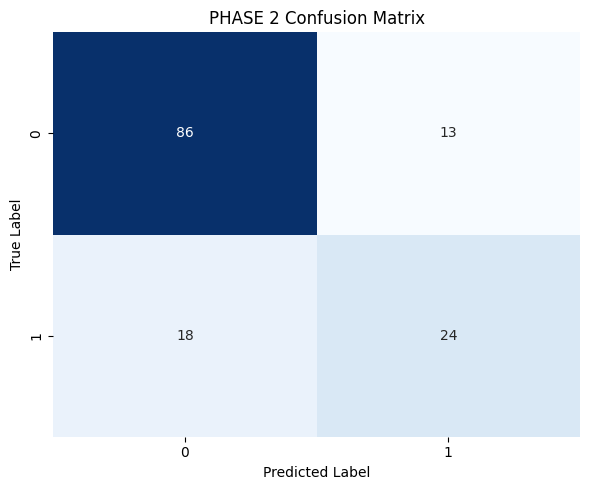


------------------------------------------------------------
TRAINING FOR PHASE 3
------------------------------------------------------------
Original Shape: (141, 908)
Class Distribution: [99 42]

Shape After Variance Threshold: (141, 898)
Shape After SelectKBest: (141, 250)

----- Fold 1 -----
Fold ROC-AUC: 0.7556

----- Fold 2 -----
Fold ROC-AUC: 0.825

----- Fold 3 -----
Fold ROC-AUC: 0.7938

----- Fold 4 -----
Fold ROC-AUC: 0.675

----- Fold 5 -----
Fold ROC-AUC: 0.6667

------------------------------------------------------------
FINAL RESULTS FOR PHASE 3
------------------------------------------------------------

Fold ROC-AUC Scores:
[0.7556 0.825  0.7938 0.675  0.6667]

Mean Fold ROC-AUC:
0.7432

Overall ROC-AUC:
0.7443

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.86      0.82        99
           1       0.58      0.45      0.51        42

    accuracy                           0.74       141
   macro avg    

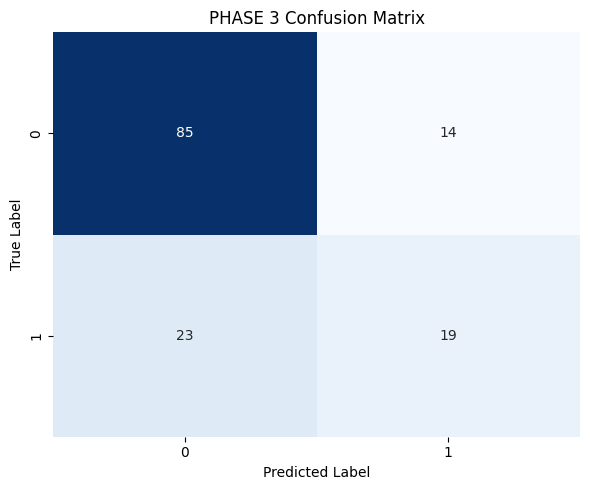


------------------------------------------------------------
FINAL ROC-AUC SCORES
------------------------------------------------------------
Phase 1 ROC-AUC: 0.8276
Phase 1 Precision: 0.5882
Phase 1 Recall: 0.7143
Phase 1 F1 Score: 0.6452

Phase 2 ROC-AUC: 0.7843
Phase 2 Precision: 0.6486
Phase 2 Recall: 0.5714
Phase 2 F1 Score: 0.6076

Phase 3 ROC-AUC: 0.7443
Phase 3 Precision: 0.5758
Phase 3 Recall: 0.4524
Phase 3 F1 Score: 0.5067


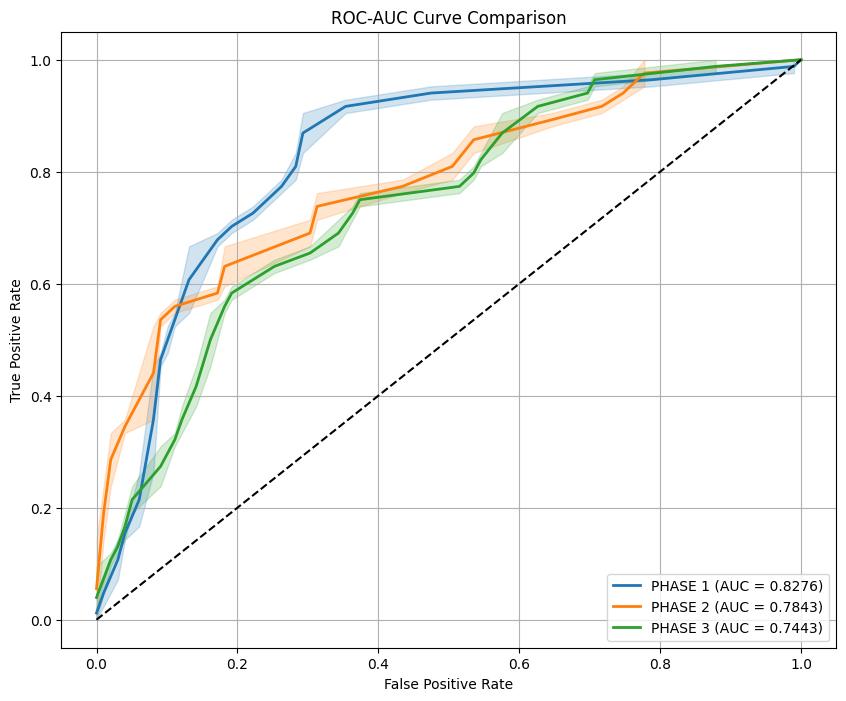

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold

from sklearn.feature_selection import (
    VarianceThreshold,
    SelectKBest,
    mutual_info_classif
)

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_curve
)

# load dataset
df = pd.read_csv("../../data/multimodal_audio_text_features.csv")

print("-" * 60)
print("DATASET INFORMATION")
print("-" * 60)

print("Dataset Shape:", df.shape)

# normalize phase column
df["phase"] = df["phase"].astype(str).str.lower().str.strip()

print("\nAvailable Phases:")
print(df["phase"].unique())

# remove non-feature columns
remove_cols = [
    "participant_id",
    "phase",
    "label"
]

feature_cols = [
    col for col in df.columns
    if col not in remove_cols
]

print("\nTotal Features:", len(feature_cols))

# store roc data
roc_data = {}

# training function
def train_phase_model(df_phase, phase_name):

    print("\n" + "-" * 60)
    print(f"TRAINING FOR {phase_name}")
    print("-" * 60)

    # drop missing values
    df_phase = df_phase.dropna()

    # features & labels
    X = df_phase[feature_cols]
    y = df_phase["label"].values

    print("Original Shape:", X.shape)
    print("Class Distribution:", np.bincount(y))

    # remove low variance features
    variance_selector = VarianceThreshold(
        threshold=0.00001
    )

    X = variance_selector.fit_transform(X)

    print("\nShape After Variance Threshold:", X.shape)

    # select important features
    kbest_selector = SelectKBest(
        score_func=mutual_info_classif,
        k=min(250, X.shape[1])
    )

    X = kbest_selector.fit_transform(X, y)

    print("Shape After SelectKBest:", X.shape)

    # 5-fold stratified cv
    skf = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    # store predictions
    all_probs = np.zeros(len(y))
    all_preds = np.zeros(len(y))

    fold_aucs = []

    # train each fold
    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):

        print(f"\n----- Fold {fold} -----")

        X_train, X_test = X[train_idx], X[test_idx]

        y_train, y_test = y[train_idx], y[test_idx]

        # random forest model
        model = RandomForestClassifier(

            # more trees
            n_estimators=700,

            # better generalization
            max_depth=12,

            # prevent overfitting
            min_samples_split=4,
            min_samples_leaf=2,

            # better feature sampling
            max_features="sqrt",

            # handle imbalance
            class_weight="balanced",

            # enable bootstrap
            bootstrap=True,

            random_state=42,
            n_jobs=-1
        )

        # train model
        model.fit(X_train, y_train)

        # predict
        y_prob = model.predict_proba(X_test)[:, 1]

        THRESHOLD = 0.35

        y_pred = (y_prob > THRESHOLD).astype(int)

        # store predictions
        all_probs[test_idx] = y_prob
        all_preds[test_idx] = y_pred

        # fold roc-auc
        fold_auc = roc_auc_score(y_test, y_prob)

        fold_aucs.append(fold_auc)

        print("Fold ROC-AUC:", round(fold_auc, 4))

    # final results
    overall_auc = roc_auc_score(y, all_probs)

    print("\n" + "-" * 60)
    print(f"FINAL RESULTS FOR {phase_name}")
    print("-" * 60)

    print("\nFold ROC-AUC Scores:")
    print(np.round(fold_aucs, 4))

    print("\nMean Fold ROC-AUC:")
    print(round(np.mean(fold_aucs), 4))

    print("\nOverall ROC-AUC:")
    print(round(overall_auc, 4))

    # classification report
    print("\nClassification Report:")
    print(classification_report(
        y,
        all_preds,
        zero_division=0
    ))

    # precision score
    precision = precision_score(
        y,
        all_preds,
        zero_division=0
    )

    print("Precision Score:", round(precision, 4))

    # recall score
    recall = recall_score(
        y,
        all_preds,
        zero_division=0
    )

    print("Recall Score:", round(recall, 4))

    # f1 score
    f1 = f1_score(
        y,
        all_preds,
        zero_division=0
    )

    print("F1 Score:", round(f1, 4))

    # confusion matrix
    cm = confusion_matrix(y, all_preds)

    print("\nConfusion Matrix:")
    print(cm)

    # draw confusion matrix
    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False
    )

    plt.title(f"{phase_name} Confusion Matrix")

    plt.xlabel("Predicted Label")

    plt.ylabel("True Label")

    plt.tight_layout()

    plt.show()

    # roc curve values
    fpr, tpr, _ = roc_curve(y, all_probs)

    roc_data[phase_name] = {
        "fpr": fpr,
        "tpr": tpr,
        "auc": overall_auc
    }

    return overall_auc, precision, recall, f1

# filter data phase-wise
df_p1 = df[df["phase"] == "phase1"]

df_p2 = df[df["phase"] == "phase2"]

df_p3 = df[df["phase"] == "phase3"]

# train models
roc_p1, prec_p1, rec_p1, f1_p1 = train_phase_model(
    df_p1,
    "PHASE 1"
)

roc_p2, prec_p2, rec_p2, f1_p2 = train_phase_model(
    df_p2,
    "PHASE 2"
)

roc_p3, prec_p3, rec_p3, f1_p3 = train_phase_model(
    df_p3,
    "PHASE 3"
)

# final summary
print("\n" + "-" * 60)
print("FINAL ROC-AUC SCORES")
print("-" * 60)

print(f"Phase 1 ROC-AUC: {roc_p1:.4f}")
print(f"Phase 1 Precision: {prec_p1:.4f}")
print(f"Phase 1 Recall: {rec_p1:.4f}")
print(f"Phase 1 F1 Score: {f1_p1:.4f}")

print()

print(f"Phase 2 ROC-AUC: {roc_p2:.4f}")
print(f"Phase 2 Precision: {prec_p2:.4f}")
print(f"Phase 2 Recall: {rec_p2:.4f}")
print(f"Phase 2 F1 Score: {f1_p2:.4f}")

print()

print(f"Phase 3 ROC-AUC: {roc_p3:.4f}")
print(f"Phase 3 Precision: {prec_p3:.4f}")
print(f"Phase 3 Recall: {rec_p3:.4f}")
print(f"Phase 3 F1 Score: {f1_p3:.4f}")

# final roc auc curve
plt.figure(figsize=(10, 8))

for phase_name, values in roc_data.items():

    sns.lineplot(
        x=values["fpr"],
        y=values["tpr"],
        linewidth=2,
        label=f"{phase_name} (AUC = {values['auc']:.4f})"
    )

sns.lineplot(
    x=[0, 1],
    y=[0, 1],
    linestyle="--",
    color="black"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC-AUC Curve Comparison")

plt.legend(loc="lower right")

plt.grid(True)

plt.show()

Random Forest 10 folds

------------------------------------------------------------
DATASET INFORMATION
------------------------------------------------------------
Dataset Shape: (423, 911)

Available Phases:
<StringArray>
['phase1', 'phase2', 'phase3']
Length: 3, dtype: str

Total Features: 908

------------------------------------------------------------
TRAINING FOR PHASE 1
------------------------------------------------------------
Original Shape: (141, 908)
Class Distribution: [99 42]

Shape After Variance Threshold: (141, 898)
Shape After SelectKBest: (141, 250)

----- Fold 1 -----
Fold ROC-AUC: 0.38

----- Fold 2 -----
Fold ROC-AUC: 0.775

----- Fold 3 -----
Fold ROC-AUC: 0.85

----- Fold 4 -----
Fold ROC-AUC: 1.0

----- Fold 5 -----
Fold ROC-AUC: 0.925

----- Fold 6 -----
Fold ROC-AUC: 0.95

----- Fold 7 -----
Fold ROC-AUC: 0.975

----- Fold 8 -----
Fold ROC-AUC: 0.8

----- Fold 9 -----
Fold ROC-AUC: 0.95

----- Fold 10 -----
Fold ROC-AUC: 0.8444

---------------------------------------------------

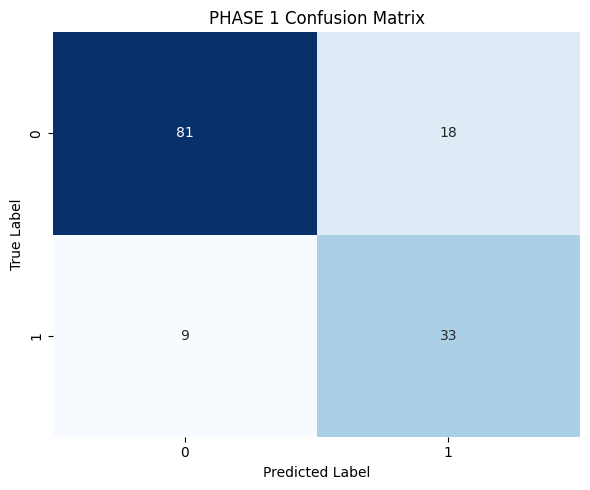


------------------------------------------------------------
TRAINING FOR PHASE 2
------------------------------------------------------------
Original Shape: (141, 908)
Class Distribution: [99 42]

Shape After Variance Threshold: (141, 897)
Shape After SelectKBest: (141, 250)

----- Fold 1 -----
Fold ROC-AUC: 0.78

----- Fold 2 -----
Fold ROC-AUC: 0.775

----- Fold 3 -----
Fold ROC-AUC: 0.75

----- Fold 4 -----
Fold ROC-AUC: 0.65

----- Fold 5 -----
Fold ROC-AUC: 1.0

----- Fold 6 -----
Fold ROC-AUC: 0.775

----- Fold 7 -----
Fold ROC-AUC: 0.775

----- Fold 8 -----
Fold ROC-AUC: 0.9

----- Fold 9 -----
Fold ROC-AUC: 0.725

----- Fold 10 -----
Fold ROC-AUC: 0.8222

------------------------------------------------------------
FINAL RESULTS FOR PHASE 2
------------------------------------------------------------

Fold ROC-AUC Scores:
[0.78   0.775  0.75   0.65   1.     0.775  0.775  0.9    0.725  0.8222]

Mean Fold ROC-AUC:
0.7952

Overall ROC-AUC:
0.7929

Classification Report:
       

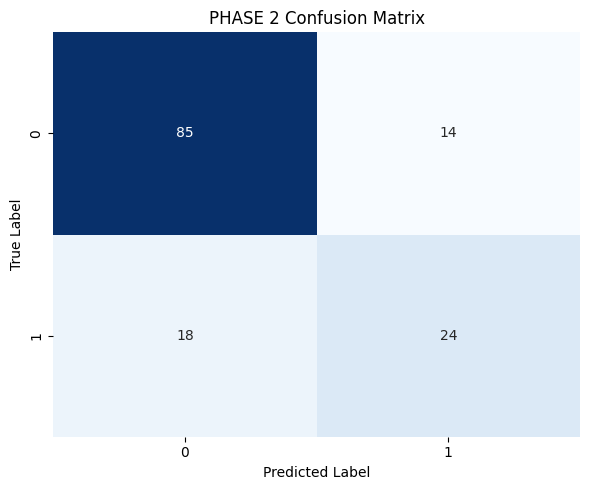


------------------------------------------------------------
TRAINING FOR PHASE 3
------------------------------------------------------------
Original Shape: (141, 908)
Class Distribution: [99 42]

Shape After Variance Threshold: (141, 898)
Shape After SelectKBest: (141, 250)

----- Fold 1 -----
Fold ROC-AUC: 0.62

----- Fold 2 -----
Fold ROC-AUC: 0.95

----- Fold 3 -----
Fold ROC-AUC: 0.725

----- Fold 4 -----
Fold ROC-AUC: 0.775

----- Fold 5 -----
Fold ROC-AUC: 0.825

----- Fold 6 -----
Fold ROC-AUC: 0.65

----- Fold 7 -----
Fold ROC-AUC: 0.95

----- Fold 8 -----
Fold ROC-AUC: 0.8

----- Fold 9 -----
Fold ROC-AUC: 0.95

----- Fold 10 -----
Fold ROC-AUC: 0.8222

------------------------------------------------------------
FINAL RESULTS FOR PHASE 3
------------------------------------------------------------

Fold ROC-AUC Scores:
[0.62   0.95   0.725  0.775  0.825  0.65   0.95   0.8    0.95   0.8222]

Mean Fold ROC-AUC:
0.8067

Overall ROC-AUC:
0.7785

Classification Report:
       

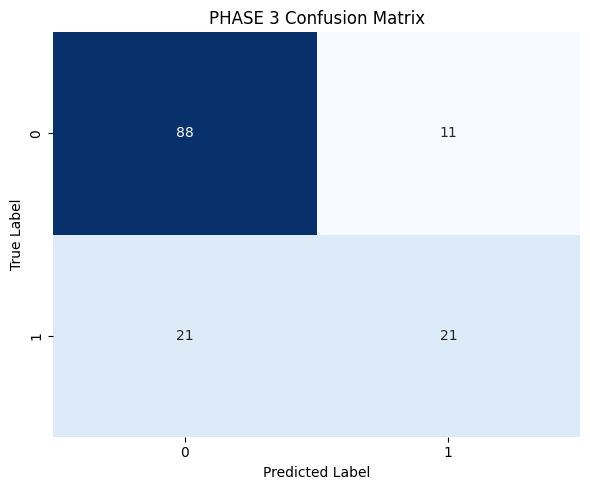


------------------------------------------------------------
FINAL ROC-AUC SCORES
------------------------------------------------------------
Phase 1 ROC-AUC: 0.8360
Phase 1 Precision: 0.6471
Phase 1 Recall: 0.7857
Phase 1 F1 Score: 0.7097

Phase 2 ROC-AUC: 0.7929
Phase 2 Precision: 0.6316
Phase 2 Recall: 0.5714
Phase 2 F1 Score: 0.6000

Phase 3 ROC-AUC: 0.7785
Phase 3 Precision: 0.6562
Phase 3 Recall: 0.5000
Phase 3 F1 Score: 0.5676


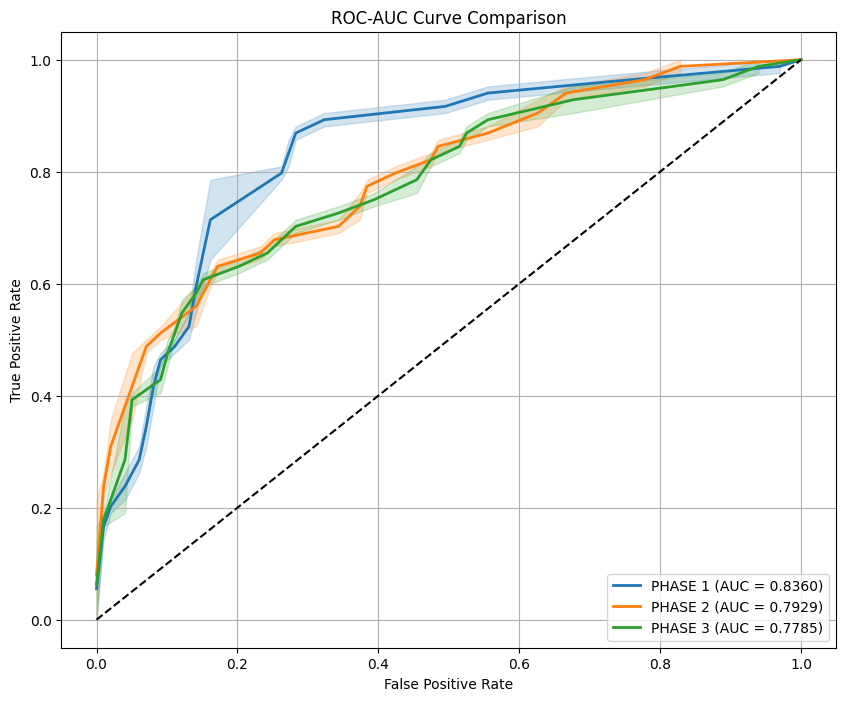

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold

from sklearn.feature_selection import (
    VarianceThreshold,
    SelectKBest,
    mutual_info_classif
)

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_curve
)

# load dataset
df = pd.read_csv("../../data/multimodal_audio_text_features.csv")

print("-" * 60)
print("DATASET INFORMATION")
print("-" * 60)

print("Dataset Shape:", df.shape)

# normalize phase column
df["phase"] = df["phase"].astype(str).str.lower().str.strip()

print("\nAvailable Phases:")
print(df["phase"].unique())

# remove non-feature columns
remove_cols = [
    "participant_id",
    "phase",
    "label"
]

feature_cols = [
    col for col in df.columns
    if col not in remove_cols
]

print("\nTotal Features:", len(feature_cols))

# store roc data
roc_data = {}

# training function
def train_phase_model(df_phase, phase_name):

    print("\n" + "-" * 60)
    print(f"TRAINING FOR {phase_name}")
    print("-" * 60)

    # drop missing values
    df_phase = df_phase.dropna()

    # features & labels
    X = df_phase[feature_cols]
    y = df_phase["label"].values

    print("Original Shape:", X.shape)
    print("Class Distribution:", np.bincount(y))

    # remove low variance features
    variance_selector = VarianceThreshold(
        threshold=0.00001
    )

    X = variance_selector.fit_transform(X)

    print("\nShape After Variance Threshold:", X.shape)

    # select important features
    kbest_selector = SelectKBest(
        score_func=mutual_info_classif,
        k=min(250, X.shape[1])
    )

    X = kbest_selector.fit_transform(X, y)

    print("Shape After SelectKBest:", X.shape)

    # 10-fold stratified cv
    skf = StratifiedKFold(
        n_splits=10,
        shuffle=True,
        random_state=42
    )

    # store predictions
    all_probs = np.zeros(len(y))
    all_preds = np.zeros(len(y))

    fold_aucs = []

    # train each fold
    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):

        print(f"\n----- Fold {fold} -----")

        X_train, X_test = X[train_idx], X[test_idx]

        y_train, y_test = y[train_idx], y[test_idx]

        # random forest model
        model = RandomForestClassifier(

            # more trees
            n_estimators=700,

            # better generalization
            max_depth=12,

            # prevent overfitting
            min_samples_split=4,
            min_samples_leaf=2,

            # better feature sampling
            max_features="sqrt",

            # handle imbalance
            class_weight="balanced",

            # enable bootstrap
            bootstrap=True,

            random_state=42,
            n_jobs=-1
        )

        # train model
        model.fit(X_train, y_train)

        # predict
        y_prob = model.predict_proba(X_test)[:, 1]

        THRESHOLD = 0.35

        y_pred = (y_prob > THRESHOLD).astype(int)

        # store predictions
        all_probs[test_idx] = y_prob
        all_preds[test_idx] = y_pred

        # fold roc-auc
        fold_auc = roc_auc_score(y_test, y_prob)

        fold_aucs.append(fold_auc)

        print("Fold ROC-AUC:", round(fold_auc, 4))

    # final results
    overall_auc = roc_auc_score(y, all_probs)

    print("\n" + "-" * 60)
    print(f"FINAL RESULTS FOR {phase_name}")
    print("-" * 60)

    print("\nFold ROC-AUC Scores:")
    print(np.round(fold_aucs, 4))

    print("\nMean Fold ROC-AUC:")
    print(round(np.mean(fold_aucs), 4))

    print("\nOverall ROC-AUC:")
    print(round(overall_auc, 4))

    # classification report
    print("\nClassification Report:")
    print(classification_report(
        y,
        all_preds,
        zero_division=0
    ))

    # precision score
    precision = precision_score(
        y,
        all_preds,
        zero_division=0
    )

    print("Precision Score:", round(precision, 4))

    # recall score
    recall = recall_score(
        y,
        all_preds,
        zero_division=0
    )

    print("Recall Score:", round(recall, 4))

    # f1 score
    f1 = f1_score(
        y,
        all_preds,
        zero_division=0
    )

    print("F1 Score:", round(f1, 4))

    # confusion matrix
    cm = confusion_matrix(y, all_preds)

    print("\nConfusion Matrix:")
    print(cm)

    # draw confusion matrix
    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False
    )

    plt.title(f"{phase_name} Confusion Matrix")

    plt.xlabel("Predicted Label")

    plt.ylabel("True Label")

    plt.tight_layout()

    plt.show()

    # roc curve values
    fpr, tpr, _ = roc_curve(y, all_probs)

    roc_data[phase_name] = {
        "fpr": fpr,
        "tpr": tpr,
        "auc": overall_auc
    }

    return overall_auc, precision, recall, f1

# filter data phase-wise
df_p1 = df[df["phase"] == "phase1"]

df_p2 = df[df["phase"] == "phase2"]

df_p3 = df[df["phase"] == "phase3"]

# train models
roc_p1, prec_p1, rec_p1, f1_p1 = train_phase_model(
    df_p1,
    "PHASE 1"
)

roc_p2, prec_p2, rec_p2, f1_p2 = train_phase_model(
    df_p2,
    "PHASE 2"
)

roc_p3, prec_p3, rec_p3, f1_p3 = train_phase_model(
    df_p3,
    "PHASE 3"
)

# final summary
print("\n" + "-" * 60)
print("FINAL ROC-AUC SCORES")
print("-" * 60)

print(f"Phase 1 ROC-AUC: {roc_p1:.4f}")
print(f"Phase 1 Precision: {prec_p1:.4f}")
print(f"Phase 1 Recall: {rec_p1:.4f}")
print(f"Phase 1 F1 Score: {f1_p1:.4f}")

print()

print(f"Phase 2 ROC-AUC: {roc_p2:.4f}")
print(f"Phase 2 Precision: {prec_p2:.4f}")
print(f"Phase 2 Recall: {rec_p2:.4f}")
print(f"Phase 2 F1 Score: {f1_p2:.4f}")

print()

print(f"Phase 3 ROC-AUC: {roc_p3:.4f}")
print(f"Phase 3 Precision: {prec_p3:.4f}")
print(f"Phase 3 Recall: {rec_p3:.4f}")
print(f"Phase 3 F1 Score: {f1_p3:.4f}")

# final roc auc curve
plt.figure(figsize=(10, 8))

for phase_name, values in roc_data.items():

    sns.lineplot(
        x=values["fpr"],
        y=values["tpr"],
        linewidth=2,
        label=f"{phase_name} (AUC = {values['auc']:.4f})"
    )

sns.lineplot(
    x=[0, 1],
    y=[0, 1],
    linestyle="--",
    color="black"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC-AUC Curve Comparison")

plt.legend(loc="lower right")

plt.grid(True)

plt.show()

XGBoost

------------------------------------------------------------
DATASET INFORMATION
------------------------------------------------------------
Dataset Shape: (423, 911)

Available Phases:
<StringArray>
['phase1', 'phase2', 'phase3']
Length: 3, dtype: str

Total Features: 908

------------------------------------------------------------
TRAINING FOR PHASE 1
------------------------------------------------------------
Original Shape: (141, 908)
Class Distribution: [99 42]

Shape After Variance Threshold: (141, 898)
Shape After SelectKBest: (141, 400)
Scale Pos Weight: 2.3939

Predicted Distribution:
[16 13]

Actual Distribution:
[20  9]

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.65      0.72        20
           1       0.46      0.67      0.55         9

    accuracy                           0.66        29
   macro avg       0.64      0.66      0.63        29
weighted avg       0.70      0.66      0.67        29

Precisi

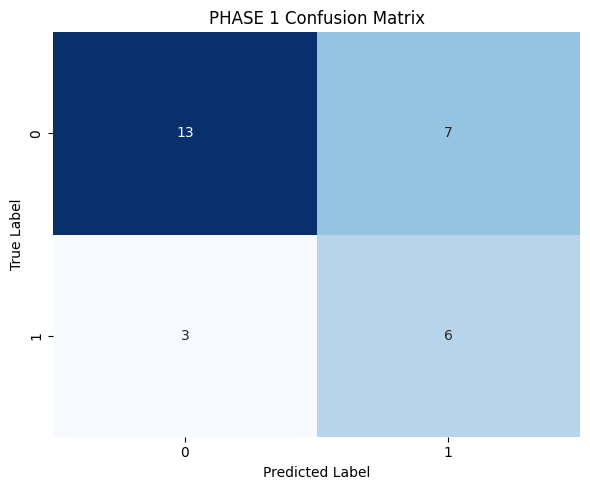


------------------------------------------------------------
TRAINING FOR PHASE 2
------------------------------------------------------------
Original Shape: (141, 908)
Class Distribution: [99 42]

Shape After Variance Threshold: (141, 897)
Shape After SelectKBest: (141, 400)
Scale Pos Weight: 2.3939

Predicted Distribution:
[19 10]

Actual Distribution:
[20  9]

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.75      0.77        20
           1       0.50      0.56      0.53         9

    accuracy                           0.69        29
   macro avg       0.64      0.65      0.65        29
weighted avg       0.70      0.69      0.69        29

Precision Score: 0.5
Recall Score: 0.5556
F1 Score: 0.5263
ROC-AUC Score: 0.6333

Confusion Matrix:
[[15  5]
 [ 4  5]]


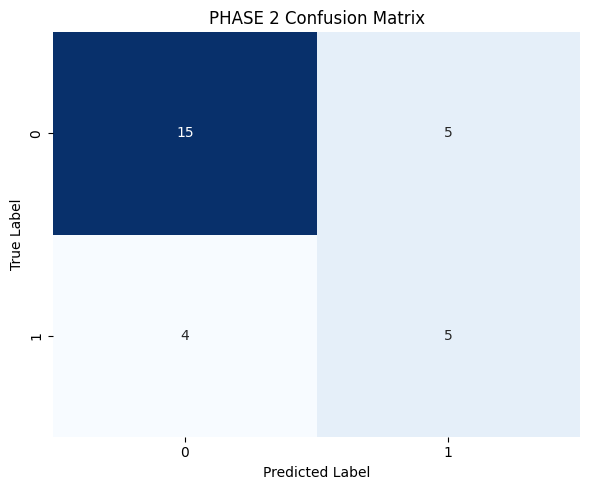


------------------------------------------------------------
TRAINING FOR PHASE 3
------------------------------------------------------------
Original Shape: (141, 908)
Class Distribution: [99 42]

Shape After Variance Threshold: (141, 898)
Shape After SelectKBest: (141, 400)
Scale Pos Weight: 2.3939

Predicted Distribution:
[20  9]

Actual Distribution:
[20  9]

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.70      0.70        20
           1       0.33      0.33      0.33         9

    accuracy                           0.59        29
   macro avg       0.52      0.52      0.52        29
weighted avg       0.59      0.59      0.59        29

Precision Score: 0.3333
Recall Score: 0.3333
F1 Score: 0.3333
ROC-AUC Score: 0.5278

Confusion Matrix:
[[14  6]
 [ 6  3]]


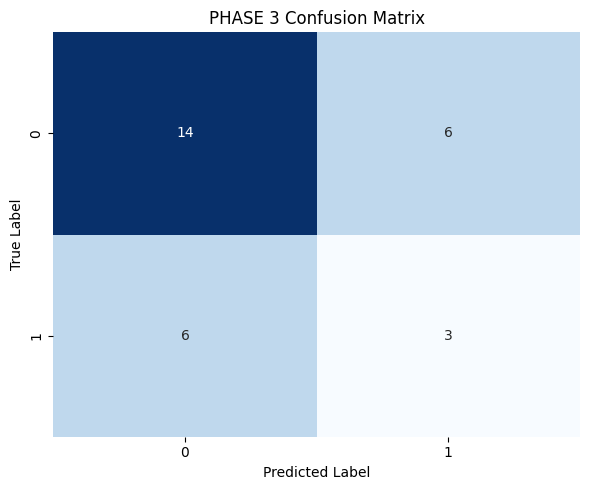


------------------------------------------------------------
FINAL ROC-AUC SCORES
------------------------------------------------------------
Phase 1 ROC-AUC: 0.6556
Phase 1 Precision: 0.4615
Phase 1 Recall: 0.6667
Phase 1 F1 Score: 0.5455

Phase 2 ROC-AUC: 0.6333
Phase 2 Precision: 0.5000
Phase 2 Recall: 0.5556
Phase 2 F1 Score: 0.5263

Phase 3 ROC-AUC: 0.5278
Phase 3 Precision: 0.3333
Phase 3 Recall: 0.3333
Phase 3 F1 Score: 0.3333


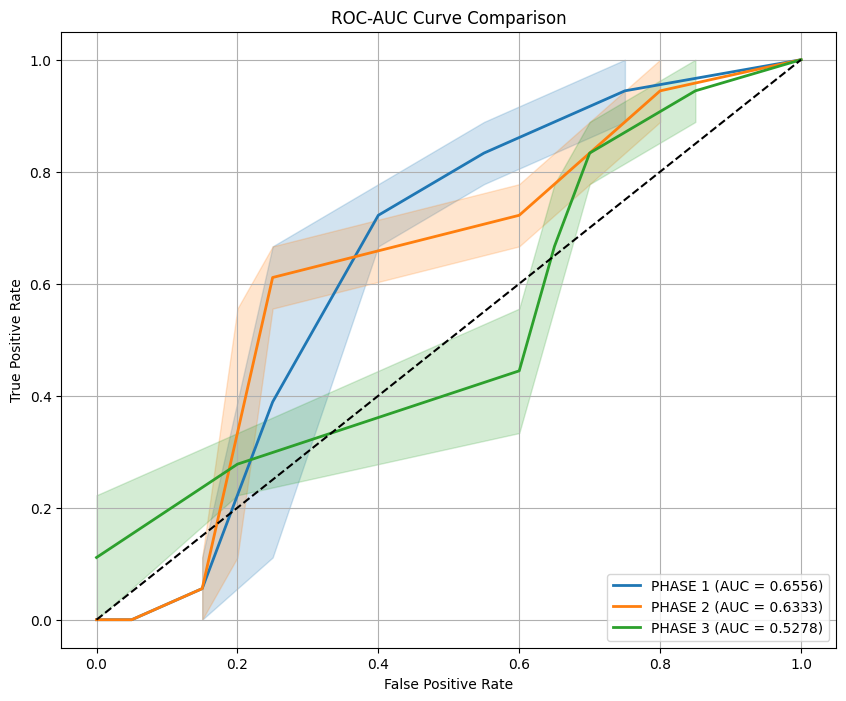

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.feature_selection import (
    VarianceThreshold,
    SelectKBest,
    mutual_info_classif
)

from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_curve
)

from xgboost import XGBClassifier

# load dataset
df = pd.read_csv("../../data/multimodal_audio_text_features.csv")

print("-" * 60)
print("DATASET INFORMATION")
print("-" * 60)

print("Dataset Shape:", df.shape)

# normalize phase column
df["phase"] = df["phase"].astype(str).str.lower().str.strip()

print("\nAvailable Phases:")
print(df["phase"].unique())

# remove non-feature columns
remove_cols = [
    "participant_id",
    "phase",
    "label"
]

feature_cols = [
    col for col in df.columns
    if col not in remove_cols
]

print("\nTotal Features:", len(feature_cols))

roc_data = {}

# training function
def train_phase_model(df_phase, phase_name):

    print("\n" + "-" * 60)
    print(f"TRAINING FOR {phase_name}")
    print("-" * 60)

    # drop missing values
    df_phase = df_phase.dropna()

    # features and labels
    X = df_phase[feature_cols]
    y = df_phase["label"].values

    print("Original Shape:", X.shape)
    print("Class Distribution:", np.bincount(y))

    # remove low variance features
    variance_selector = VarianceThreshold(
        threshold=0.00001
    )

    X = variance_selector.fit_transform(X)

    print("\nShape After Variance Threshold:", X.shape)

    kbest_selector = SelectKBest(
        score_func=mutual_info_classif,
        k=min(400, X.shape[1])
    )

    X = kbest_selector.fit_transform(X, y)

    print("Shape After SelectKBest:", X.shape)

    # train test split
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        stratify=y,
        random_state=42
    )

    # handle imbalance with scale_pos_weight
    neg = np.sum(y_train == 0)
    pos = np.sum(y_train == 1)

    scale_pos_weight = neg / pos

    print("Scale Pos Weight:", round(scale_pos_weight, 4))

    # tuned XGBoost model
    model = XGBClassifier(

        objective="binary:logistic",
        eval_metric="auc",

        n_estimators=900,

        max_depth=7,

        learning_rate=0.015,

        reg_alpha=0.3,
        reg_lambda=2,

        subsample=0.9,
        colsample_bytree=0.9,

        min_child_weight=1,
        gamma=0.2,

        scale_pos_weight=scale_pos_weight,

        tree_method="hist",

        random_state=42,
        n_jobs=-1
    )

    # train model
    model.fit(X_train, y_train)

    y_prob = model.predict_proba(X_test)[:, 1]

    THRESHOLD = 0.30

    y_pred = (y_prob > THRESHOLD).astype(int)

    print("\nPredicted Distribution:")
    print(np.bincount(y_pred))

    print("\nActual Distribution:")
    print(np.bincount(y_test))

    # classification report
    print("\nClassification Report:")
    print(classification_report(
        y_test,
        y_pred,
        zero_division=0
    ))

    # precision score
    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    print("Precision Score:", round(precision, 4))

    #recall score
    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    print("Recall Score:", round(recall, 4))

    # F1 score
    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    print("F1 Score:", round(f1, 4))

    # ROC-AUC
    roc = roc_auc_score(y_test, y_prob)

    print("ROC-AUC Score:", round(roc, 4))

    # confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    print("\nConfusion Matrix:")
    print(cm)

    # draw confusion matrix
    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False
    )

    plt.title(f"{phase_name} Confusion Matrix")

    plt.xlabel("Predicted Label")

    plt.ylabel("True Label")

    plt.tight_layout()

    plt.show()

    # ROC curve values
    fpr, tpr, _ = roc_curve(y_test, y_prob)

    roc_data[phase_name] = {
        "fpr": fpr,
        "tpr": tpr,
        "auc": roc
    }

    return model, roc, precision, recall, f1

# filter data phase-wise
df_p1 = df[df["phase"] == "phase1"]

df_p2 = df[df["phase"] == "phase2"]

df_p3 = df[df["phase"] == "phase3"]

# train models
model_p1, roc_p1, prec_p1, rec_p1, f1_p1 = train_phase_model(
    df_p1,
    "PHASE 1"
)

model_p2, roc_p2, prec_p2, rec_p2, f1_p2 = train_phase_model(
    df_p2,
    "PHASE 2"
)

model_p3, roc_p3, prec_p3, rec_p3, f1_p3 = train_phase_model(
    df_p3,
    "PHASE 3"
)

# final summary
print("\n" + "-" * 60)
print("FINAL ROC-AUC SCORES")
print("-" * 60)

print(f"Phase 1 ROC-AUC: {roc_p1:.4f}")
print(f"Phase 1 Precision: {prec_p1:.4f}")
print(f"Phase 1 Recall: {rec_p1:.4f}")
print(f"Phase 1 F1 Score: {f1_p1:.4f}")

print()

print(f"Phase 2 ROC-AUC: {roc_p2:.4f}")
print(f"Phase 2 Precision: {prec_p2:.4f}")
print(f"Phase 2 Recall: {rec_p2:.4f}")
print(f"Phase 2 F1 Score: {f1_p2:.4f}")

print()

print(f"Phase 3 ROC-AUC: {roc_p3:.4f}")
print(f"Phase 3 Precision: {prec_p3:.4f}")
print(f"Phase 3 Recall: {rec_p3:.4f}")
print(f"Phase 3 F1 Score: {f1_p3:.4f}")

# final ROC AUC curve
plt.figure(figsize=(10, 8))

for phase_name, values in roc_data.items():

    sns.lineplot(
        x=values["fpr"],
        y=values["tpr"],
        linewidth=2,
        label=f"{phase_name} (AUC = {values['auc']:.4f})"
    )

sns.lineplot(
    x=[0, 1],
    y=[0, 1],
    linestyle="--",
    color="black"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC-AUC Curve Comparison")

plt.legend(loc="lower right")

plt.grid(True)

plt.show()

XGBoost 5 folds

------------------------------------------------------------
DATASET INFORMATION
------------------------------------------------------------
Dataset Shape: (423, 911)

Available Phases:
<StringArray>
['phase1', 'phase2', 'phase3']
Length: 3, dtype: str

Total Features: 908

------------------------------------------------------------
TRAINING FOR PHASE 1
------------------------------------------------------------
Original Shape: (141, 908)
Class Distribution: [99 42]

Shape After Variance Threshold: (141, 898)
Shape After SelectKBest: (141, 350)

----- Fold 1 -----
Fold ROC-AUC: 0.55

----- Fold 2 -----
Fold ROC-AUC: 0.8688

----- Fold 3 -----
Fold ROC-AUC: 0.9375

----- Fold 4 -----
Fold ROC-AUC: 0.9562

----- Fold 5 -----
Fold ROC-AUC: 0.883

------------------------------------------------------------
FINAL RESULTS FOR PHASE 1
------------------------------------------------------------

Fold ROC-AUC Scores:
[0.55   0.8688 0.9375 0.9562 0.883 ]

Mean Fold ROC-AUC:
0.8391

Overall 

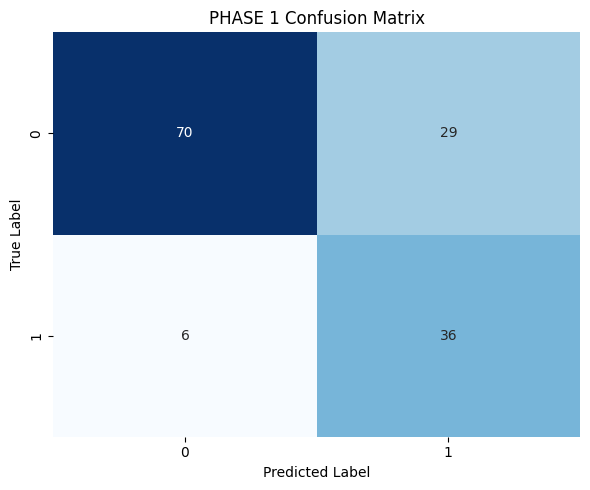


------------------------------------------------------------
TRAINING FOR PHASE 2
------------------------------------------------------------
Original Shape: (141, 908)
Class Distribution: [99 42]

Shape After Variance Threshold: (141, 897)
Shape After SelectKBest: (141, 350)

----- Fold 1 -----
Fold ROC-AUC: 0.6222

----- Fold 2 -----
Fold ROC-AUC: 0.7125

----- Fold 3 -----
Fold ROC-AUC: 0.8063

----- Fold 4 -----
Fold ROC-AUC: 0.8625

----- Fold 5 -----
Fold ROC-AUC: 0.7251

------------------------------------------------------------
FINAL RESULTS FOR PHASE 2
------------------------------------------------------------

Fold ROC-AUC Scores:
[0.6222 0.7125 0.8063 0.8625 0.7251]

Mean Fold ROC-AUC:
0.7457

Overall ROC-AUC:
0.7496

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.72      0.77        99
           1       0.49      0.64      0.56        42

    accuracy                           0.70       141
   macro avg  

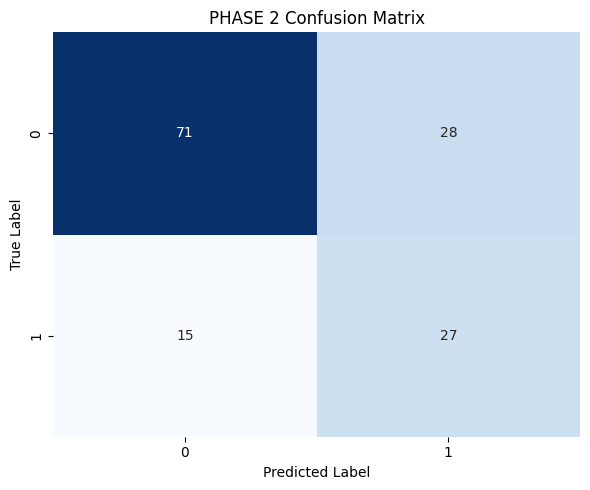


------------------------------------------------------------
TRAINING FOR PHASE 3
------------------------------------------------------------
Original Shape: (141, 908)
Class Distribution: [99 42]

Shape After Variance Threshold: (141, 898)
Shape After SelectKBest: (141, 350)

----- Fold 1 -----
Fold ROC-AUC: 0.7

----- Fold 2 -----
Fold ROC-AUC: 0.75

----- Fold 3 -----
Fold ROC-AUC: 0.7125

----- Fold 4 -----
Fold ROC-AUC: 0.8375

----- Fold 5 -----
Fold ROC-AUC: 0.6023

------------------------------------------------------------
FINAL RESULTS FOR PHASE 3
------------------------------------------------------------

Fold ROC-AUC Scores:
[0.7    0.75   0.7125 0.8375 0.6023]

Mean Fold ROC-AUC:
0.7205

Overall ROC-AUC:
0.7037

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.59      0.68        99
           1       0.41      0.69      0.52        42

    accuracy                           0.62       141
   macro avg       

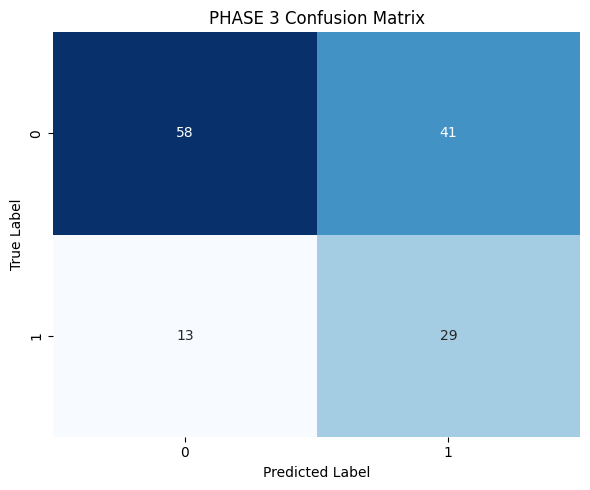


------------------------------------------------------------
FINAL ROC-AUC SCORES
------------------------------------------------------------
Phase 1 ROC-AUC: 0.8175
Phase 1 Precision: 0.5538
Phase 1 Recall: 0.8571
Phase 1 F1 Score: 0.6729

Phase 2 ROC-AUC: 0.7496
Phase 2 Precision: 0.4909
Phase 2 Recall: 0.6429
Phase 2 F1 Score: 0.5567

Phase 3 ROC-AUC: 0.7037
Phase 3 Precision: 0.4143
Phase 3 Recall: 0.6905
Phase 3 F1 Score: 0.5179


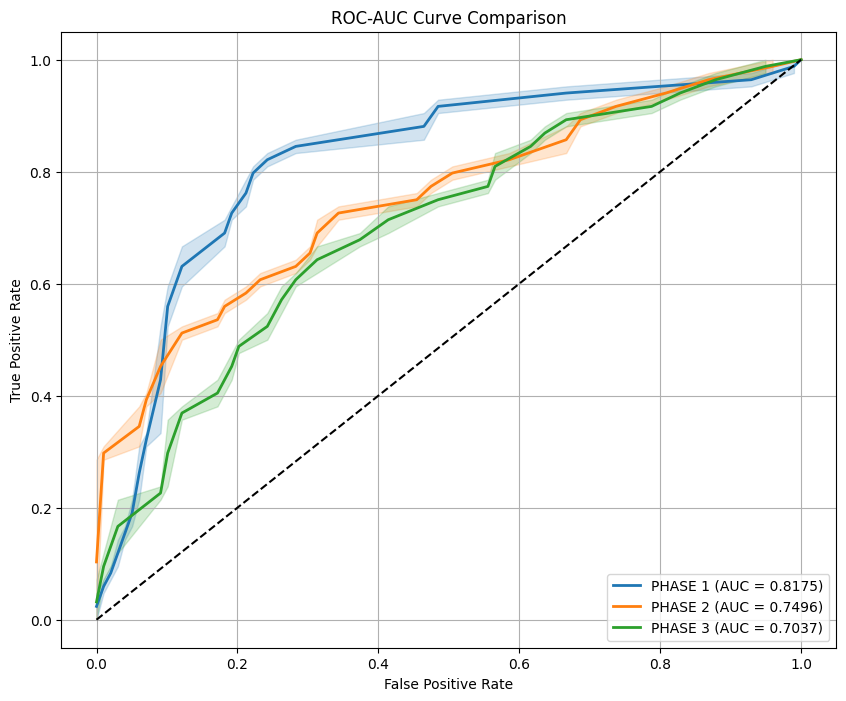

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold

from sklearn.feature_selection import (
    VarianceThreshold,
    SelectKBest,
    mutual_info_classif
)

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_curve
)

# load dataset
df = pd.read_csv("../../data/multimodal_audio_text_features.csv")

print("-" * 60)
print("DATASET INFORMATION")
print("-" * 60)

print("Dataset Shape:", df.shape)

# normalize phase column
df["phase"] = df["phase"].astype(str).str.lower().str.strip()

print("\nAvailable Phases:")
print(df["phase"].unique())

# remove non-feature columns
remove_cols = [
    "participant_id",
    "phase",
    "label"
]

feature_cols = [
    col for col in df.columns
    if col not in remove_cols
]

print("\nTotal Features:", len(feature_cols))

# store roc data
roc_data = {}

# training function
def train_phase_model(df_phase, phase_name):

    print("\n" + "-" * 60)
    print(f"TRAINING FOR {phase_name}")
    print("-" * 60)

    # drop missing values
    df_phase = df_phase.dropna()

    # features & labels
    X = df_phase[feature_cols]
    y = df_phase["label"].values

    print("Original Shape:", X.shape)
    print("Class Distribution:", np.bincount(y))

    # remove low variance features
    variance_selector = VarianceThreshold(
        threshold=0.00001
    )

    X = variance_selector.fit_transform(X)

    print("\nShape After Variance Threshold:", X.shape)

    # keep important multimodal features
    kbest_selector = SelectKBest(
        score_func=mutual_info_classif,
        k=min(350, X.shape[1])
    )

    X = kbest_selector.fit_transform(X, y)

    print("Shape After SelectKBest:", X.shape)

    # 5-fold stratified cv
    skf = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    # store predictions
    all_probs = np.zeros(len(y))
    all_preds = np.zeros(len(y))

    fold_aucs = []

    # train each fold
    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):

        print(f"\n----- Fold {fold} -----")

        X_train, X_test = X[train_idx], X[test_idx]

        y_train, y_test = y[train_idx], y[test_idx]

        # random forest model
        model = RandomForestClassifier(

            # more trees
            n_estimators=800,

            # better multimodal learning
            max_depth=14,

            # reduce overfitting
            min_samples_split=3,
            min_samples_leaf=1,

            # better feature selection
            max_features="sqrt",

            # handle imbalance
            class_weight="balanced",

            # bootstrap sampling
            bootstrap=True,

            random_state=42,
            n_jobs=-1
        )

        # train model
        model.fit(X_train, y_train)

        # predict
        y_prob = model.predict_proba(X_test)[:, 1]

        THRESHOLD = 0.30

        y_pred = (y_prob > THRESHOLD).astype(int)

        # store predictions
        all_probs[test_idx] = y_prob
        all_preds[test_idx] = y_pred

        # fold roc-auc
        fold_auc = roc_auc_score(y_test, y_prob)

        fold_aucs.append(fold_auc)

        print("Fold ROC-AUC:", round(fold_auc, 4))

    # final results
    overall_auc = roc_auc_score(y, all_probs)

    print("\n" + "-" * 60)
    print(f"FINAL RESULTS FOR {phase_name}")
    print("-" * 60)

    print("\nFold ROC-AUC Scores:")
    print(np.round(fold_aucs, 4))

    print("\nMean Fold ROC-AUC:")
    print(round(np.mean(fold_aucs), 4))

    print("\nOverall ROC-AUC:")
    print(round(overall_auc, 4))

    # classification report
    print("\nClassification Report:")
    print(classification_report(
        y,
        all_preds,
        zero_division=0
    ))

    # precision score
    precision = precision_score(
        y,
        all_preds,
        zero_division=0
    )

    print("Precision Score:", round(precision, 4))

    # recall score
    recall = recall_score(
        y,
        all_preds,
        zero_division=0
    )

    print("Recall Score:", round(recall, 4))

    # f1 score
    f1 = f1_score(
        y,
        all_preds,
        zero_division=0
    )

    print("F1 Score:", round(f1, 4))

    # confusion matrix
    cm = confusion_matrix(y, all_preds)

    print("\nConfusion Matrix:")
    print(cm)

    # draw confusion matrix
    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False
    )

    plt.title(f"{phase_name} Confusion Matrix")

    plt.xlabel("Predicted Label")

    plt.ylabel("True Label")

    plt.tight_layout()

    plt.show()

    # roc curve values
    fpr, tpr, _ = roc_curve(y, all_probs)

    roc_data[phase_name] = {
        "fpr": fpr,
        "tpr": tpr,
        "auc": overall_auc
    }

    return overall_auc, precision, recall, f1

# filter data phase-wise
df_p1 = df[df["phase"] == "phase1"]

df_p2 = df[df["phase"] == "phase2"]

df_p3 = df[df["phase"] == "phase3"]

# train models
roc_p1, prec_p1, rec_p1, f1_p1 = train_phase_model(
    df_p1,
    "PHASE 1"
)

roc_p2, prec_p2, rec_p2, f1_p2 = train_phase_model(
    df_p2,
    "PHASE 2"
)

roc_p3, prec_p3, rec_p3, f1_p3 = train_phase_model(
    df_p3,
    "PHASE 3"
)

# final summary
print("\n" + "-" * 60)
print("FINAL ROC-AUC SCORES")
print("-" * 60)

print(f"Phase 1 ROC-AUC: {roc_p1:.4f}")
print(f"Phase 1 Precision: {prec_p1:.4f}")
print(f"Phase 1 Recall: {rec_p1:.4f}")
print(f"Phase 1 F1 Score: {f1_p1:.4f}")

print()

print(f"Phase 2 ROC-AUC: {roc_p2:.4f}")
print(f"Phase 2 Precision: {prec_p2:.4f}")
print(f"Phase 2 Recall: {rec_p2:.4f}")
print(f"Phase 2 F1 Score: {f1_p2:.4f}")

print()

print(f"Phase 3 ROC-AUC: {roc_p3:.4f}")
print(f"Phase 3 Precision: {prec_p3:.4f}")
print(f"Phase 3 Recall: {rec_p3:.4f}")
print(f"Phase 3 F1 Score: {f1_p3:.4f}")

# final roc auc curve
plt.figure(figsize=(10, 8))

for phase_name, values in roc_data.items():

    sns.lineplot(
        x=values["fpr"],
        y=values["tpr"],
        linewidth=2,
        label=f"{phase_name} (AUC = {values['auc']:.4f})"
    )

sns.lineplot(
    x=[0, 1],
    y=[0, 1],
    linestyle="--",
    color="black"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC-AUC Curve Comparison")

plt.legend(loc="lower right")

plt.grid(True)

plt.show()

XGBoost 10 folds

------------------------------------------------------------
DATASET INFORMATION
------------------------------------------------------------
Dataset Shape: (423, 911)

Available Phases:
<StringArray>
['phase1', 'phase2', 'phase3']
Length: 3, dtype: str

Total Features: 908

------------------------------------------------------------
TRAINING FOR PHASE 1
------------------------------------------------------------
Original Shape: (141, 908)
Class Distribution: [99 42]

Shape After Variance Threshold: (141, 898)
Shape After SelectKBest: (141, 350)

----- Fold 1 -----
Fold ROC-AUC: 0.36

----- Fold 2 -----
Fold ROC-AUC: 0.725

----- Fold 3 -----
Fold ROC-AUC: 0.9

----- Fold 4 -----
Fold ROC-AUC: 0.975

----- Fold 5 -----
Fold ROC-AUC: 0.95

----- Fold 6 -----
Fold ROC-AUC: 0.875

----- Fold 7 -----
Fold ROC-AUC: 1.0

----- Fold 8 -----
Fold ROC-AUC: 0.925

----- Fold 9 -----
Fold ROC-AUC: 0.85

----- Fold 10 -----
Fold ROC-AUC: 0.8444

--------------------------------------------------

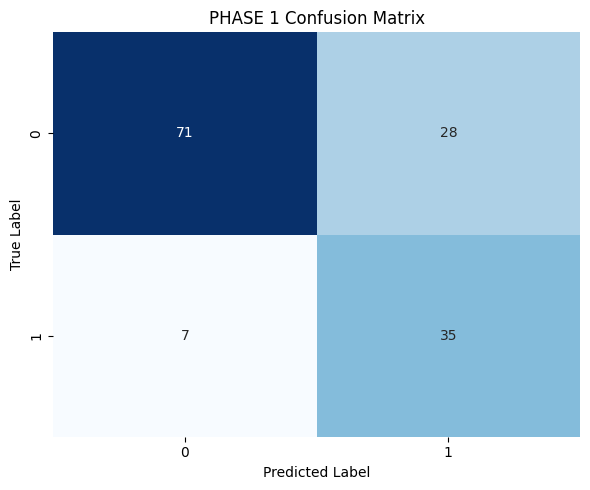


------------------------------------------------------------
TRAINING FOR PHASE 2
------------------------------------------------------------
Original Shape: (141, 908)
Class Distribution: [99 42]

Shape After Variance Threshold: (141, 897)
Shape After SelectKBest: (141, 350)

----- Fold 1 -----
Fold ROC-AUC: 0.56

----- Fold 2 -----
Fold ROC-AUC: 0.7

----- Fold 3 -----
Fold ROC-AUC: 0.65

----- Fold 4 -----
Fold ROC-AUC: 0.7

----- Fold 5 -----
Fold ROC-AUC: 0.9

----- Fold 6 -----
Fold ROC-AUC: 0.875

----- Fold 7 -----
Fold ROC-AUC: 0.775

----- Fold 8 -----
Fold ROC-AUC: 0.95

----- Fold 9 -----
Fold ROC-AUC: 0.8

----- Fold 10 -----
Fold ROC-AUC: 0.8

------------------------------------------------------------
FINAL RESULTS FOR PHASE 2
------------------------------------------------------------

Fold ROC-AUC Scores:
[0.56  0.7   0.65  0.7   0.9   0.875 0.775 0.95  0.8   0.8  ]

Mean Fold ROC-AUC:
0.771

Overall ROC-AUC:
0.7588

Classification Report:
              precision  

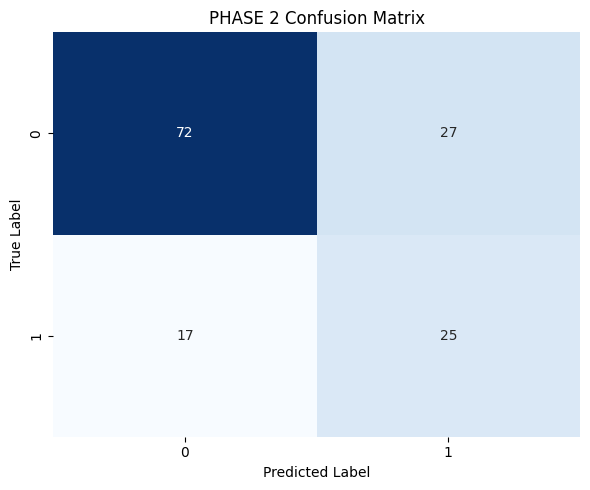


------------------------------------------------------------
TRAINING FOR PHASE 3
------------------------------------------------------------
Original Shape: (141, 908)
Class Distribution: [99 42]

Shape After Variance Threshold: (141, 898)
Shape After SelectKBest: (141, 350)

----- Fold 1 -----
Fold ROC-AUC: 0.56

----- Fold 2 -----
Fold ROC-AUC: 0.9

----- Fold 3 -----
Fold ROC-AUC: 0.675

----- Fold 4 -----
Fold ROC-AUC: 0.8

----- Fold 5 -----
Fold ROC-AUC: 0.75

----- Fold 6 -----
Fold ROC-AUC: 0.75

----- Fold 7 -----
Fold ROC-AUC: 0.95

----- Fold 8 -----
Fold ROC-AUC: 0.7

----- Fold 9 -----
Fold ROC-AUC: 0.6

----- Fold 10 -----
Fold ROC-AUC: 0.7111

------------------------------------------------------------
FINAL RESULTS FOR PHASE 3
------------------------------------------------------------

Fold ROC-AUC Scores:
[0.56   0.9    0.675  0.8    0.75   0.75   0.95   0.7    0.6    0.7111]

Mean Fold ROC-AUC:
0.7396

Overall ROC-AUC:
0.7169

Classification Report:
            

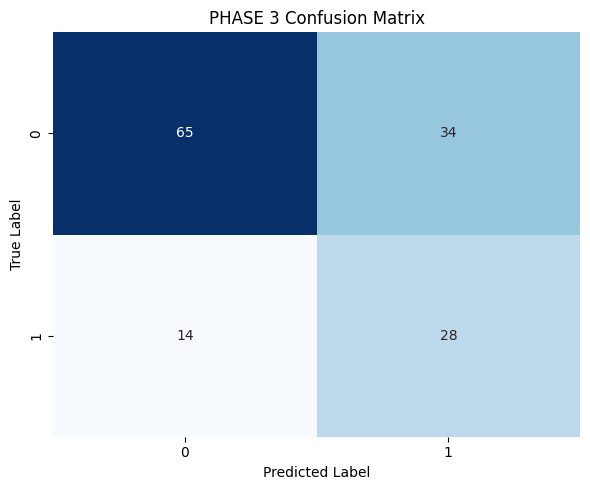


------------------------------------------------------------
FINAL ROC-AUC SCORES
------------------------------------------------------------
Phase 1 ROC-AUC: 0.8232
Phase 1 Precision: 0.5556
Phase 1 Recall: 0.8333
Phase 1 F1 Score: 0.6667

Phase 2 ROC-AUC: 0.7588
Phase 2 Precision: 0.4808
Phase 2 Recall: 0.5952
Phase 2 F1 Score: 0.5319

Phase 3 ROC-AUC: 0.7169
Phase 3 Precision: 0.4516
Phase 3 Recall: 0.6667
Phase 3 F1 Score: 0.5385


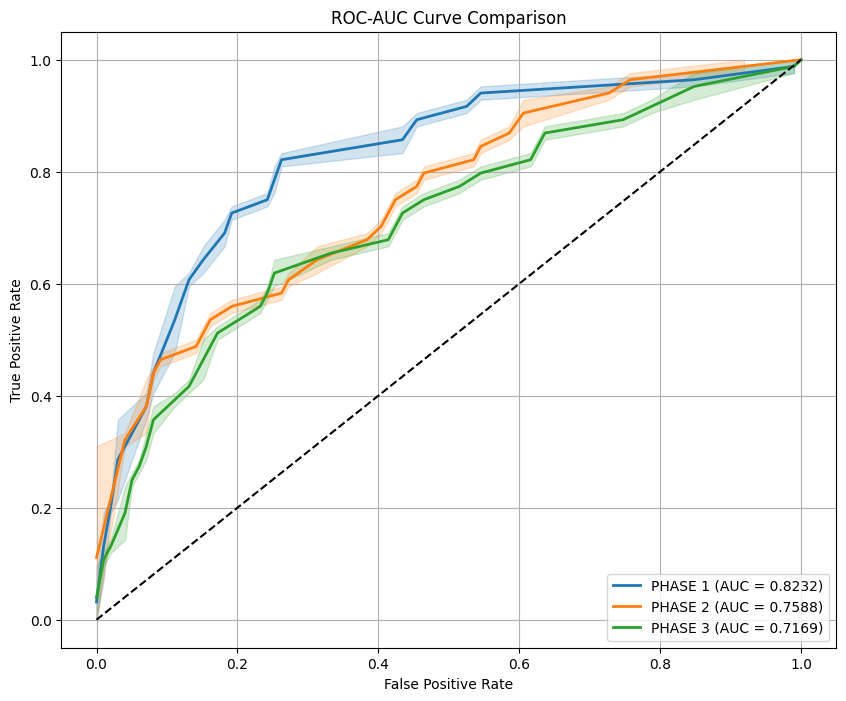

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold

from sklearn.feature_selection import (
    VarianceThreshold,
    SelectKBest,
    mutual_info_classif
)

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_curve
)

# load dataset
df = pd.read_csv("../../data/multimodal_audio_text_features.csv")

print("-" * 60)
print("DATASET INFORMATION")
print("-" * 60)

print("Dataset Shape:", df.shape)

# normalize phase column
df["phase"] = df["phase"].astype(str).str.lower().str.strip()

print("\nAvailable Phases:")
print(df["phase"].unique())

# remove non-feature columns
remove_cols = [
    "participant_id",
    "phase",
    "label"
]

feature_cols = [
    col for col in df.columns
    if col not in remove_cols
]

print("\nTotal Features:", len(feature_cols))

# store roc data
roc_data = {}

# training function
def train_phase_model(df_phase, phase_name):

    print("\n" + "-" * 60)
    print(f"TRAINING FOR {phase_name}")
    print("-" * 60)

    # drop missing values
    df_phase = df_phase.dropna()

    # features & labels
    X = df_phase[feature_cols]
    y = df_phase["label"].values

    print("Original Shape:", X.shape)
    print("Class Distribution:", np.bincount(y))

    # remove low variance features
    variance_selector = VarianceThreshold(
        threshold=0.00001
    )

    X = variance_selector.fit_transform(X)

    print("\nShape After Variance Threshold:", X.shape)

    # keep important multimodal features
    kbest_selector = SelectKBest(
        score_func=mutual_info_classif,
        k=min(350, X.shape[1])
    )

    X = kbest_selector.fit_transform(X, y)

    print("Shape After SelectKBest:", X.shape)

    # 10-fold stratified cv
    skf = StratifiedKFold(
        n_splits=10,
        shuffle=True,
        random_state=42
    )

    # store predictions
    all_probs = np.zeros(len(y))
    all_preds = np.zeros(len(y))

    fold_aucs = []

    # train each fold
    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):

        print(f"\n----- Fold {fold} -----")

        X_train, X_test = X[train_idx], X[test_idx]

        y_train, y_test = y[train_idx], y[test_idx]

        # random forest model
        model = RandomForestClassifier(

            # more trees
            n_estimators=800,

            # better multimodal learning
            max_depth=14,

            # reduce overfitting
            min_samples_split=3,
            min_samples_leaf=1,

            # better feature selection
            max_features="sqrt",

            # handle imbalance
            class_weight="balanced",

            # bootstrap sampling
            bootstrap=True,

            random_state=42,
            n_jobs=-1
        )

        # train model
        model.fit(X_train, y_train)

        # predict
        y_prob = model.predict_proba(X_test)[:, 1]

        THRESHOLD = 0.30

        y_pred = (y_prob > THRESHOLD).astype(int)

        # store predictions
        all_probs[test_idx] = y_prob
        all_preds[test_idx] = y_pred

        # fold roc-auc
        fold_auc = roc_auc_score(y_test, y_prob)

        fold_aucs.append(fold_auc)

        print("Fold ROC-AUC:", round(fold_auc, 4))

    # final results
    overall_auc = roc_auc_score(y, all_probs)

    print("\n" + "-" * 60)
    print(f"FINAL RESULTS FOR {phase_name}")
    print("-" * 60)

    print("\nFold ROC-AUC Scores:")
    print(np.round(fold_aucs, 4))

    print("\nMean Fold ROC-AUC:")
    print(round(np.mean(fold_aucs), 4))

    print("\nOverall ROC-AUC:")
    print(round(overall_auc, 4))

    # classification report
    print("\nClassification Report:")
    print(classification_report(
        y,
        all_preds,
        zero_division=0
    ))

    # precision score
    precision = precision_score(
        y,
        all_preds,
        zero_division=0
    )

    print("Precision Score:", round(precision, 4))

    # recall score
    recall = recall_score(
        y,
        all_preds,
        zero_division=0
    )

    print("Recall Score:", round(recall, 4))

    # f1 score
    f1 = f1_score(
        y,
        all_preds,
        zero_division=0
    )

    print("F1 Score:", round(f1, 4))

    # confusion matrix
    cm = confusion_matrix(y, all_preds)

    print("\nConfusion Matrix:")
    print(cm)

    # draw confusion matrix
    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False
    )

    plt.title(f"{phase_name} Confusion Matrix")

    plt.xlabel("Predicted Label")

    plt.ylabel("True Label")

    plt.tight_layout()

    plt.show()

    # roc curve values
    fpr, tpr, _ = roc_curve(y, all_probs)

    roc_data[phase_name] = {
        "fpr": fpr,
        "tpr": tpr,
        "auc": overall_auc
    }

    return overall_auc, precision, recall, f1

# filter data phase-wise
df_p1 = df[df["phase"] == "phase1"]

df_p2 = df[df["phase"] == "phase2"]

df_p3 = df[df["phase"] == "phase3"]

# train models
roc_p1, prec_p1, rec_p1, f1_p1 = train_phase_model(
    df_p1,
    "PHASE 1"
)

roc_p2, prec_p2, rec_p2, f1_p2 = train_phase_model(
    df_p2,
    "PHASE 2"
)

roc_p3, prec_p3, rec_p3, f1_p3 = train_phase_model(
    df_p3,
    "PHASE 3"
)

# final summary
print("\n" + "-" * 60)
print("FINAL ROC-AUC SCORES")
print("-" * 60)

print(f"Phase 1 ROC-AUC: {roc_p1:.4f}")
print(f"Phase 1 Precision: {prec_p1:.4f}")
print(f"Phase 1 Recall: {rec_p1:.4f}")
print(f"Phase 1 F1 Score: {f1_p1:.4f}")

print()

print(f"Phase 2 ROC-AUC: {roc_p2:.4f}")
print(f"Phase 2 Precision: {prec_p2:.4f}")
print(f"Phase 2 Recall: {rec_p2:.4f}")
print(f"Phase 2 F1 Score: {f1_p2:.4f}")

print()

print(f"Phase 3 ROC-AUC: {roc_p3:.4f}")
print(f"Phase 3 Precision: {prec_p3:.4f}")
print(f"Phase 3 Recall: {rec_p3:.4f}")
print(f"Phase 3 F1 Score: {f1_p3:.4f}")

# final roc auc curve
plt.figure(figsize=(10, 8))

for phase_name, values in roc_data.items():

    sns.lineplot(
        x=values["fpr"],
        y=values["tpr"],
        linewidth=2,
        label=f"{phase_name} (AUC = {values['auc']:.4f})"
    )

sns.lineplot(
    x=[0, 1],
    y=[0, 1],
    linestyle="--",
    color="black"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC-AUC Curve Comparison")

plt.legend(loc="lower right")

plt.grid(True)

plt.show()

SVM

------------------------------------------------------------
DATASET INFORMATION
------------------------------------------------------------
Dataset Shape: (423, 911)

Available Phases:
<StringArray>
['phase1', 'phase2', 'phase3']
Length: 3, dtype: str

Total Features: 908

------------------------------------------------------------
TRAINING FOR PHASE 1
------------------------------------------------------------
Original Shape: (141, 908)
Class Distribution: [99 42]

Shape After Variance Threshold: (141, 898)
Shape After SelectKBest: (141, 240)

Predicted Distribution:
[19 10]

Actual Distribution:
[20  9]

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.75      0.77        20
           1       0.50      0.56      0.53         9

    accuracy                           0.69        29
   macro avg       0.64      0.65      0.65        29
weighted avg       0.70      0.69      0.69        29

Precision Score: 0.5
Recall Scor

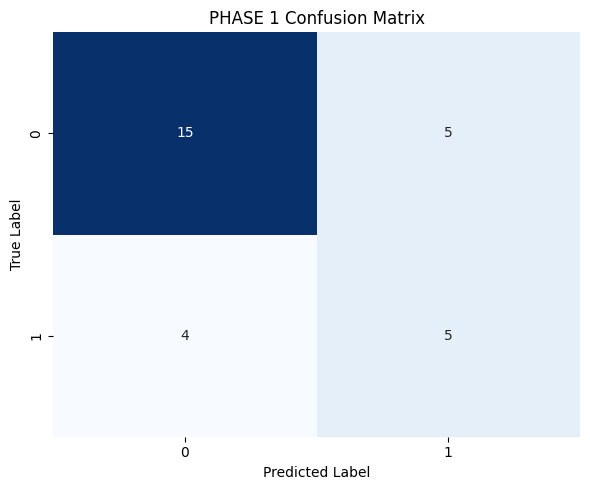


------------------------------------------------------------
TRAINING FOR PHASE 2
------------------------------------------------------------
Original Shape: (141, 908)
Class Distribution: [99 42]

Shape After Variance Threshold: (141, 897)
Shape After SelectKBest: (141, 240)

Predicted Distribution:
[20  9]

Actual Distribution:
[20  9]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.80      0.80        20
           1       0.56      0.56      0.56         9

    accuracy                           0.72        29
   macro avg       0.68      0.68      0.68        29
weighted avg       0.72      0.72      0.72        29

Precision Score: 0.5556
Recall Score: 0.5556
F1 Score: 0.5556
ROC-AUC Score: 0.7722

Confusion Matrix:
[[16  4]
 [ 4  5]]


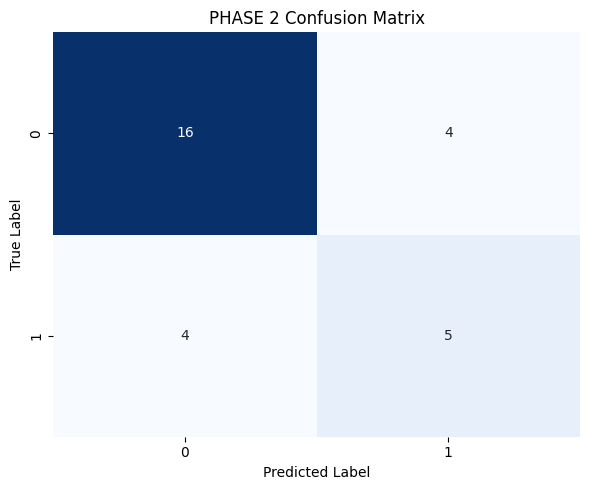


------------------------------------------------------------
TRAINING FOR PHASE 3
------------------------------------------------------------
Original Shape: (141, 908)
Class Distribution: [99 42]

Shape After Variance Threshold: (141, 898)
Shape After SelectKBest: (141, 240)

Predicted Distribution:
[20  9]

Actual Distribution:
[20  9]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.80      0.80        20
           1       0.56      0.56      0.56         9

    accuracy                           0.72        29
   macro avg       0.68      0.68      0.68        29
weighted avg       0.72      0.72      0.72        29

Precision Score: 0.5556
Recall Score: 0.5556
F1 Score: 0.5556
ROC-AUC Score: 0.6944

Confusion Matrix:
[[16  4]
 [ 4  5]]


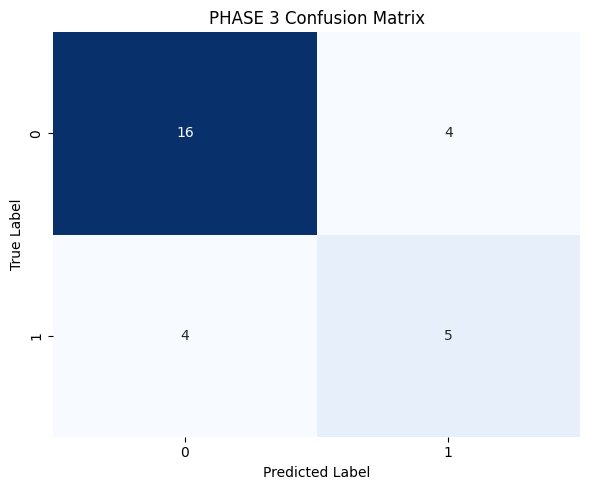


------------------------------------------------------------
FINAL ROC-AUC SCORES
------------------------------------------------------------
Phase 1 ROC-AUC: 0.7833
Phase 1 Precision: 0.5000
Phase 1 Recall: 0.5556
Phase 1 F1 Score: 0.5263

Phase 2 ROC-AUC: 0.7722
Phase 2 Precision: 0.5556
Phase 2 Recall: 0.5556
Phase 2 F1 Score: 0.5556

Phase 3 ROC-AUC: 0.6944
Phase 3 Precision: 0.5556
Phase 3 Recall: 0.5556
Phase 3 F1 Score: 0.5556


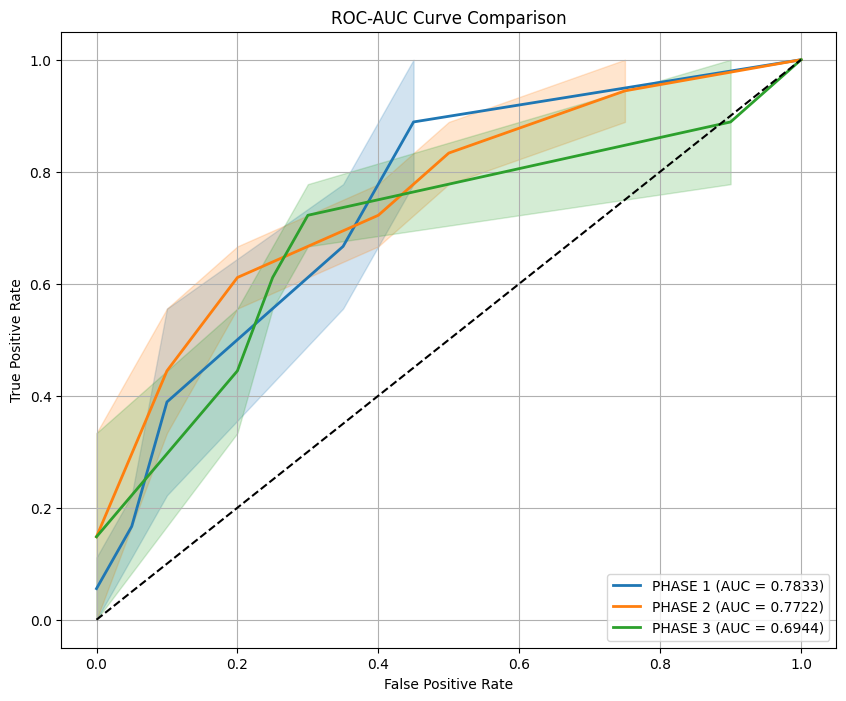

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.feature_selection import (
    VarianceThreshold,
    SelectKBest,
    mutual_info_classif
)

from sklearn.svm import SVC

from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_curve
)

# load dataset
df = pd.read_csv("../../data/multimodal_audio_text_features.csv")

print("-" * 60)
print("DATASET INFORMATION")
print("-" * 60)

print("Dataset Shape:", df.shape)

# normalize phase column
df["phase"] = df["phase"].astype(str).str.lower().str.strip()

print("\nAvailable Phases:")
print(df["phase"].unique())

# remove non-feature columns
remove_cols = [
    "participant_id",
    "phase",
    "label"
]

feature_cols = [
    col for col in df.columns
    if col not in remove_cols
]

print("\nTotal Features:", len(feature_cols))

# store roc data
roc_data = {}

# training function
def train_phase_model(df_phase, phase_name):

    print("\n" + "-" * 60)
    print(f"TRAINING FOR {phase_name}")
    print("-" * 60)

    # drop missing values
    df_phase = df_phase.dropna()

    # features & labels
    X = df_phase[feature_cols]
    y = df_phase["label"].values

    print("Original Shape:", X.shape)
    print("Class Distribution:", np.bincount(y))

    # remove low variance features
    variance_selector = VarianceThreshold(
        threshold=0.00001
    )

    X = variance_selector.fit_transform(X)

    print("\nShape After Variance Threshold:", X.shape)

    # keep important multimodal features
    kbest_selector = SelectKBest(
        score_func=mutual_info_classif,
        k=min(240, X.shape[1])
    )

    X = kbest_selector.fit_transform(X, y)

    print("Shape After SelectKBest:", X.shape)

    # train test split
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        stratify=y,
        random_state=42
    )

    # feature scaling
    scaler = StandardScaler()

    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # balanced phase-1 svm
    model = SVC(

        # nonlinear boundary
        kernel="rbf",

        # balanced flexibility
        C=1.0,

        # moderate kernel smoothness
        gamma=0.004,

        # handle imbalance
        class_weight="balanced",

        # enable probabilities
        probability=True,

        random_state=42
    )

    # train model
    model.fit(X_train, y_train)

    # predict probabilities
    y_prob = model.predict_proba(X_test)[:, 1]

    # threshold
    THRESHOLD = 0.34

    y_pred = (y_prob > THRESHOLD).astype(int)

    print("\nPredicted Distribution:")
    print(np.bincount(y_pred))

    print("\nActual Distribution:")
    print(np.bincount(y_test))

    # classification report
    print("\nClassification Report:")
    print(classification_report(
        y_test,
        y_pred,
        zero_division=0
    ))

    # precision score
    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    print("Precision Score:", round(precision, 4))

    # recall score
    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    print("Recall Score:", round(recall, 4))

    # f1 score
    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    print("F1 Score:", round(f1, 4))

    # roc-auc
    roc = roc_auc_score(y_test, y_prob)

    print("ROC-AUC Score:", round(roc, 4))

    # confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    print("\nConfusion Matrix:")
    print(cm)

    # draw confusion matrix
    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False
    )

    plt.title(f"{phase_name} Confusion Matrix")

    plt.xlabel("Predicted Label")

    plt.ylabel("True Label")

    plt.tight_layout()

    plt.show()

    # roc curve values
    fpr, tpr, _ = roc_curve(y_test, y_prob)

    roc_data[phase_name] = {
        "fpr": fpr,
        "tpr": tpr,
        "auc": roc
    }

    return model, roc, precision, recall, f1

# filter data phase-wise
df_p1 = df[df["phase"] == "phase1"]

df_p2 = df[df["phase"] == "phase2"]

df_p3 = df[df["phase"] == "phase3"]

# train models
model_p1, roc_p1, prec_p1, rec_p1, f1_p1 = train_phase_model(
    df_p1,
    "PHASE 1"
)

model_p2, roc_p2, prec_p2, rec_p2, f1_p2 = train_phase_model(
    df_p2,
    "PHASE 2"
)

model_p3, roc_p3, prec_p3, rec_p3, f1_p3 = train_phase_model(
    df_p3,
    "PHASE 3"
)

# final summary
print("\n" + "-" * 60)
print("FINAL ROC-AUC SCORES")
print("-" * 60)

print(f"Phase 1 ROC-AUC: {roc_p1:.4f}")
print(f"Phase 1 Precision: {prec_p1:.4f}")
print(f"Phase 1 Recall: {rec_p1:.4f}")
print(f"Phase 1 F1 Score: {f1_p1:.4f}")

print()

print(f"Phase 2 ROC-AUC: {roc_p2:.4f}")
print(f"Phase 2 Precision: {prec_p2:.4f}")
print(f"Phase 2 Recall: {rec_p2:.4f}")
print(f"Phase 2 F1 Score: {f1_p2:.4f}")

print()

print(f"Phase 3 ROC-AUC: {roc_p3:.4f}")
print(f"Phase 3 Precision: {prec_p3:.4f}")
print(f"Phase 3 Recall: {rec_p3:.4f}")
print(f"Phase 3 F1 Score: {f1_p3:.4f}")

# final roc auc curve
plt.figure(figsize=(10, 8))

for phase_name, values in roc_data.items():

    sns.lineplot(
        x=values["fpr"],
        y=values["tpr"],
        linewidth=2,
        label=f"{phase_name} (AUC = {values['auc']:.4f})"
    )

sns.lineplot(
    x=[0, 1],
    y=[0, 1],
    linestyle="--",
    color="black"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC-AUC Curve Comparison")

plt.legend(loc="lower right")

plt.grid(True)

plt.show()

SVM 5 folds

------------------------------------------------------------
DATASET INFORMATION
------------------------------------------------------------
Dataset Shape: (423, 911)

Available Phases:
<StringArray>
['phase1', 'phase2', 'phase3']
Length: 3, dtype: str

Total Features: 908

------------------------------------------------------------
TRAINING FOR PHASE 1
------------------------------------------------------------
Original Shape: (141, 908)
Class Distribution: [99 42]

Shape After Variance Threshold: (141, 898)
Shape After SelectKBest: (141, 240)

----- Fold 1 -----
Fold ROC-AUC: 0.5944

----- Fold 2 -----
Fold ROC-AUC: 0.9062

----- Fold 3 -----
Fold ROC-AUC: 0.7812

----- Fold 4 -----
Fold ROC-AUC: 0.8687

----- Fold 5 -----
Fold ROC-AUC: 0.9006

------------------------------------------------------------
FINAL RESULTS FOR PHASE 1
------------------------------------------------------------

Fold ROC-AUC Scores:
[0.5944 0.9062 0.7812 0.8688 0.9006]

Mean Fold ROC-AUC:
0.8103

Overa

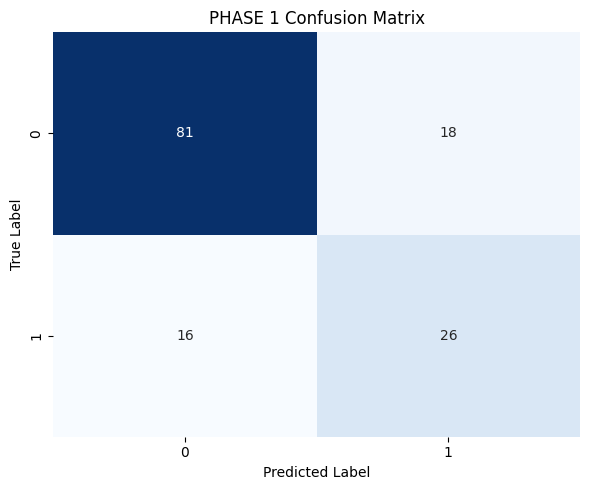


------------------------------------------------------------
TRAINING FOR PHASE 2
------------------------------------------------------------
Original Shape: (141, 908)
Class Distribution: [99 42]

Shape After Variance Threshold: (141, 897)
Shape After SelectKBest: (141, 240)

----- Fold 1 -----
Fold ROC-AUC: 0.6111

----- Fold 2 -----
Fold ROC-AUC: 0.7688

----- Fold 3 -----
Fold ROC-AUC: 0.7562

----- Fold 4 -----
Fold ROC-AUC: 0.8625

----- Fold 5 -----
Fold ROC-AUC: 0.7778

------------------------------------------------------------
FINAL RESULTS FOR PHASE 2
------------------------------------------------------------

Fold ROC-AUC Scores:
[0.6111 0.7688 0.7562 0.8625 0.7778]

Mean Fold ROC-AUC:
0.7553

Overall ROC-AUC:
0.7648

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.79      0.81        99
           1       0.55      0.62      0.58        42

    accuracy                           0.74       141
   macro avg  

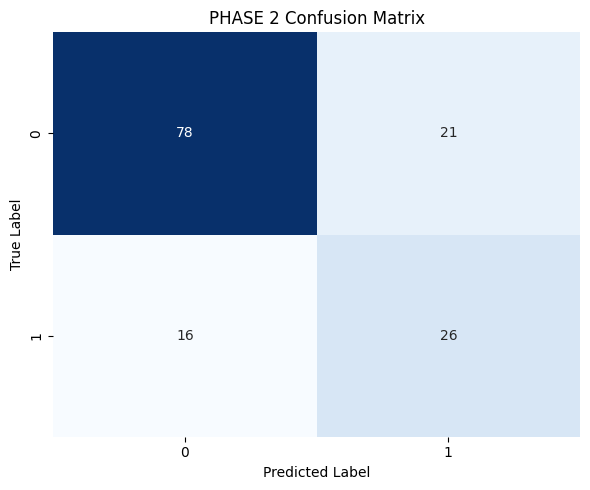


------------------------------------------------------------
TRAINING FOR PHASE 3
------------------------------------------------------------
Original Shape: (141, 908)
Class Distribution: [99 42]

Shape After Variance Threshold: (141, 898)
Shape After SelectKBest: (141, 240)

----- Fold 1 -----
Fold ROC-AUC: 0.7667

----- Fold 2 -----
Fold ROC-AUC: 0.7625

----- Fold 3 -----
Fold ROC-AUC: 0.675

----- Fold 4 -----
Fold ROC-AUC: 0.7188

----- Fold 5 -----
Fold ROC-AUC: 0.7778

------------------------------------------------------------
FINAL RESULTS FOR PHASE 3
------------------------------------------------------------

Fold ROC-AUC Scores:
[0.7667 0.7625 0.675  0.7188 0.7778]

Mean Fold ROC-AUC:
0.7401

Overall ROC-AUC:
0.7398

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.77      0.80        99
           1       0.53      0.62      0.57        42

    accuracy                           0.72       141
   macro avg   

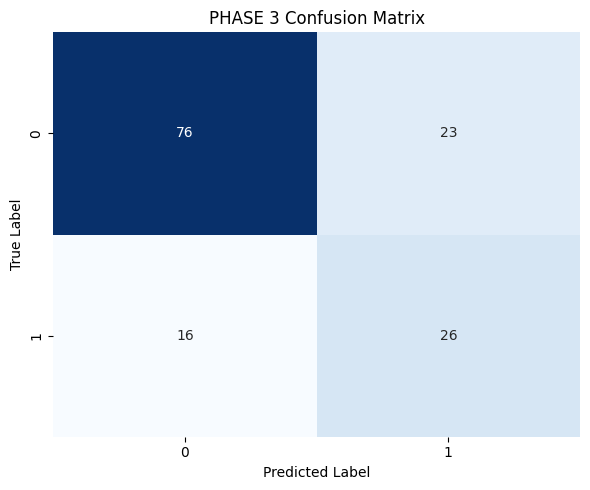


------------------------------------------------------------
FINAL ROC-AUC SCORES
------------------------------------------------------------
Phase 1 ROC-AUC: 0.8054
Phase 1 Precision: 0.5909
Phase 1 Recall: 0.6190
Phase 1 F1 Score: 0.6047

Phase 2 ROC-AUC: 0.7648
Phase 2 Precision: 0.5532
Phase 2 Recall: 0.6190
Phase 2 F1 Score: 0.5843

Phase 3 ROC-AUC: 0.7398
Phase 3 Precision: 0.5306
Phase 3 Recall: 0.6190
Phase 3 F1 Score: 0.5714


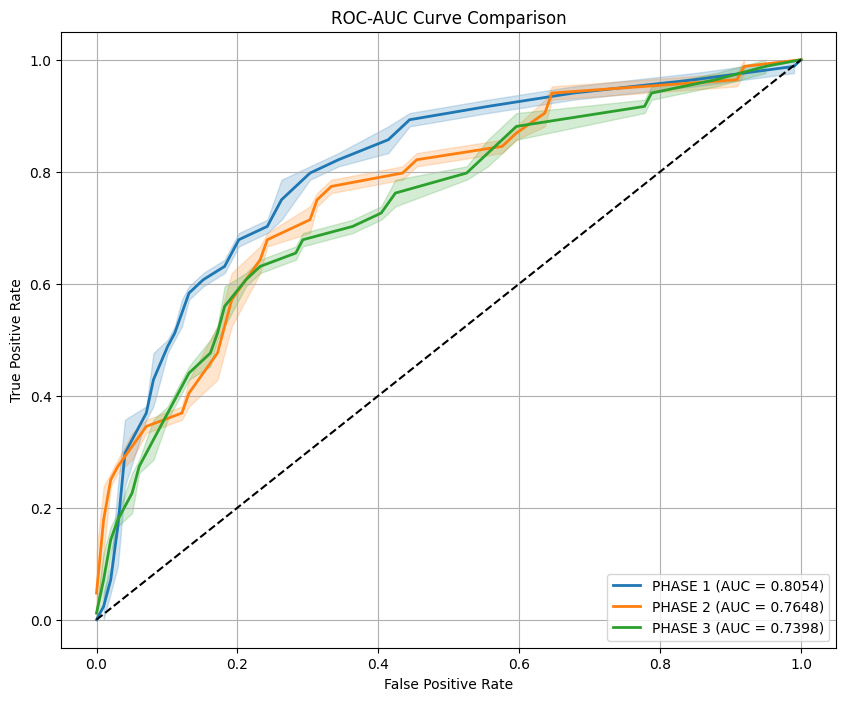

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler

from sklearn.feature_selection import (
    VarianceThreshold,
    SelectKBest,
    mutual_info_classif
)

from sklearn.svm import SVC

from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_curve
)

# load dataset
df = pd.read_csv("../../data/multimodal_audio_text_features.csv")

print("-" * 60)
print("DATASET INFORMATION")
print("-" * 60)

print("Dataset Shape:", df.shape)

# normalize phase column
df["phase"] = df["phase"].astype(str).str.lower().str.strip()

print("\nAvailable Phases:")
print(df["phase"].unique())

# remove non-feature columns
remove_cols = [
    "participant_id",
    "phase",
    "label"
]

feature_cols = [
    col for col in df.columns
    if col not in remove_cols
]

print("\nTotal Features:", len(feature_cols))

# store roc data
roc_data = {}

# training function
def train_phase_model(df_phase, phase_name):

    print("\n" + "-" * 60)
    print(f"TRAINING FOR {phase_name}")
    print("-" * 60)

    # drop missing values
    df_phase = df_phase.dropna()

    # features & labels
    X = df_phase[feature_cols]
    y = df_phase["label"].values

    print("Original Shape:", X.shape)
    print("Class Distribution:", np.bincount(y))

    # remove low variance features
    variance_selector = VarianceThreshold(
        threshold=0.00001
    )

    X = variance_selector.fit_transform(X)

    print("\nShape After Variance Threshold:", X.shape)

    # keep important multimodal features
    kbest_selector = SelectKBest(
        score_func=mutual_info_classif,
        k=min(240, X.shape[1])
    )

    X = kbest_selector.fit_transform(X, y)

    print("Shape After SelectKBest:", X.shape)

    # 5-fold stratified cv
    skf = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    # store predictions
    all_probs = np.zeros(len(y))
    all_preds = np.zeros(len(y))

    fold_aucs = []

    # train each fold
    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):

        print(f"\n----- Fold {fold} -----")

        X_train, X_test = X[train_idx], X[test_idx]

        y_train, y_test = y[train_idx], y[test_idx]

        # feature scaling
        scaler = StandardScaler()

        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        # balanced phase-1 svm
        model = SVC(

            # nonlinear boundary
            kernel="rbf",

            # balanced flexibility
            C=1.0,

            # moderate kernel smoothness
            gamma=0.004,

            # handle imbalance
            class_weight="balanced",

            # enable probabilities
            probability=True,

            random_state=42
        )

        # train model
        model.fit(X_train, y_train)

        # predict
        y_prob = model.predict_proba(X_test)[:, 1]

        THRESHOLD = 0.34

        y_pred = (y_prob > THRESHOLD).astype(int)

        # store predictions
        all_probs[test_idx] = y_prob
        all_preds[test_idx] = y_pred

        # fold roc-auc
        fold_auc = roc_auc_score(y_test, y_prob)

        fold_aucs.append(fold_auc)

        print("Fold ROC-AUC:", round(fold_auc, 4))

    # final results
    overall_auc = roc_auc_score(y, all_probs)

    print("\n" + "-" * 60)
    print(f"FINAL RESULTS FOR {phase_name}")
    print("-" * 60)

    print("\nFold ROC-AUC Scores:")
    print(np.round(fold_aucs, 4))

    print("\nMean Fold ROC-AUC:")
    print(round(np.mean(fold_aucs), 4))

    print("\nOverall ROC-AUC:")
    print(round(overall_auc, 4))

    # classification report
    print("\nClassification Report:")
    print(classification_report(
        y,
        all_preds,
        zero_division=0
    ))

    # precision score
    precision = precision_score(
        y,
        all_preds,
        zero_division=0
    )

    print("Precision Score:", round(precision, 4))

    # recall score
    recall = recall_score(
        y,
        all_preds,
        zero_division=0
    )

    print("Recall Score:", round(recall, 4))

    # f1 score
    f1 = f1_score(
        y,
        all_preds,
        zero_division=0
    )

    print("F1 Score:", round(f1, 4))

    # confusion matrix
    cm = confusion_matrix(y, all_preds)

    print("\nConfusion Matrix:")
    print(cm)

    # draw confusion matrix
    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False
    )

    plt.title(f"{phase_name} Confusion Matrix")

    plt.xlabel("Predicted Label")

    plt.ylabel("True Label")

    plt.tight_layout()

    plt.show()

    # roc curve values
    fpr, tpr, _ = roc_curve(y, all_probs)

    roc_data[phase_name] = {
        "fpr": fpr,
        "tpr": tpr,
        "auc": overall_auc
    }

    return overall_auc, precision, recall, f1

# filter data phase-wise
df_p1 = df[df["phase"] == "phase1"]

df_p2 = df[df["phase"] == "phase2"]

df_p3 = df[df["phase"] == "phase3"]

# train models
roc_p1, prec_p1, rec_p1, f1_p1 = train_phase_model(
    df_p1,
    "PHASE 1"
)

roc_p2, prec_p2, rec_p2, f1_p2 = train_phase_model(
    df_p2,
    "PHASE 2"
)

roc_p3, prec_p3, rec_p3, f1_p3 = train_phase_model(
    df_p3,
    "PHASE 3"
)

# final summary
print("\n" + "-" * 60)
print("FINAL ROC-AUC SCORES")
print("-" * 60)

print(f"Phase 1 ROC-AUC: {roc_p1:.4f}")
print(f"Phase 1 Precision: {prec_p1:.4f}")
print(f"Phase 1 Recall: {rec_p1:.4f}")
print(f"Phase 1 F1 Score: {f1_p1:.4f}")

print()

print(f"Phase 2 ROC-AUC: {roc_p2:.4f}")
print(f"Phase 2 Precision: {prec_p2:.4f}")
print(f"Phase 2 Recall: {rec_p2:.4f}")
print(f"Phase 2 F1 Score: {f1_p2:.4f}")

print()

print(f"Phase 3 ROC-AUC: {roc_p3:.4f}")
print(f"Phase 3 Precision: {prec_p3:.4f}")
print(f"Phase 3 Recall: {rec_p3:.4f}")
print(f"Phase 3 F1 Score: {f1_p3:.4f}")

# final roc auc curve
plt.figure(figsize=(10, 8))

for phase_name, values in roc_data.items():

    sns.lineplot(
        x=values["fpr"],
        y=values["tpr"],
        linewidth=2,
        label=f"{phase_name} (AUC = {values['auc']:.4f})"
    )

sns.lineplot(
    x=[0, 1],
    y=[0, 1],
    linestyle="--",
    color="black"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC-AUC Curve Comparison")

plt.legend(loc="lower right")

plt.grid(True)

plt.show()

SVM 10 folds

------------------------------------------------------------
DATASET INFORMATION
------------------------------------------------------------
Dataset Shape: (423, 911)

Available Phases:
<StringArray>
['phase1', 'phase2', 'phase3']
Length: 3, dtype: str

Total Features: 908

------------------------------------------------------------
TRAINING FOR PHASE 1
------------------------------------------------------------
Original Shape: (141, 908)
Class Distribution: [99 42]

Shape After Variance Threshold: (141, 898)
Shape After SelectKBest: (141, 240)

----- Fold 1 -----
Fold ROC-AUC: 0.44

----- Fold 2 -----
Fold ROC-AUC: 0.725

----- Fold 3 -----
Fold ROC-AUC: 0.95

----- Fold 4 -----
Fold ROC-AUC: 0.9

----- Fold 5 -----
Fold ROC-AUC: 0.9

----- Fold 6 -----
Fold ROC-AUC: 0.725

----- Fold 7 -----
Fold ROC-AUC: 0.925

----- Fold 8 -----
Fold ROC-AUC: 0.875

----- Fold 9 -----
Fold ROC-AUC: 0.925

----- Fold 10 -----
Fold ROC-AUC: 0.9333

-------------------------------------------------

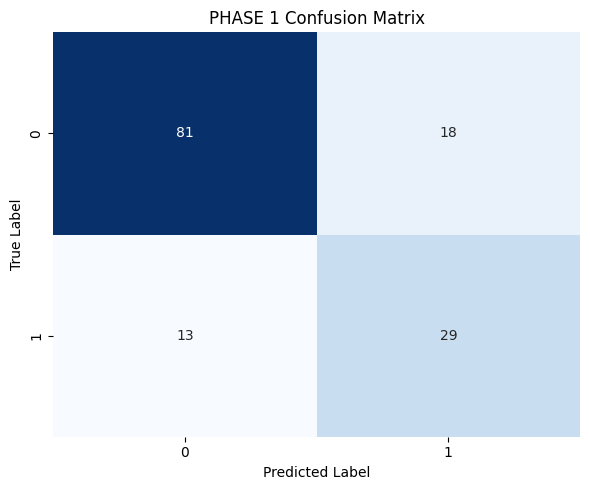


------------------------------------------------------------
TRAINING FOR PHASE 2
------------------------------------------------------------
Original Shape: (141, 908)
Class Distribution: [99 42]

Shape After Variance Threshold: (141, 897)
Shape After SelectKBest: (141, 240)

----- Fold 1 -----
Fold ROC-AUC: 0.7

----- Fold 2 -----
Fold ROC-AUC: 0.7

----- Fold 3 -----
Fold ROC-AUC: 0.75

----- Fold 4 -----
Fold ROC-AUC: 0.775

----- Fold 5 -----
Fold ROC-AUC: 0.9

----- Fold 6 -----
Fold ROC-AUC: 0.75

----- Fold 7 -----
Fold ROC-AUC: 0.75

----- Fold 8 -----
Fold ROC-AUC: 1.0

----- Fold 9 -----
Fold ROC-AUC: 0.7

----- Fold 10 -----
Fold ROC-AUC: 0.8222

------------------------------------------------------------
FINAL RESULTS FOR PHASE 2
------------------------------------------------------------

Fold ROC-AUC Scores:
[0.7    0.7    0.75   0.775  0.9    0.75   0.75   1.     0.7    0.8222]

Mean Fold ROC-AUC:
0.7847

Overall ROC-AUC:
0.7662

Classification Report:
             

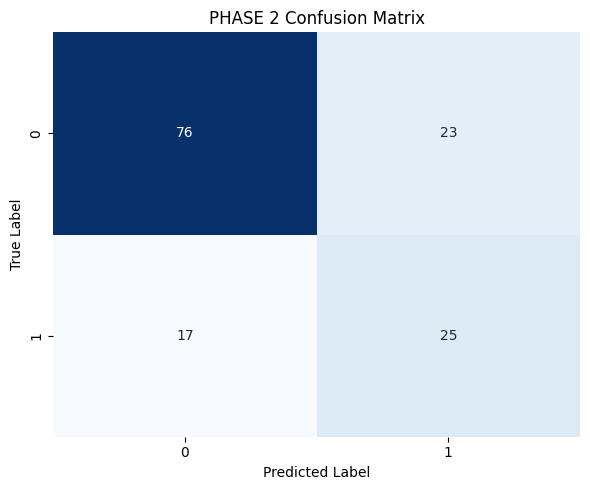


------------------------------------------------------------
TRAINING FOR PHASE 3
------------------------------------------------------------
Original Shape: (141, 908)
Class Distribution: [99 42]

Shape After Variance Threshold: (141, 898)
Shape After SelectKBest: (141, 240)

----- Fold 1 -----
Fold ROC-AUC: 0.66

----- Fold 2 -----
Fold ROC-AUC: 1.0

----- Fold 3 -----
Fold ROC-AUC: 0.675

----- Fold 4 -----
Fold ROC-AUC: 0.85

----- Fold 5 -----
Fold ROC-AUC: 0.875

----- Fold 6 -----
Fold ROC-AUC: 0.525

----- Fold 7 -----
Fold ROC-AUC: 0.9

----- Fold 8 -----
Fold ROC-AUC: 0.775

----- Fold 9 -----
Fold ROC-AUC: 0.8

----- Fold 10 -----
Fold ROC-AUC: 0.8667

------------------------------------------------------------
FINAL RESULTS FOR PHASE 3
------------------------------------------------------------

Fold ROC-AUC Scores:
[0.66   1.     0.675  0.85   0.875  0.525  0.9    0.775  0.8    0.8667]

Mean Fold ROC-AUC:
0.7927

Overall ROC-AUC:
0.7576

Classification Report:
        

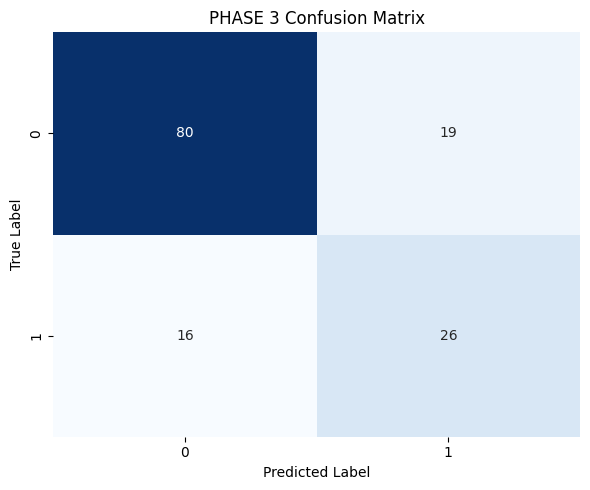


------------------------------------------------------------
FINAL ROC-AUC SCORES
------------------------------------------------------------
Phase 1 ROC-AUC: 0.8249
Phase 1 Precision: 0.6170
Phase 1 Recall: 0.6905
Phase 1 F1 Score: 0.6517

Phase 2 ROC-AUC: 0.7662
Phase 2 Precision: 0.5208
Phase 2 Recall: 0.5952
Phase 2 F1 Score: 0.5556

Phase 3 ROC-AUC: 0.7576
Phase 3 Precision: 0.5778
Phase 3 Recall: 0.6190
Phase 3 F1 Score: 0.5977


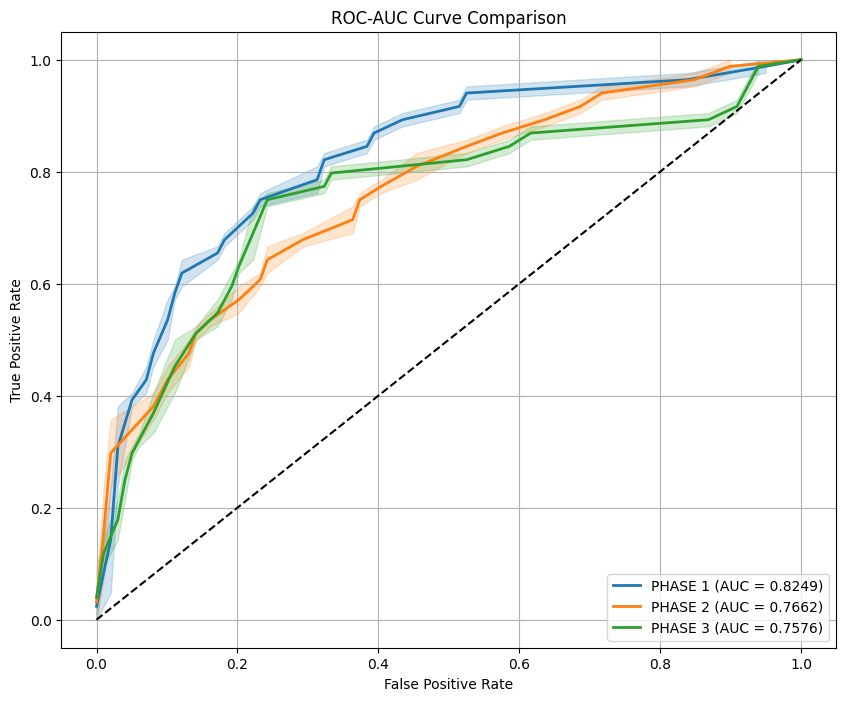

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler

from sklearn.feature_selection import (
    VarianceThreshold,
    SelectKBest,
    mutual_info_classif
)

from sklearn.svm import SVC

from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_curve
)

# load dataset
df = pd.read_csv("../../data/multimodal_audio_text_features.csv")

print("-" * 60)
print("DATASET INFORMATION")
print("-" * 60)

print("Dataset Shape:", df.shape)

# normalize phase column
df["phase"] = df["phase"].astype(str).str.lower().str.strip()

print("\nAvailable Phases:")
print(df["phase"].unique())

# remove non-feature columns
remove_cols = [
    "participant_id",
    "phase",
    "label"
]

feature_cols = [
    col for col in df.columns
    if col not in remove_cols
]

print("\nTotal Features:", len(feature_cols))

# store roc data
roc_data = {}

# training function
def train_phase_model(df_phase, phase_name):

    print("\n" + "-" * 60)
    print(f"TRAINING FOR {phase_name}")
    print("-" * 60)

    # drop missing values
    df_phase = df_phase.dropna()

    # features & labels
    X = df_phase[feature_cols]
    y = df_phase["label"].values

    print("Original Shape:", X.shape)
    print("Class Distribution:", np.bincount(y))

    # remove low variance features
    variance_selector = VarianceThreshold(
        threshold=0.00001
    )

    X = variance_selector.fit_transform(X)

    print("\nShape After Variance Threshold:", X.shape)

    # keep important multimodal features
    kbest_selector = SelectKBest(
        score_func=mutual_info_classif,
        k=min(240, X.shape[1])
    )

    X = kbest_selector.fit_transform(X, y)

    print("Shape After SelectKBest:", X.shape)

    # 10-fold stratified cv
    skf = StratifiedKFold(
        n_splits=10,
        shuffle=True,
        random_state=42
    )

    # store predictions
    all_probs = np.zeros(len(y))
    all_preds = np.zeros(len(y))

    fold_aucs = []

    # train each fold
    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):

        print(f"\n----- Fold {fold} -----")

        X_train, X_test = X[train_idx], X[test_idx]

        y_train, y_test = y[train_idx], y[test_idx]

        # feature scaling
        scaler = StandardScaler()

        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        # balanced phase-1 svm
        model = SVC(

            # nonlinear boundary
            kernel="rbf",

            # balanced flexibility
            C=1.0,

            # moderate kernel smoothness
            gamma=0.004,

            # handle imbalance
            class_weight="balanced",

            # enable probabilities
            probability=True,

            random_state=42
        )

        # train model
        model.fit(X_train, y_train)

        # predict
        y_prob = model.predict_proba(X_test)[:, 1]

        THRESHOLD = 0.34

        y_pred = (y_prob > THRESHOLD).astype(int)

        # store predictions
        all_probs[test_idx] = y_prob
        all_preds[test_idx] = y_pred

        # fold roc-auc
        fold_auc = roc_auc_score(y_test, y_prob)

        fold_aucs.append(fold_auc)

        print("Fold ROC-AUC:", round(fold_auc, 4))

    # final results
    overall_auc = roc_auc_score(y, all_probs)

    print("\n" + "-" * 60)
    print(f"FINAL RESULTS FOR {phase_name}")
    print("-" * 60)

    print("\nFold ROC-AUC Scores:")
    print(np.round(fold_aucs, 4))

    print("\nMean Fold ROC-AUC:")
    print(round(np.mean(fold_aucs), 4))

    print("\nOverall ROC-AUC:")
    print(round(overall_auc, 4))

    # classification report
    print("\nClassification Report:")
    print(classification_report(
        y,
        all_preds,
        zero_division=0
    ))

    # precision score
    precision = precision_score(
        y,
        all_preds,
        zero_division=0
    )

    print("Precision Score:", round(precision, 4))

    # recall score
    recall = recall_score(
        y,
        all_preds,
        zero_division=0
    )

    print("Recall Score:", round(recall, 4))

    # f1 score
    f1 = f1_score(
        y,
        all_preds,
        zero_division=0
    )

    print("F1 Score:", round(f1, 4))

    # confusion matrix
    cm = confusion_matrix(y, all_preds)

    print("\nConfusion Matrix:")
    print(cm)

    # draw confusion matrix
    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False
    )

    plt.title(f"{phase_name} Confusion Matrix")

    plt.xlabel("Predicted Label")

    plt.ylabel("True Label")

    plt.tight_layout()

    plt.show()

    # roc curve values
    fpr, tpr, _ = roc_curve(y, all_probs)

    roc_data[phase_name] = {
        "fpr": fpr,
        "tpr": tpr,
        "auc": overall_auc
    }

    return overall_auc, precision, recall, f1

# filter data phase-wise
df_p1 = df[df["phase"] == "phase1"]

df_p2 = df[df["phase"] == "phase2"]

df_p3 = df[df["phase"] == "phase3"]

# train models
roc_p1, prec_p1, rec_p1, f1_p1 = train_phase_model(
    df_p1,
    "PHASE 1"
)

roc_p2, prec_p2, rec_p2, f1_p2 = train_phase_model(
    df_p2,
    "PHASE 2"
)

roc_p3, prec_p3, rec_p3, f1_p3 = train_phase_model(
    df_p3,
    "PHASE 3"
)

# final summary
print("\n" + "-" * 60)
print("FINAL ROC-AUC SCORES")
print("-" * 60)

print(f"Phase 1 ROC-AUC: {roc_p1:.4f}")
print(f"Phase 1 Precision: {prec_p1:.4f}")
print(f"Phase 1 Recall: {rec_p1:.4f}")
print(f"Phase 1 F1 Score: {f1_p1:.4f}")

print()

print(f"Phase 2 ROC-AUC: {roc_p2:.4f}")
print(f"Phase 2 Precision: {prec_p2:.4f}")
print(f"Phase 2 Recall: {rec_p2:.4f}")
print(f"Phase 2 F1 Score: {f1_p2:.4f}")

print()

print(f"Phase 3 ROC-AUC: {roc_p3:.4f}")
print(f"Phase 3 Precision: {prec_p3:.4f}")
print(f"Phase 3 Recall: {rec_p3:.4f}")
print(f"Phase 3 F1 Score: {f1_p3:.4f}")

# final roc auc curve
plt.figure(figsize=(10, 8))

for phase_name, values in roc_data.items():

    sns.lineplot(
        x=values["fpr"],
        y=values["tpr"],
        linewidth=2,
        label=f"{phase_name} (AUC = {values['auc']:.4f})"
    )

sns.lineplot(
    x=[0, 1],
    y=[0, 1],
    linestyle="--",
    color="black"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC-AUC Curve Comparison")

plt.legend(loc="lower right")

plt.grid(True)

plt.show()

Logistic Regression

------------------------------------------------------------
DATASET INFORMATION
------------------------------------------------------------
Dataset Shape: (423, 911)

Available Phases:
<StringArray>
['phase1', 'phase2', 'phase3']
Length: 3, dtype: str

Total Features: 908

------------------------------------------------------------
TRAINING FOR PHASE 1
------------------------------------------------------------
Original Shape: (141, 908)
Class Distribution: [99 42]

Shape After Variance Threshold: (141, 898)
Shape After SelectKBest: (141, 220)

Predicted Distribution:
[17 12]

Actual Distribution:
[20  9]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.75      0.81        20
           1       0.58      0.78      0.67         9

    accuracy                           0.76        29
   macro avg       0.73      0.76      0.74        29
weighted avg       0.79      0.76      0.77        29

Precision Score: 0.5833
Recall S

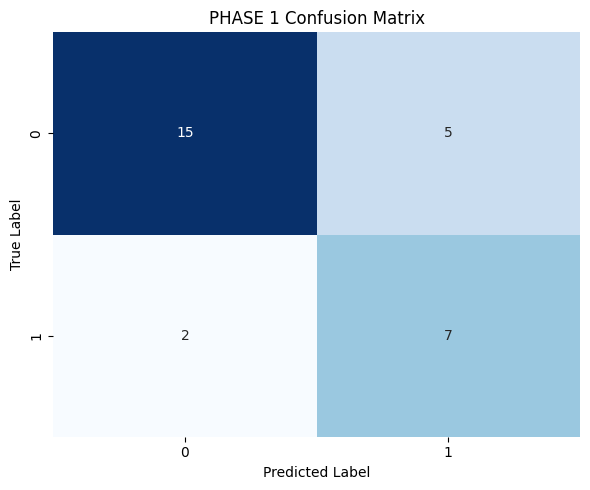


------------------------------------------------------------
TRAINING FOR PHASE 2
------------------------------------------------------------
Original Shape: (141, 908)
Class Distribution: [99 42]

Shape After Variance Threshold: (141, 897)
Shape After SelectKBest: (141, 220)

Predicted Distribution:
[20  9]

Actual Distribution:
[20  9]

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.75      0.75        20
           1       0.44      0.44      0.44         9

    accuracy                           0.66        29
   macro avg       0.60      0.60      0.60        29
weighted avg       0.66      0.66      0.66        29

Precision Score: 0.4444
Recall Score: 0.4444
F1 Score: 0.4444
ROC-AUC Score: 0.6722

Confusion Matrix:
[[15  5]
 [ 5  4]]


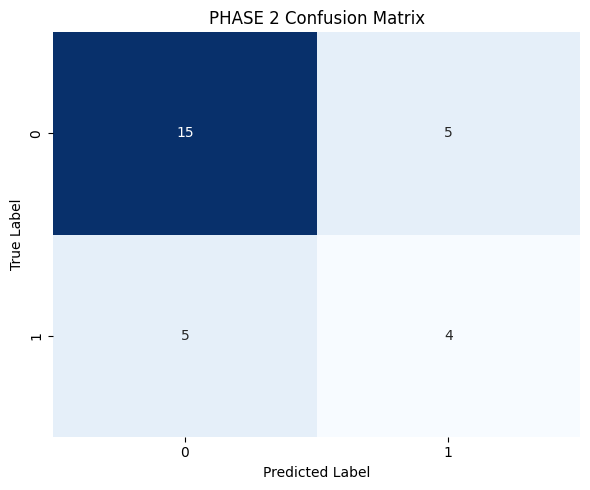


------------------------------------------------------------
TRAINING FOR PHASE 3
------------------------------------------------------------
Original Shape: (141, 908)
Class Distribution: [99 42]

Shape After Variance Threshold: (141, 898)
Shape After SelectKBest: (141, 220)

Predicted Distribution:
[18 11]

Actual Distribution:
[20  9]

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.65      0.68        20
           1       0.36      0.44      0.40         9

    accuracy                           0.59        29
   macro avg       0.54      0.55      0.54        29
weighted avg       0.61      0.59      0.60        29

Precision Score: 0.3636
Recall Score: 0.4444
F1 Score: 0.4
ROC-AUC Score: 0.5722

Confusion Matrix:
[[13  7]
 [ 5  4]]


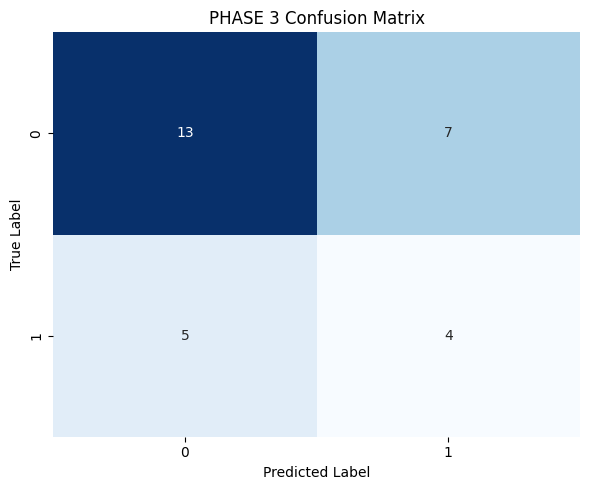


------------------------------------------------------------
FINAL ROC-AUC SCORES
------------------------------------------------------------
Phase 1 ROC-AUC: 0.7833
Phase 1 Precision: 0.5833
Phase 1 Recall: 0.7778
Phase 1 F1 Score: 0.6667

Phase 2 ROC-AUC: 0.6722
Phase 2 Precision: 0.4444
Phase 2 Recall: 0.4444
Phase 2 F1 Score: 0.4444

Phase 3 ROC-AUC: 0.5722
Phase 3 Precision: 0.3636
Phase 3 Recall: 0.4444
Phase 3 F1 Score: 0.4000


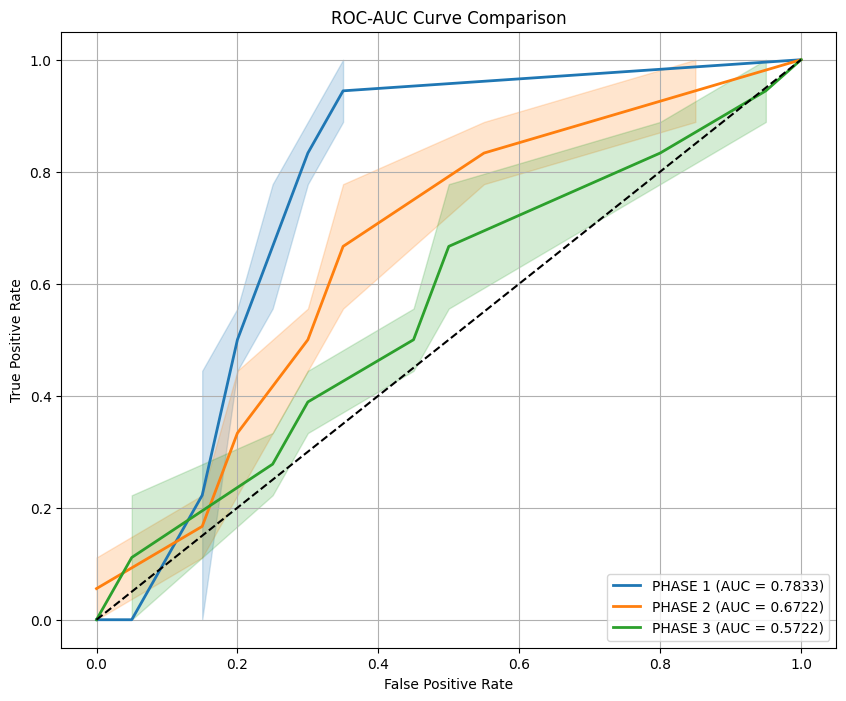

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.feature_selection import (
    VarianceThreshold,
    SelectKBest,
    mutual_info_classif
)

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_curve
)

# load dataset
df = pd.read_csv("../../data/multimodal_audio_text_features.csv")

print("-" * 60)
print("DATASET INFORMATION")
print("-" * 60)

print("Dataset Shape:", df.shape)

# normalize phase column
df["phase"] = df["phase"].astype(str).str.lower().str.strip()

print("\nAvailable Phases:")
print(df["phase"].unique())

# remove non-feature columns
remove_cols = [
    "participant_id",
    "phase",
    "label"
]

feature_cols = [
    col for col in df.columns
    if col not in remove_cols
]

print("\nTotal Features:", len(feature_cols))

# store roc data
roc_data = {}

# training function
def train_phase_model(df_phase, phase_name):

    print("\n" + "-" * 60)
    print(f"TRAINING FOR {phase_name}")
    print("-" * 60)

    # drop missing values
    df_phase = df_phase.dropna()

    # features & labels
    X = df_phase[feature_cols]
    y = df_phase["label"].values

    print("Original Shape:", X.shape)
    print("Class Distribution:", np.bincount(y))

    # remove low variance features
    variance_selector = VarianceThreshold(
        threshold=0.00001
    )

    X = variance_selector.fit_transform(X)

    print("\nShape After Variance Threshold:", X.shape)

    # keep important multimodal features
    kbest_selector = SelectKBest(
        score_func=mutual_info_classif,
        k=min(220, X.shape[1])
    )

    X = kbest_selector.fit_transform(X, y)

    print("Shape After SelectKBest:", X.shape)

    # train test split
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        stratify=y,
        random_state=42
    )

    # feature scaling
    scaler = StandardScaler()

    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # logistic regression model
    model = LogisticRegression(

        # better convergence
        solver="saga",

        # moderate regularization
        C=0.8,

        # handle imbalance
        class_weight="balanced",

        # more iterations
        max_iter=5000,

        random_state=42
    )

    # train model
    model.fit(X_train, y_train)

    # predict probabilities
    y_prob = model.predict_proba(X_test)[:, 1]

    # threshold
    THRESHOLD = 0.34

    y_pred = (y_prob > THRESHOLD).astype(int)

    print("\nPredicted Distribution:")
    print(np.bincount(y_pred))

    print("\nActual Distribution:")
    print(np.bincount(y_test))

    # classification report
    print("\nClassification Report:")
    print(classification_report(
        y_test,
        y_pred,
        zero_division=0
    ))

    # precision score
    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    print("Precision Score:", round(precision, 4))

    # recall score
    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    print("Recall Score:", round(recall, 4))

    # f1 score
    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    print("F1 Score:", round(f1, 4))

    # roc-auc
    roc = roc_auc_score(y_test, y_prob)

    print("ROC-AUC Score:", round(roc, 4))

    # confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    print("\nConfusion Matrix:")
    print(cm)

    # draw confusion matrix
    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False
    )

    plt.title(f"{phase_name} Confusion Matrix")

    plt.xlabel("Predicted Label")

    plt.ylabel("True Label")

    plt.tight_layout()

    plt.show()

    # roc curve values
    fpr, tpr, _ = roc_curve(y_test, y_prob)

    roc_data[phase_name] = {
        "fpr": fpr,
        "tpr": tpr,
        "auc": roc
    }

    return model, roc, precision, recall, f1

# filter data phase-wise
df_p1 = df[df["phase"] == "phase1"]

df_p2 = df[df["phase"] == "phase2"]

df_p3 = df[df["phase"] == "phase3"]

# train models
model_p1, roc_p1, prec_p1, rec_p1, f1_p1 = train_phase_model(
    df_p1,
    "PHASE 1"
)

model_p2, roc_p2, prec_p2, rec_p2, f1_p2 = train_phase_model(
    df_p2,
    "PHASE 2"
)

model_p3, roc_p3, prec_p3, rec_p3, f1_p3 = train_phase_model(
    df_p3,
    "PHASE 3"
)

# final summary
print("\n" + "-" * 60)
print("FINAL ROC-AUC SCORES")
print("-" * 60)

print(f"Phase 1 ROC-AUC: {roc_p1:.4f}")
print(f"Phase 1 Precision: {prec_p1:.4f}")
print(f"Phase 1 Recall: {rec_p1:.4f}")
print(f"Phase 1 F1 Score: {f1_p1:.4f}")

print()

print(f"Phase 2 ROC-AUC: {roc_p2:.4f}")
print(f"Phase 2 Precision: {prec_p2:.4f}")
print(f"Phase 2 Recall: {rec_p2:.4f}")
print(f"Phase 2 F1 Score: {f1_p2:.4f}")

print()

print(f"Phase 3 ROC-AUC: {roc_p3:.4f}")
print(f"Phase 3 Precision: {prec_p3:.4f}")
print(f"Phase 3 Recall: {rec_p3:.4f}")
print(f"Phase 3 F1 Score: {f1_p3:.4f}")

# final roc auc curve
plt.figure(figsize=(10, 8))

for phase_name, values in roc_data.items():

    sns.lineplot(
        x=values["fpr"],
        y=values["tpr"],
        linewidth=2,
        label=f"{phase_name} (AUC = {values['auc']:.4f})"
    )

sns.lineplot(
    x=[0, 1],
    y=[0, 1],
    linestyle="--",
    color="black"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC-AUC Curve Comparison")

plt.legend(loc="lower right")

plt.grid(True)

plt.show()

Logistic Regression 5 folds

------------------------------------------------------------
DATASET INFORMATION
------------------------------------------------------------
Dataset Shape: (423, 911)

Available Phases:
<StringArray>
['phase1', 'phase2', 'phase3']
Length: 3, dtype: str

Total Features: 908

------------------------------------------------------------
TRAINING FOR PHASE 1
------------------------------------------------------------
Original Shape: (141, 908)
Class Distribution: [99 42]

Shape After Variance Threshold: (141, 898)
Shape After SelectKBest: (141, 220)

----- Fold 1 -----
Fold ROC-AUC: 0.7222

----- Fold 2 -----
Fold ROC-AUC: 0.8187

----- Fold 3 -----
Fold ROC-AUC: 0.8938

----- Fold 4 -----
Fold ROC-AUC: 0.8063

----- Fold 5 -----
Fold ROC-AUC: 0.8421

------------------------------------------------------------
FINAL RESULTS FOR PHASE 1
------------------------------------------------------------

Fold ROC-AUC Scores:
[0.7222 0.8188 0.8938 0.8062 0.8421]

Mean Fold ROC-AUC:
0.8166

Overa

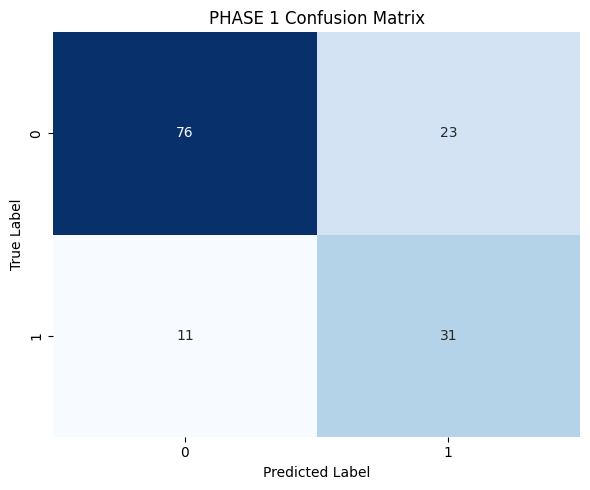


------------------------------------------------------------
TRAINING FOR PHASE 2
------------------------------------------------------------
Original Shape: (141, 908)
Class Distribution: [99 42]

Shape After Variance Threshold: (141, 897)
Shape After SelectKBest: (141, 220)

----- Fold 1 -----
Fold ROC-AUC: 0.6222

----- Fold 2 -----
Fold ROC-AUC: 0.6937

----- Fold 3 -----
Fold ROC-AUC: 0.7125

----- Fold 4 -----
Fold ROC-AUC: 0.8625

----- Fold 5 -----
Fold ROC-AUC: 0.7778

------------------------------------------------------------
FINAL RESULTS FOR PHASE 2
------------------------------------------------------------

Fold ROC-AUC Scores:
[0.6222 0.6938 0.7125 0.8625 0.7778]

Mean Fold ROC-AUC:
0.7337

Overall ROC-AUC:
0.7379

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.79      0.80        99
           1       0.54      0.60      0.57        42

    accuracy                           0.73       141
   macro avg  

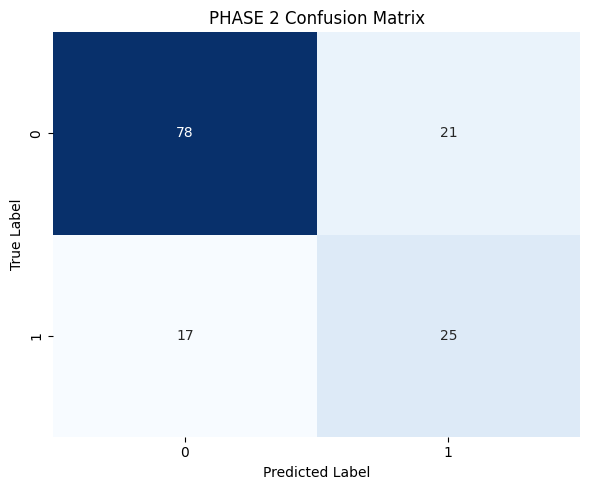


------------------------------------------------------------
TRAINING FOR PHASE 3
------------------------------------------------------------
Original Shape: (141, 908)
Class Distribution: [99 42]

Shape After Variance Threshold: (141, 898)
Shape After SelectKBest: (141, 220)

----- Fold 1 -----
Fold ROC-AUC: 0.6889

----- Fold 2 -----
Fold ROC-AUC: 0.6375

----- Fold 3 -----
Fold ROC-AUC: 0.7438

----- Fold 4 -----
Fold ROC-AUC: 0.7125

----- Fold 5 -----
Fold ROC-AUC: 0.6901

------------------------------------------------------------
FINAL RESULTS FOR PHASE 3
------------------------------------------------------------

Fold ROC-AUC Scores:
[0.6889 0.6375 0.7438 0.7125 0.6901]

Mean Fold ROC-AUC:
0.6945

Overall ROC-AUC:
0.6941

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.73      0.75        99
           1       0.45      0.52      0.48        42

    accuracy                           0.67       141
   macro avg  

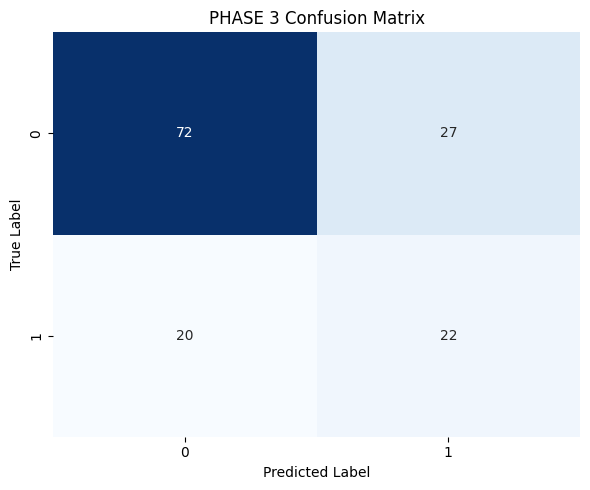


------------------------------------------------------------
FINAL ROC-AUC SCORES
------------------------------------------------------------
Phase 1 ROC-AUC: 0.8254
Phase 1 Precision: 0.5741
Phase 1 Recall: 0.7381
Phase 1 F1 Score: 0.6458

Phase 2 ROC-AUC: 0.7379
Phase 2 Precision: 0.5435
Phase 2 Recall: 0.5952
Phase 2 F1 Score: 0.5682

Phase 3 ROC-AUC: 0.6941
Phase 3 Precision: 0.4490
Phase 3 Recall: 0.5238
Phase 3 F1 Score: 0.4835


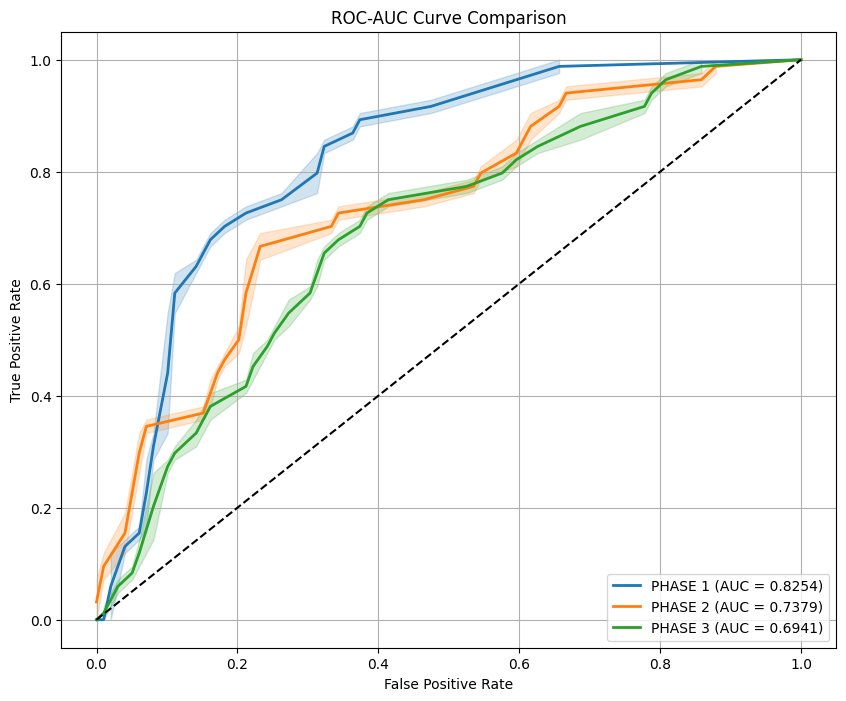

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler

from sklearn.feature_selection import (
    VarianceThreshold,
    SelectKBest,
    mutual_info_classif
)

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_curve
)

# load dataset
df = pd.read_csv("../../data/multimodal_audio_text_features.csv")

print("-" * 60)
print("DATASET INFORMATION")
print("-" * 60)

print("Dataset Shape:", df.shape)

# normalize phase column
df["phase"] = df["phase"].astype(str).str.lower().str.strip()

print("\nAvailable Phases:")
print(df["phase"].unique())

# remove non-feature columns
remove_cols = [
    "participant_id",
    "phase",
    "label"
]

feature_cols = [
    col for col in df.columns
    if col not in remove_cols
]

print("\nTotal Features:", len(feature_cols))

# store roc data
roc_data = {}

# training function
def train_phase_model(df_phase, phase_name):

    print("\n" + "-" * 60)
    print(f"TRAINING FOR {phase_name}")
    print("-" * 60)

    # drop missing values
    df_phase = df_phase.dropna()

    # features & labels
    X = df_phase[feature_cols]
    y = df_phase["label"].values

    print("Original Shape:", X.shape)
    print("Class Distribution:", np.bincount(y))

    # remove low variance features
    variance_selector = VarianceThreshold(
        threshold=0.00001
    )

    X = variance_selector.fit_transform(X)

    print("\nShape After Variance Threshold:", X.shape)

    # keep important multimodal features
    kbest_selector = SelectKBest(
        score_func=mutual_info_classif,
        k=min(220, X.shape[1])
    )

    X = kbest_selector.fit_transform(X, y)

    print("Shape After SelectKBest:", X.shape)

    # 5-fold stratified cv
    skf = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    # store predictions
    all_probs = np.zeros(len(y))
    all_preds = np.zeros(len(y))

    fold_aucs = []

    # train each fold
    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):

        print(f"\n----- Fold {fold} -----")

        X_train, X_test = X[train_idx], X[test_idx]

        y_train, y_test = y[train_idx], y[test_idx]

        # feature scaling
        scaler = StandardScaler()

        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        # logistic regression model
        model = LogisticRegression(

            # better convergence
            solver="saga",

            # moderate regularization
            C=0.8,

            # handle imbalance
            class_weight="balanced",

            # more iterations
            max_iter=5000,

            random_state=42
        )

        # train model
        model.fit(X_train, y_train)

        # predict
        y_prob = model.predict_proba(X_test)[:, 1]

        THRESHOLD = 0.34

        y_pred = (y_prob > THRESHOLD).astype(int)

        # store predictions
        all_probs[test_idx] = y_prob
        all_preds[test_idx] = y_pred

        # fold roc-auc
        fold_auc = roc_auc_score(y_test, y_prob)

        fold_aucs.append(fold_auc)

        print("Fold ROC-AUC:", round(fold_auc, 4))

    # final results
    overall_auc = roc_auc_score(y, all_probs)

    print("\n" + "-" * 60)
    print(f"FINAL RESULTS FOR {phase_name}")
    print("-" * 60)

    print("\nFold ROC-AUC Scores:")
    print(np.round(fold_aucs, 4))

    print("\nMean Fold ROC-AUC:")
    print(round(np.mean(fold_aucs), 4))

    print("\nOverall ROC-AUC:")
    print(round(overall_auc, 4))

    # classification report
    print("\nClassification Report:")
    print(classification_report(
        y,
        all_preds,
        zero_division=0
    ))

    # precision score
    precision = precision_score(
        y,
        all_preds,
        zero_division=0
    )

    print("Precision Score:", round(precision, 4))

    # recall score
    recall = recall_score(
        y,
        all_preds,
        zero_division=0
    )

    print("Recall Score:", round(recall, 4))

    # f1 score
    f1 = f1_score(
        y,
        all_preds,
        zero_division=0
    )

    print("F1 Score:", round(f1, 4))

    # confusion matrix
    cm = confusion_matrix(y, all_preds)

    print("\nConfusion Matrix:")
    print(cm)

    # draw confusion matrix
    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False
    )

    plt.title(f"{phase_name} Confusion Matrix")

    plt.xlabel("Predicted Label")

    plt.ylabel("True Label")

    plt.tight_layout()

    plt.show()

    # roc curve values
    fpr, tpr, _ = roc_curve(y, all_probs)

    roc_data[phase_name] = {
        "fpr": fpr,
        "tpr": tpr,
        "auc": overall_auc
    }

    return overall_auc, precision, recall, f1

# filter data phase-wise
df_p1 = df[df["phase"] == "phase1"]

df_p2 = df[df["phase"] == "phase2"]

df_p3 = df[df["phase"] == "phase3"]

# train models
roc_p1, prec_p1, rec_p1, f1_p1 = train_phase_model(
    df_p1,
    "PHASE 1"
)

roc_p2, prec_p2, rec_p2, f1_p2 = train_phase_model(
    df_p2,
    "PHASE 2"
)

roc_p3, prec_p3, rec_p3, f1_p3 = train_phase_model(
    df_p3,
    "PHASE 3"
)

# final summary
print("\n" + "-" * 60)
print("FINAL ROC-AUC SCORES")
print("-" * 60)

print(f"Phase 1 ROC-AUC: {roc_p1:.4f}")
print(f"Phase 1 Precision: {prec_p1:.4f}")
print(f"Phase 1 Recall: {rec_p1:.4f}")
print(f"Phase 1 F1 Score: {f1_p1:.4f}")

print()

print(f"Phase 2 ROC-AUC: {roc_p2:.4f}")
print(f"Phase 2 Precision: {prec_p2:.4f}")
print(f"Phase 2 Recall: {rec_p2:.4f}")
print(f"Phase 2 F1 Score: {f1_p2:.4f}")

print()

print(f"Phase 3 ROC-AUC: {roc_p3:.4f}")
print(f"Phase 3 Precision: {prec_p3:.4f}")
print(f"Phase 3 Recall: {rec_p3:.4f}")
print(f"Phase 3 F1 Score: {f1_p3:.4f}")

# final roc auc curve
plt.figure(figsize=(10, 8))

for phase_name, values in roc_data.items():

    sns.lineplot(
        x=values["fpr"],
        y=values["tpr"],
        linewidth=2,
        label=f"{phase_name} (AUC = {values['auc']:.4f})"
    )

sns.lineplot(
    x=[0, 1],
    y=[0, 1],
    linestyle="--",
    color="black"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC-AUC Curve Comparison")

plt.legend(loc="lower right")

plt.grid(True)

plt.show()

Logistic Regression 10 folds

------------------------------------------------------------
DATASET INFORMATION
------------------------------------------------------------
Dataset Shape: (423, 911)

Available Phases:
<StringArray>
['phase1', 'phase2', 'phase3']
Length: 3, dtype: str

Total Features: 908

------------------------------------------------------------
TRAINING FOR PHASE 1
------------------------------------------------------------
Original Shape: (141, 908)
Class Distribution: [99 42]

Shape After Variance Threshold: (141, 898)
Shape After SelectKBest: (141, 220)

----- Fold 1 -----
Fold ROC-AUC: 0.6

----- Fold 2 -----
Fold ROC-AUC: 0.75

----- Fold 3 -----
Fold ROC-AUC: 0.85

----- Fold 4 -----
Fold ROC-AUC: 0.975

----- Fold 5 -----
Fold ROC-AUC: 1.0

----- Fold 6 -----
Fold ROC-AUC: 0.925

----- Fold 7 -----
Fold ROC-AUC: 0.85

----- Fold 8 -----
Fold ROC-AUC: 0.75

----- Fold 9 -----
Fold ROC-AUC: 0.925

----- Fold 10 -----
Fold ROC-AUC: 0.8222

---------------------------------------------------

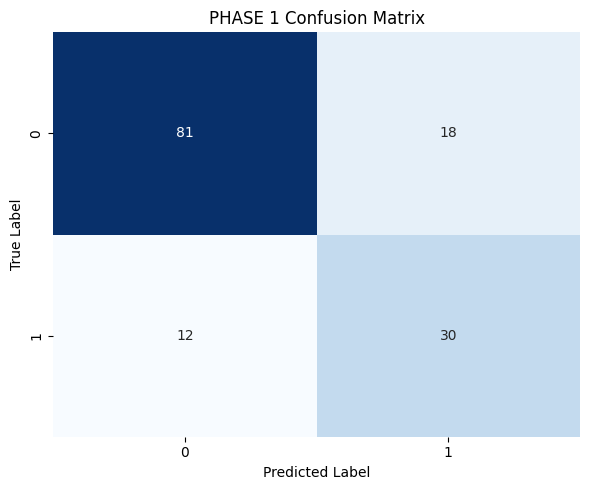


------------------------------------------------------------
TRAINING FOR PHASE 2
------------------------------------------------------------
Original Shape: (141, 908)
Class Distribution: [99 42]

Shape After Variance Threshold: (141, 897)
Shape After SelectKBest: (141, 220)

----- Fold 1 -----
Fold ROC-AUC: 0.68

----- Fold 2 -----
Fold ROC-AUC: 0.7

----- Fold 3 -----
Fold ROC-AUC: 0.575

----- Fold 4 -----
Fold ROC-AUC: 0.775

----- Fold 5 -----
Fold ROC-AUC: 0.925

----- Fold 6 -----
Fold ROC-AUC: 0.725

----- Fold 7 -----
Fold ROC-AUC: 0.775

----- Fold 8 -----
Fold ROC-AUC: 0.925

----- Fold 9 -----
Fold ROC-AUC: 0.7

----- Fold 10 -----
Fold ROC-AUC: 0.7333

------------------------------------------------------------
FINAL RESULTS FOR PHASE 2
------------------------------------------------------------

Fold ROC-AUC Scores:
[0.68   0.7    0.575  0.775  0.925  0.725  0.775  0.925  0.7    0.7333]

Mean Fold ROC-AUC:
0.7513

Overall ROC-AUC:
0.7302

Classification Report:
     

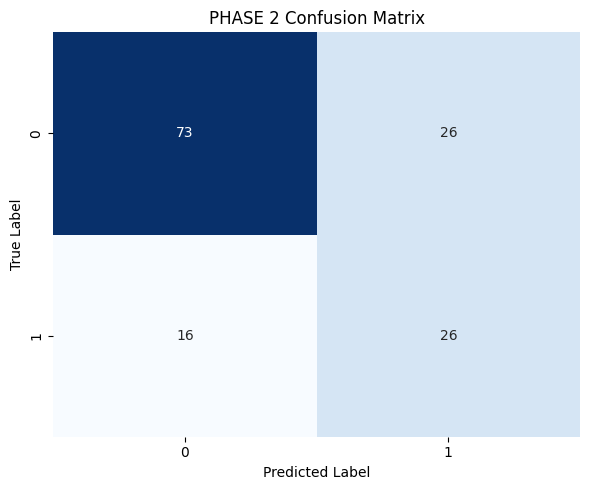


------------------------------------------------------------
TRAINING FOR PHASE 3
------------------------------------------------------------
Original Shape: (141, 908)
Class Distribution: [99 42]

Shape After Variance Threshold: (141, 898)
Shape After SelectKBest: (141, 220)

----- Fold 1 -----
Fold ROC-AUC: 0.6

----- Fold 2 -----
Fold ROC-AUC: 0.925

----- Fold 3 -----
Fold ROC-AUC: 0.525

----- Fold 4 -----
Fold ROC-AUC: 0.825

----- Fold 5 -----
Fold ROC-AUC: 0.625

----- Fold 6 -----
Fold ROC-AUC: 0.775

----- Fold 7 -----
Fold ROC-AUC: 0.8

----- Fold 8 -----
Fold ROC-AUC: 0.8

----- Fold 9 -----
Fold ROC-AUC: 0.675

----- Fold 10 -----
Fold ROC-AUC: 0.6444

------------------------------------------------------------
FINAL RESULTS FOR PHASE 3
------------------------------------------------------------

Fold ROC-AUC Scores:
[0.6    0.925  0.525  0.825  0.625  0.775  0.8    0.8    0.675  0.6444]

Mean Fold ROC-AUC:
0.7194

Overall ROC-AUC:
0.7095

Classification Report:
      

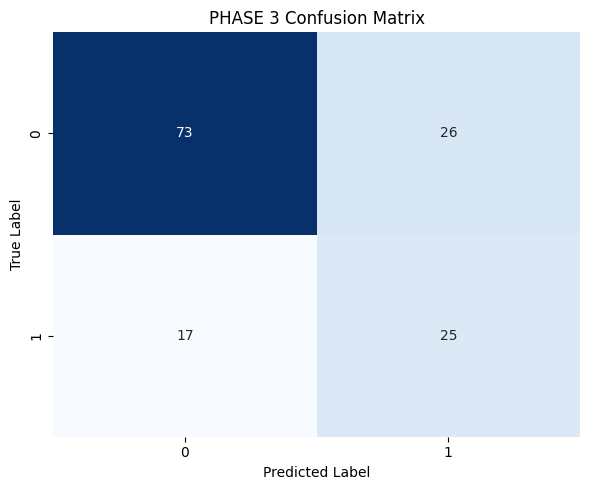


------------------------------------------------------------
FINAL ROC-AUC SCORES
------------------------------------------------------------
Phase 1 ROC-AUC: 0.8297
Phase 1 Precision: 0.6250
Phase 1 Recall: 0.7143
Phase 1 F1 Score: 0.6667

Phase 2 ROC-AUC: 0.7302
Phase 2 Precision: 0.5000
Phase 2 Recall: 0.6190
Phase 2 F1 Score: 0.5532

Phase 3 ROC-AUC: 0.7095
Phase 3 Precision: 0.4902
Phase 3 Recall: 0.5952
Phase 3 F1 Score: 0.5376


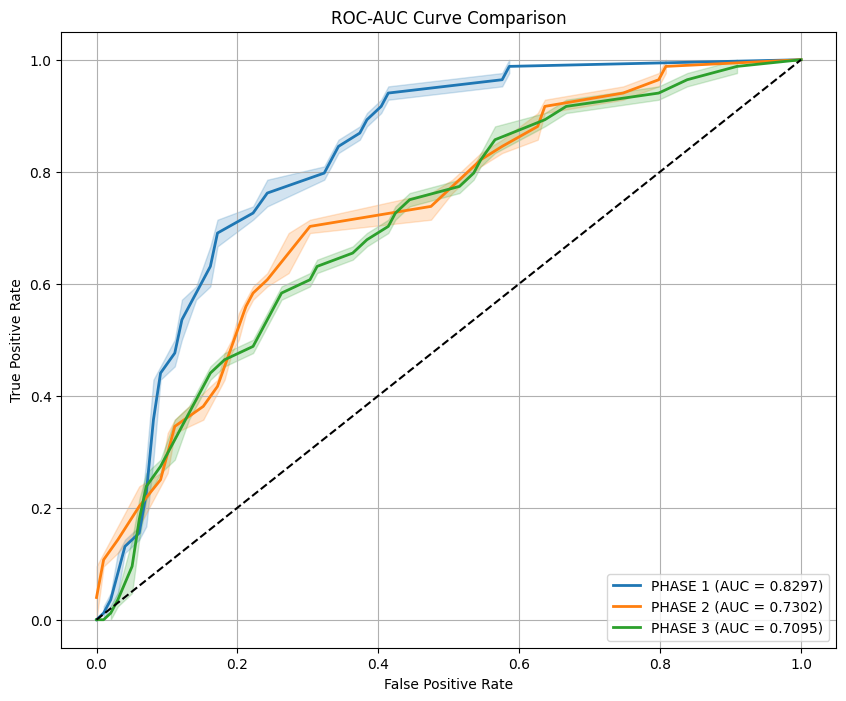

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler

from sklearn.feature_selection import (
    VarianceThreshold,
    SelectKBest,
    mutual_info_classif
)

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_curve
)

# load dataset
df = pd.read_csv("../../data/multimodal_audio_text_features.csv")

print("-" * 60)
print("DATASET INFORMATION")
print("-" * 60)

print("Dataset Shape:", df.shape)

# normalize phase column
df["phase"] = df["phase"].astype(str).str.lower().str.strip()

print("\nAvailable Phases:")
print(df["phase"].unique())

# remove non-feature columns
remove_cols = [
    "participant_id",
    "phase",
    "label"
]

feature_cols = [
    col for col in df.columns
    if col not in remove_cols
]

print("\nTotal Features:", len(feature_cols))

# store roc data
roc_data = {}

# training function
def train_phase_model(df_phase, phase_name):

    print("\n" + "-" * 60)
    print(f"TRAINING FOR {phase_name}")
    print("-" * 60)

    # drop missing values
    df_phase = df_phase.dropna()

    # features & labels
    X = df_phase[feature_cols]
    y = df_phase["label"].values

    print("Original Shape:", X.shape)
    print("Class Distribution:", np.bincount(y))

    # remove low variance features
    variance_selector = VarianceThreshold(
        threshold=0.00001
    )

    X = variance_selector.fit_transform(X)

    print("\nShape After Variance Threshold:", X.shape)

    # keep important multimodal features
    kbest_selector = SelectKBest(
        score_func=mutual_info_classif,
        k=min(220, X.shape[1])
    )

    X = kbest_selector.fit_transform(X, y)

    print("Shape After SelectKBest:", X.shape)

    # 10-fold stratified cv
    skf = StratifiedKFold(
        n_splits=10,
        shuffle=True,
        random_state=42
    )

    # store predictions
    all_probs = np.zeros(len(y))
    all_preds = np.zeros(len(y))

    fold_aucs = []

    # train each fold
    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):

        print(f"\n----- Fold {fold} -----")

        X_train, X_test = X[train_idx], X[test_idx]

        y_train, y_test = y[train_idx], y[test_idx]

        # feature scaling
        scaler = StandardScaler()

        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        # logistic regression model
        model = LogisticRegression(

            # better convergence
            solver="saga",

            # moderate regularization
            C=0.8,

            # handle imbalance
            class_weight="balanced",

            # more iterations
            max_iter=5000,

            random_state=42
        )

        # train model
        model.fit(X_train, y_train)

        # predict
        y_prob = model.predict_proba(X_test)[:, 1]

        THRESHOLD = 0.34

        y_pred = (y_prob > THRESHOLD).astype(int)

        # store predictions
        all_probs[test_idx] = y_prob
        all_preds[test_idx] = y_pred

        # fold roc-auc
        fold_auc = roc_auc_score(y_test, y_prob)

        fold_aucs.append(fold_auc)

        print("Fold ROC-AUC:", round(fold_auc, 4))

    # final results
    overall_auc = roc_auc_score(y, all_probs)

    print("\n" + "-" * 60)
    print(f"FINAL RESULTS FOR {phase_name}")
    print("-" * 60)

    print("\nFold ROC-AUC Scores:")
    print(np.round(fold_aucs, 4))

    print("\nMean Fold ROC-AUC:")
    print(round(np.mean(fold_aucs), 4))

    print("\nOverall ROC-AUC:")
    print(round(overall_auc, 4))

    # classification report
    print("\nClassification Report:")
    print(classification_report(
        y,
        all_preds,
        zero_division=0
    ))

    # precision score
    precision = precision_score(
        y,
        all_preds,
        zero_division=0
    )

    print("Precision Score:", round(precision, 4))

    # recall score
    recall = recall_score(
        y,
        all_preds,
        zero_division=0
    )

    print("Recall Score:", round(recall, 4))

    # f1 score
    f1 = f1_score(
        y,
        all_preds,
        zero_division=0
    )

    print("F1 Score:", round(f1, 4))

    # confusion matrix
    cm = confusion_matrix(y, all_preds)

    print("\nConfusion Matrix:")
    print(cm)

    # draw confusion matrix
    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False
    )

    plt.title(f"{phase_name} Confusion Matrix")

    plt.xlabel("Predicted Label")

    plt.ylabel("True Label")

    plt.tight_layout()

    plt.show()

    # roc curve values
    fpr, tpr, _ = roc_curve(y, all_probs)

    roc_data[phase_name] = {
        "fpr": fpr,
        "tpr": tpr,
        "auc": overall_auc
    }

    return overall_auc, precision, recall, f1

# filter data phase-wise
df_p1 = df[df["phase"] == "phase1"]

df_p2 = df[df["phase"] == "phase2"]

df_p3 = df[df["phase"] == "phase3"]

# train models
roc_p1, prec_p1, rec_p1, f1_p1 = train_phase_model(
    df_p1,
    "PHASE 1"
)

roc_p2, prec_p2, rec_p2, f1_p2 = train_phase_model(
    df_p2,
    "PHASE 2"
)

roc_p3, prec_p3, rec_p3, f1_p3 = train_phase_model(
    df_p3,
    "PHASE 3"
)

# final summary
print("\n" + "-" * 60)
print("FINAL ROC-AUC SCORES")
print("-" * 60)

print(f"Phase 1 ROC-AUC: {roc_p1:.4f}")
print(f"Phase 1 Precision: {prec_p1:.4f}")
print(f"Phase 1 Recall: {rec_p1:.4f}")
print(f"Phase 1 F1 Score: {f1_p1:.4f}")

print()

print(f"Phase 2 ROC-AUC: {roc_p2:.4f}")
print(f"Phase 2 Precision: {prec_p2:.4f}")
print(f"Phase 2 Recall: {rec_p2:.4f}")
print(f"Phase 2 F1 Score: {f1_p2:.4f}")

print()

print(f"Phase 3 ROC-AUC: {roc_p3:.4f}")
print(f"Phase 3 Precision: {prec_p3:.4f}")
print(f"Phase 3 Recall: {rec_p3:.4f}")
print(f"Phase 3 F1 Score: {f1_p3:.4f}")

# final roc auc curve
plt.figure(figsize=(10, 8))

for phase_name, values in roc_data.items():

    sns.lineplot(
        x=values["fpr"],
        y=values["tpr"],
        linewidth=2,
        label=f"{phase_name} (AUC = {values['auc']:.4f})"
    )

sns.lineplot(
    x=[0, 1],
    y=[0, 1],
    linestyle="--",
    color="black"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC-AUC Curve Comparison")

plt.legend(loc="lower right")

plt.grid(True)

plt.show()

CatBoost

------------------------------------------------------------
DATASET INFORMATION
------------------------------------------------------------
Dataset Shape: (423, 911)

Available Phases:
<StringArray>
['phase1', 'phase2', 'phase3']
Length: 3, dtype: str

Total Features: 908

------------------------------------------------------------
TRAINING FOR PHASE 1
------------------------------------------------------------
Original Shape: (141, 908)
Class Distribution: [99 42]

Shape After Variance Threshold: (141, 898)
Shape After SelectKBest: (141, 220)
Class Weights: [1, np.float64(2.393939393939394)]

Predicted Distribution:
[13 16]

Actual Distribution:
[20  9]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.60      0.73        20
           1       0.50      0.89      0.64         9

    accuracy                           0.69        29
   macro avg       0.71      0.74      0.68        29
weighted avg       0.79      0.69    

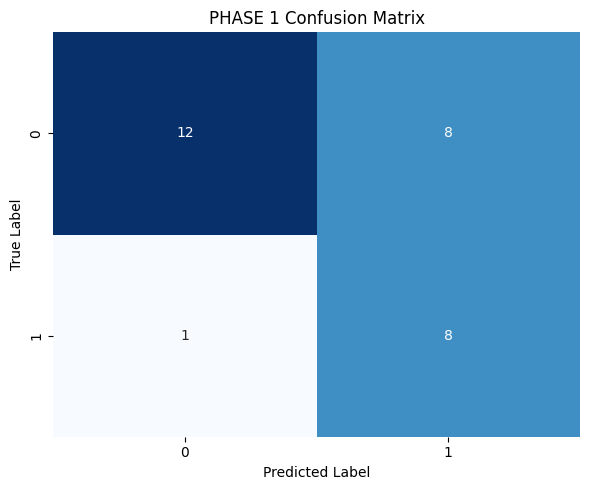


------------------------------------------------------------
TRAINING FOR PHASE 2
------------------------------------------------------------
Original Shape: (141, 908)
Class Distribution: [99 42]

Shape After Variance Threshold: (141, 897)
Shape After SelectKBest: (141, 220)
Class Weights: [1, np.float64(2.393939393939394)]

Predicted Distribution:
[19 10]

Actual Distribution:
[20  9]

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.75      0.77        20
           1       0.50      0.56      0.53         9

    accuracy                           0.69        29
   macro avg       0.64      0.65      0.65        29
weighted avg       0.70      0.69      0.69        29

Precision Score: 0.5
Recall Score: 0.5556
F1 Score: 0.5263
ROC-AUC Score: 0.7667

Confusion Matrix:
[[15  5]
 [ 4  5]]


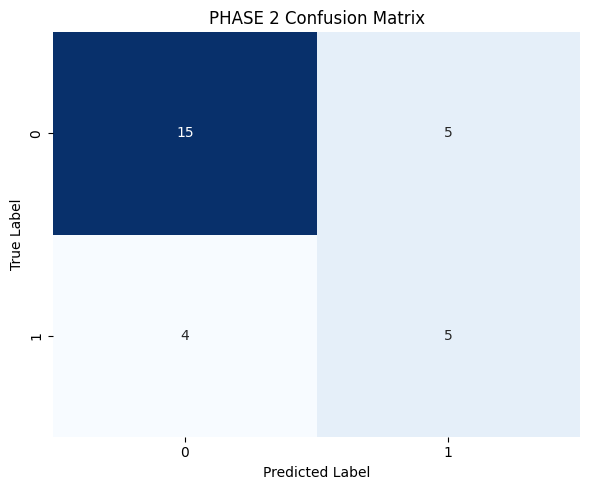


------------------------------------------------------------
TRAINING FOR PHASE 3
------------------------------------------------------------
Original Shape: (141, 908)
Class Distribution: [99 42]

Shape After Variance Threshold: (141, 898)
Shape After SelectKBest: (141, 220)
Class Weights: [1, np.float64(2.393939393939394)]

Predicted Distribution:
[20  9]

Actual Distribution:
[20  9]

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.70      0.70        20
           1       0.33      0.33      0.33         9

    accuracy                           0.59        29
   macro avg       0.52      0.52      0.52        29
weighted avg       0.59      0.59      0.59        29

Precision Score: 0.3333
Recall Score: 0.3333
F1 Score: 0.3333
ROC-AUC Score: 0.4889

Confusion Matrix:
[[14  6]
 [ 6  3]]


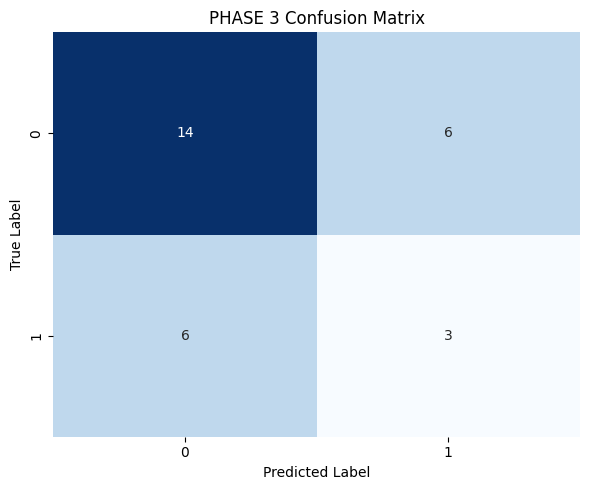


------------------------------------------------------------
FINAL ROC-AUC SCORES
------------------------------------------------------------
Phase 1 ROC-AUC: 0.7444
Phase 1 Precision: 0.5000
Phase 1 Recall: 0.8889
Phase 1 F1 Score: 0.6400

Phase 2 ROC-AUC: 0.7667
Phase 2 Precision: 0.5000
Phase 2 Recall: 0.5556
Phase 2 F1 Score: 0.5263

Phase 3 ROC-AUC: 0.4889
Phase 3 Precision: 0.3333
Phase 3 Recall: 0.3333
Phase 3 F1 Score: 0.3333


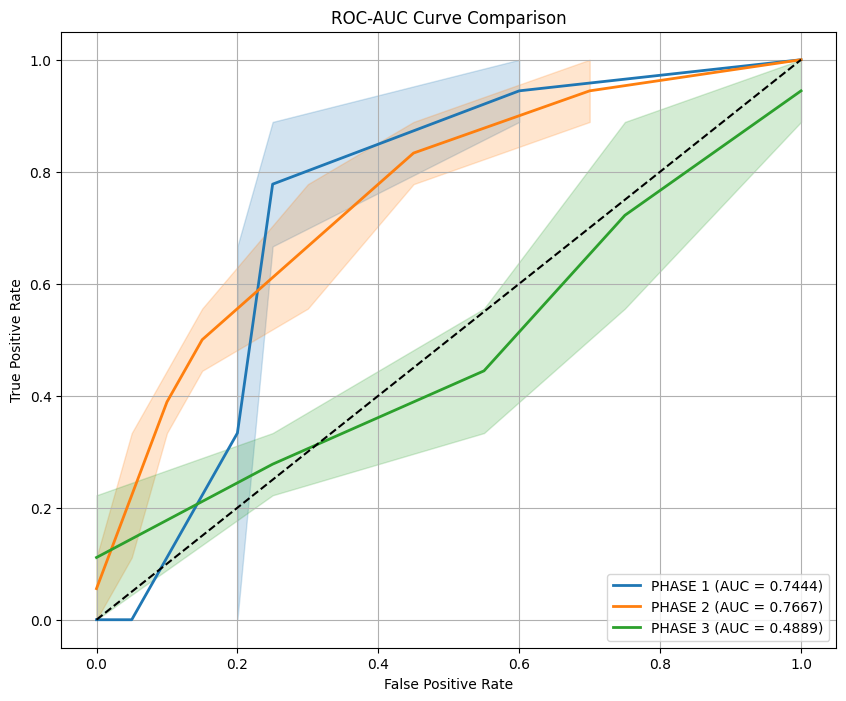

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.feature_selection import (
    VarianceThreshold,
    SelectKBest,
    mutual_info_classif
)

from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_curve
)

from catboost import CatBoostClassifier

# load dataset
df = pd.read_csv("../../data/multimodal_audio_text_features.csv")

print("-" * 60)
print("DATASET INFORMATION")
print("-" * 60)

print("Dataset Shape:", df.shape)

# normalize phase column
df["phase"] = df["phase"].astype(str).str.lower().str.strip()

print("\nAvailable Phases:")
print(df["phase"].unique())

# remove non-feature columns
remove_cols = [
    "participant_id",
    "phase",
    "label"
]

feature_cols = [
    col for col in df.columns
    if col not in remove_cols
]

print("\nTotal Features:", len(feature_cols))

# store roc data
roc_data = {}

# training function
def train_phase_model(df_phase, phase_name):

    print("\n" + "-" * 60)
    print(f"TRAINING FOR {phase_name}")
    print("-" * 60)

    # drop missing values
    df_phase = df_phase.dropna()

    # features & labels
    X = df_phase[feature_cols]
    y = df_phase["label"].values

    print("Original Shape:", X.shape)
    print("Class Distribution:", np.bincount(y))

    # remove low variance features
    variance_selector = VarianceThreshold(
        threshold=0.00001
    )

    X = variance_selector.fit_transform(X)

    print("\nShape After Variance Threshold:", X.shape)

    # keep important multimodal features
    kbest_selector = SelectKBest(
        score_func=mutual_info_classif,
        k=min(220, X.shape[1])
    )

    X = kbest_selector.fit_transform(X, y)

    print("Shape After SelectKBest:", X.shape)

    # train test split
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        stratify=y,
        random_state=42
    )

    # feature scaling
    scaler = StandardScaler()

    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # handle class imbalance
    neg = np.sum(y_train == 0)
    pos = np.sum(y_train == 1)

    class_weights = [
        1,
        neg / pos
    ]

    print("Class Weights:", class_weights)

    # phase-1 optimized multimodal catboost
    model = CatBoostClassifier(

        # core
        loss_function="Logloss",
        eval_metric="AUC",

        # moderate boosting
        iterations=450,

        # simpler trees
        depth=4,

        # slower learning
        learning_rate=0.018,

        # stronger regularization
        l2_leaf_reg=8,

        # lower randomness
        random_strength=1,

        # conservative sampling
        bootstrap_type="Bernoulli",
        subsample=0.75,

        # handle imbalance
        class_weights=class_weights,

        # stable growth
        grow_policy="SymmetricTree",

        random_seed=42,

        verbose=0
    )

    # train model
    model.fit(
        X_train,
        y_train
    )

    # predict probabilities
    y_prob = model.predict_proba(X_test)[:, 1]

    # threshold
    THRESHOLD = 0.36

    y_pred = (y_prob > THRESHOLD).astype(int)

    print("\nPredicted Distribution:")
    print(np.bincount(y_pred))

    print("\nActual Distribution:")
    print(np.bincount(y_test))

    # classification report
    print("\nClassification Report:")
    print(classification_report(
        y_test,
        y_pred,
        zero_division=0
    ))

    # precision score
    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    print("Precision Score:", round(precision, 4))

    # recall score
    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    print("Recall Score:", round(recall, 4))

    # f1 score
    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    print("F1 Score:", round(f1, 4))

    # roc-auc
    roc = roc_auc_score(y_test, y_prob)

    print("ROC-AUC Score:", round(roc, 4))

    # confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    print("\nConfusion Matrix:")
    print(cm)

    # draw confusion matrix
    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False
    )

    plt.title(f"{phase_name} Confusion Matrix")

    plt.xlabel("Predicted Label")

    plt.ylabel("True Label")

    plt.tight_layout()

    plt.show()

    # roc curve values
    fpr, tpr, _ = roc_curve(y_test, y_prob)

    roc_data[phase_name] = {
        "fpr": fpr,
        "tpr": tpr,
        "auc": roc
    }

    return model, roc, precision, recall, f1

# filter data phase-wise
df_p1 = df[df["phase"] == "phase1"]

df_p2 = df[df["phase"] == "phase2"]

df_p3 = df[df["phase"] == "phase3"]

# train models
model_p1, roc_p1, prec_p1, rec_p1, f1_p1 = train_phase_model(
    df_p1,
    "PHASE 1"
)

model_p2, roc_p2, prec_p2, rec_p2, f1_p2 = train_phase_model(
    df_p2,
    "PHASE 2"
)

model_p3, roc_p3, prec_p3, rec_p3, f1_p3 = train_phase_model(
    df_p3,
    "PHASE 3"
)

# final summary
print("\n" + "-" * 60)
print("FINAL ROC-AUC SCORES")
print("-" * 60)

print(f"Phase 1 ROC-AUC: {roc_p1:.4f}")
print(f"Phase 1 Precision: {prec_p1:.4f}")
print(f"Phase 1 Recall: {rec_p1:.4f}")
print(f"Phase 1 F1 Score: {f1_p1:.4f}")

print()

print(f"Phase 2 ROC-AUC: {roc_p2:.4f}")
print(f"Phase 2 Precision: {prec_p2:.4f}")
print(f"Phase 2 Recall: {rec_p2:.4f}")
print(f"Phase 2 F1 Score: {f1_p2:.4f}")

print()

print(f"Phase 3 ROC-AUC: {roc_p3:.4f}")
print(f"Phase 3 Precision: {prec_p3:.4f}")
print(f"Phase 3 Recall: {rec_p3:.4f}")
print(f"Phase 3 F1 Score: {f1_p3:.4f}")

# final roc auc curve
plt.figure(figsize=(10, 8))

for phase_name, values in roc_data.items():

    sns.lineplot(
        x=values["fpr"],
        y=values["tpr"],
        linewidth=2,
        label=f"{phase_name} (AUC = {values['auc']:.4f})"
    )

sns.lineplot(
    x=[0, 1],
    y=[0, 1],
    linestyle="--",
    color="black"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC-AUC Curve Comparison")

plt.legend(loc="lower right")

plt.grid(True)

plt.show()

CatBoost 5 folds

------------------------------------------------------------
DATASET INFORMATION
------------------------------------------------------------
Dataset Shape: (423, 911)

Available Phases:
<StringArray>
['phase1', 'phase2', 'phase3']
Length: 3, dtype: str

Total Features: 908

------------------------------------------------------------
TRAINING FOR PHASE 1
------------------------------------------------------------
Original Shape: (141, 908)
Class Distribution: [99 42]

Shape After Variance Threshold: (141, 898)
Shape After SelectKBest: (141, 220)

----- Fold 1 -----
Fold ROC-AUC: 0.5667

----- Fold 2 -----
Fold ROC-AUC: 0.9187

----- Fold 3 -----
Fold ROC-AUC: 0.8562

----- Fold 4 -----
Fold ROC-AUC: 0.875

----- Fold 5 -----
Fold ROC-AUC: 0.8713

------------------------------------------------------------
FINAL RESULTS FOR PHASE 1
------------------------------------------------------------

Fold ROC-AUC Scores:
[0.5667 0.9188 0.8562 0.875  0.8713]

Mean Fold ROC-AUC:
0.8176

Overal

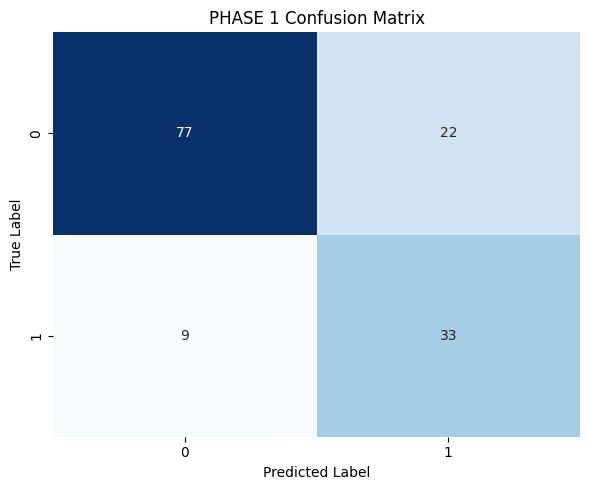


------------------------------------------------------------
TRAINING FOR PHASE 2
------------------------------------------------------------
Original Shape: (141, 908)
Class Distribution: [99 42]

Shape After Variance Threshold: (141, 897)
Shape After SelectKBest: (141, 220)

----- Fold 1 -----
Fold ROC-AUC: 0.7111

----- Fold 2 -----
Fold ROC-AUC: 0.6937

----- Fold 3 -----
Fold ROC-AUC: 0.8187

----- Fold 4 -----
Fold ROC-AUC: 0.9125

----- Fold 5 -----
Fold ROC-AUC: 0.7018

------------------------------------------------------------
FINAL RESULTS FOR PHASE 2
------------------------------------------------------------

Fold ROC-AUC Scores:
[0.7111 0.6938 0.8188 0.9125 0.7018]

Mean Fold ROC-AUC:
0.7676

Overall ROC-AUC:
0.7573

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.77      0.80        99
           1       0.55      0.67      0.60        42

    accuracy                           0.74       141
   macro avg  

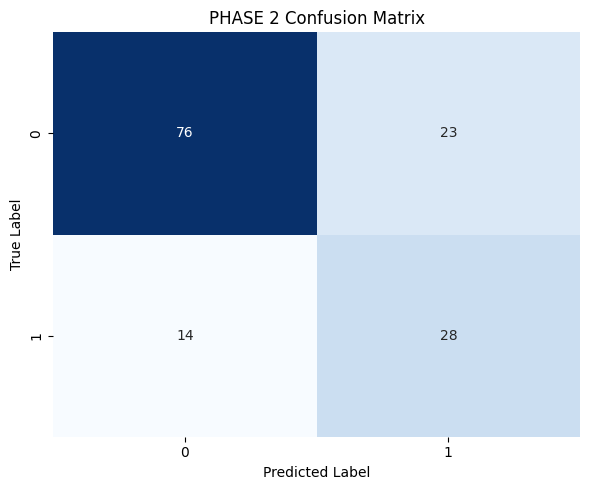


------------------------------------------------------------
TRAINING FOR PHASE 3
------------------------------------------------------------
Original Shape: (141, 908)
Class Distribution: [99 42]

Shape After Variance Threshold: (141, 898)
Shape After SelectKBest: (141, 220)

----- Fold 1 -----
Fold ROC-AUC: 0.7

----- Fold 2 -----
Fold ROC-AUC: 0.5875

----- Fold 3 -----
Fold ROC-AUC: 0.7375

----- Fold 4 -----
Fold ROC-AUC: 0.6188

----- Fold 5 -----
Fold ROC-AUC: 0.538

------------------------------------------------------------
FINAL RESULTS FOR PHASE 3
------------------------------------------------------------

Fold ROC-AUC Scores:
[0.7    0.5875 0.7375 0.6188 0.538 ]

Mean Fold ROC-AUC:
0.6364

Overall ROC-AUC:
0.632

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.65      0.70        99
           1       0.40      0.55      0.46        42

    accuracy                           0.62       141
   macro avg       

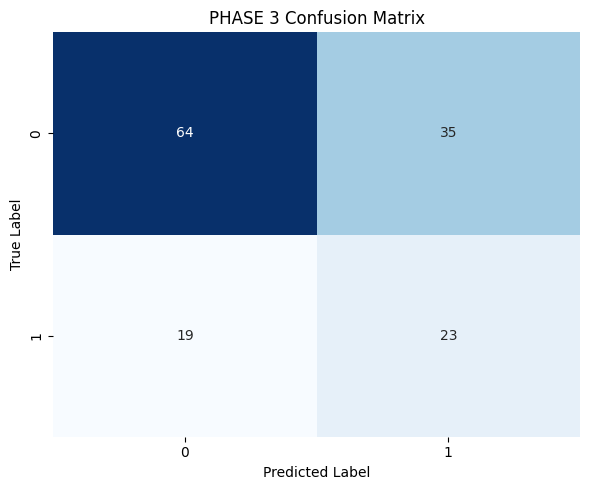


------------------------------------------------------------
FINAL ROC-AUC SCORES
------------------------------------------------------------
Phase 1 ROC-AUC: 0.8064
Phase 1 Precision: 0.6000
Phase 1 Recall: 0.7857
Phase 1 F1 Score: 0.6804

Phase 2 ROC-AUC: 0.7573
Phase 2 Precision: 0.5490
Phase 2 Recall: 0.6667
Phase 2 F1 Score: 0.6022

Phase 3 ROC-AUC: 0.6320
Phase 3 Precision: 0.3966
Phase 3 Recall: 0.5476
Phase 3 F1 Score: 0.4600


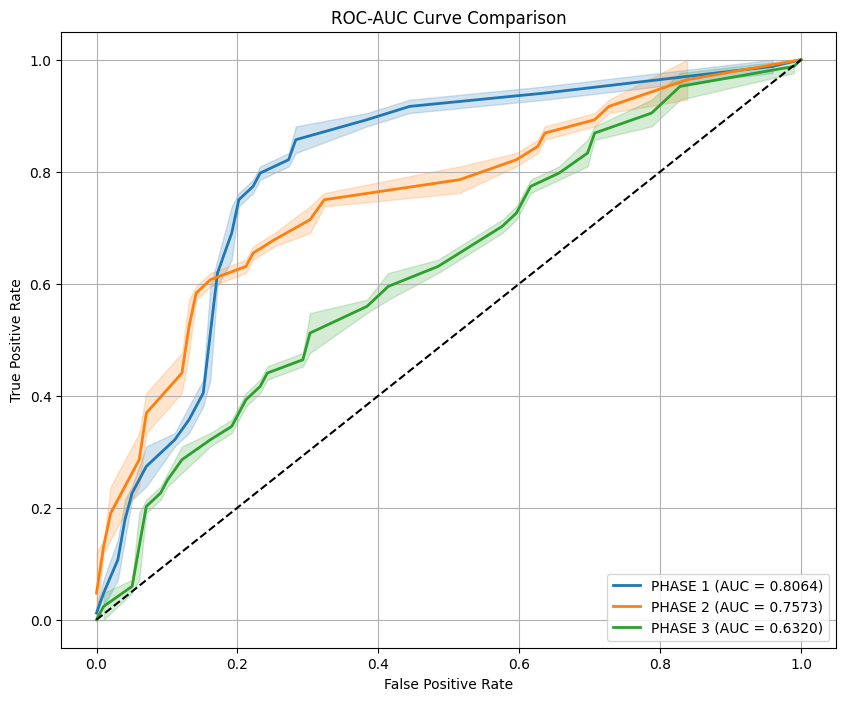

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler

from sklearn.feature_selection import (
    VarianceThreshold,
    SelectKBest,
    mutual_info_classif
)

from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_curve
)

from catboost import CatBoostClassifier

# load dataset
df = pd.read_csv("../../data/multimodal_audio_text_features.csv")

print("-" * 60)
print("DATASET INFORMATION")
print("-" * 60)

print("Dataset Shape:", df.shape)

# normalize phase column
df["phase"] = df["phase"].astype(str).str.lower().str.strip()

print("\nAvailable Phases:")
print(df["phase"].unique())

# remove non-feature columns
remove_cols = [
    "participant_id",
    "phase",
    "label"
]

feature_cols = [
    col for col in df.columns
    if col not in remove_cols
]

print("\nTotal Features:", len(feature_cols))

# store roc data
roc_data = {}

# training function
def train_phase_model(df_phase, phase_name):

    print("\n" + "-" * 60)
    print(f"TRAINING FOR {phase_name}")
    print("-" * 60)

    # drop missing values
    df_phase = df_phase.dropna()

    # features & labels
    X = df_phase[feature_cols]
    y = df_phase["label"].values

    print("Original Shape:", X.shape)
    print("Class Distribution:", np.bincount(y))

    # remove low variance features
    variance_selector = VarianceThreshold(
        threshold=0.00001
    )

    X = variance_selector.fit_transform(X)

    print("\nShape After Variance Threshold:", X.shape)

    # keep important multimodal features
    kbest_selector = SelectKBest(
        score_func=mutual_info_classif,
        k=min(220, X.shape[1])
    )

    X = kbest_selector.fit_transform(X, y)

    print("Shape After SelectKBest:", X.shape)

    # 5-fold stratified cross validation
    skf = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    # store predictions
    all_probs = np.zeros(len(y))
    all_preds = np.zeros(len(y))

    fold_aucs = []

    # train each fold
    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):

        print(f"\n----- Fold {fold} -----")

        X_train, X_test = X[train_idx], X[test_idx]

        y_train, y_test = y[train_idx], y[test_idx]

        # feature scaling
        scaler = StandardScaler()

        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        # handle class imbalance
        neg = np.sum(y_train == 0)
        pos = np.sum(y_train == 1)

        class_weights = [
            1,
            neg / pos
        ]

        # phase-1 optimized multimodal catboost
        model = CatBoostClassifier(

            # core
            loss_function="Logloss",
            eval_metric="AUC",

            # moderate boosting
            iterations=450,

            # simpler trees
            depth=4,

            # slower learning
            learning_rate=0.018,

            # stronger regularization
            l2_leaf_reg=8,

            # lower randomness
            random_strength=1,

            # conservative sampling
            bootstrap_type="Bernoulli",
            subsample=0.75,

            # handle imbalance
            class_weights=class_weights,

            # stable growth
            grow_policy="SymmetricTree",

            random_seed=42,

            verbose=0
        )

        # train model
        model.fit(
            X_train,
            y_train
        )

        # predict
        y_prob = model.predict_proba(X_test)[:, 1]

        THRESHOLD = 0.36

        y_pred = (y_prob > THRESHOLD).astype(int)

        # store predictions
        all_probs[test_idx] = y_prob
        all_preds[test_idx] = y_pred

        # fold roc-auc
        fold_auc = roc_auc_score(y_test, y_prob)

        fold_aucs.append(fold_auc)

        print("Fold ROC-AUC:", round(fold_auc, 4))

    # final results
    overall_auc = roc_auc_score(y, all_probs)

    print("\n" + "-" * 60)
    print(f"FINAL RESULTS FOR {phase_name}")
    print("-" * 60)

    print("\nFold ROC-AUC Scores:")
    print(np.round(fold_aucs, 4))

    print("\nMean Fold ROC-AUC:")
    print(round(np.mean(fold_aucs), 4))

    print("\nOverall ROC-AUC:")
    print(round(overall_auc, 4))

    # classification report
    print("\nClassification Report:")
    print(classification_report(
        y,
        all_preds,
        zero_division=0
    ))

    # precision score
    precision = precision_score(
        y,
        all_preds,
        zero_division=0
    )

    print("Precision Score:", round(precision, 4))

    # recall score
    recall = recall_score(
        y,
        all_preds,
        zero_division=0
    )

    print("Recall Score:", round(recall, 4))

    # f1 score
    f1 = f1_score(
        y,
        all_preds,
        zero_division=0
    )

    print("F1 Score:", round(f1, 4))

    # confusion matrix
    cm = confusion_matrix(y, all_preds)

    print("\nConfusion Matrix:")
    print(cm)

    # draw confusion matrix
    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False
    )

    plt.title(f"{phase_name} Confusion Matrix")

    plt.xlabel("Predicted Label")

    plt.ylabel("True Label")

    plt.tight_layout()

    plt.show()

    # roc curve values
    fpr, tpr, _ = roc_curve(y, all_probs)

    roc_data[phase_name] = {
        "fpr": fpr,
        "tpr": tpr,
        "auc": overall_auc
    }

    return overall_auc, precision, recall, f1

# filter data phase-wise
df_p1 = df[df["phase"] == "phase1"]

df_p2 = df[df["phase"] == "phase2"]

df_p3 = df[df["phase"] == "phase3"]

# train models
roc_p1, prec_p1, rec_p1, f1_p1 = train_phase_model(
    df_p1,
    "PHASE 1"
)

roc_p2, prec_p2, rec_p2, f1_p2 = train_phase_model(
    df_p2,
    "PHASE 2"
)

roc_p3, prec_p3, rec_p3, f1_p3 = train_phase_model(
    df_p3,
    "PHASE 3"
)

# final summary
print("\n" + "-" * 60)
print("FINAL ROC-AUC SCORES")
print("-" * 60)

print(f"Phase 1 ROC-AUC: {roc_p1:.4f}")
print(f"Phase 1 Precision: {prec_p1:.4f}")
print(f"Phase 1 Recall: {rec_p1:.4f}")
print(f"Phase 1 F1 Score: {f1_p1:.4f}")

print()

print(f"Phase 2 ROC-AUC: {roc_p2:.4f}")
print(f"Phase 2 Precision: {prec_p2:.4f}")
print(f"Phase 2 Recall: {rec_p2:.4f}")
print(f"Phase 2 F1 Score: {f1_p2:.4f}")

print()

print(f"Phase 3 ROC-AUC: {roc_p3:.4f}")
print(f"Phase 3 Precision: {prec_p3:.4f}")
print(f"Phase 3 Recall: {rec_p3:.4f}")
print(f"Phase 3 F1 Score: {f1_p3:.4f}")

# final roc auc curve
plt.figure(figsize=(10, 8))

for phase_name, values in roc_data.items():

    sns.lineplot(
        x=values["fpr"],
        y=values["tpr"],
        linewidth=2,
        label=f"{phase_name} (AUC = {values['auc']:.4f})"
    )

sns.lineplot(
    x=[0, 1],
    y=[0, 1],
    linestyle="--",
    color="black"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC-AUC Curve Comparison")

plt.legend(loc="lower right")

plt.grid(True)

plt.show()

CatBoost 10 folds

------------------------------------------------------------
DATASET INFORMATION
------------------------------------------------------------
Dataset Shape: (423, 911)

Available Phases:
<StringArray>
['phase1', 'phase2', 'phase3']
Length: 3, dtype: str

Total Features: 908

------------------------------------------------------------
TRAINING FOR PHASE 1
------------------------------------------------------------
Original Shape: (141, 908)
Class Distribution: [99 42]

Shape After Variance Threshold: (141, 898)
Shape After SelectKBest: (141, 220)

----- Fold 1 -----
Fold ROC-AUC: 0.42

----- Fold 2 -----
Fold ROC-AUC: 0.65

----- Fold 3 -----
Fold ROC-AUC: 0.825

----- Fold 4 -----
Fold ROC-AUC: 1.0

----- Fold 5 -----
Fold ROC-AUC: 0.925

----- Fold 6 -----
Fold ROC-AUC: 0.825

----- Fold 7 -----
Fold ROC-AUC: 0.925

----- Fold 8 -----
Fold ROC-AUC: 0.85

----- Fold 9 -----
Fold ROC-AUC: 0.85

----- Fold 10 -----
Fold ROC-AUC: 0.8667

-------------------------------------------------

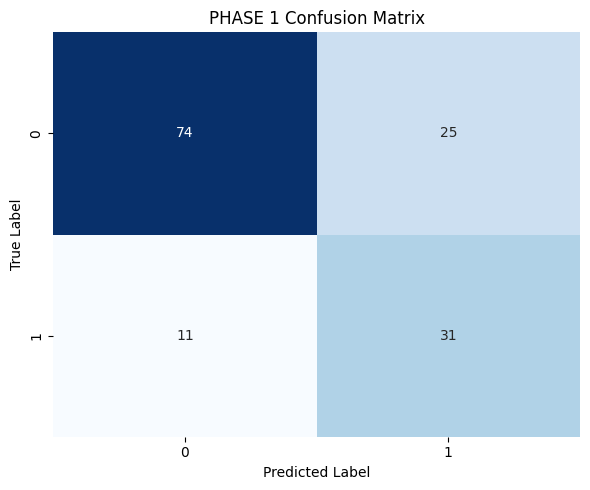


------------------------------------------------------------
TRAINING FOR PHASE 2
------------------------------------------------------------
Original Shape: (141, 908)
Class Distribution: [99 42]

Shape After Variance Threshold: (141, 897)
Shape After SelectKBest: (141, 220)

----- Fold 1 -----
Fold ROC-AUC: 0.78

----- Fold 2 -----
Fold ROC-AUC: 0.875

----- Fold 3 -----
Fold ROC-AUC: 0.7

----- Fold 4 -----
Fold ROC-AUC: 0.575

----- Fold 5 -----
Fold ROC-AUC: 1.0

----- Fold 6 -----
Fold ROC-AUC: 0.725

----- Fold 7 -----
Fold ROC-AUC: 0.75

----- Fold 8 -----
Fold ROC-AUC: 0.875

----- Fold 9 -----
Fold ROC-AUC: 0.65

----- Fold 10 -----
Fold ROC-AUC: 0.7333

------------------------------------------------------------
FINAL RESULTS FOR PHASE 2
------------------------------------------------------------

Fold ROC-AUC Scores:
[0.78   0.875  0.7    0.575  1.     0.725  0.75   0.875  0.65   0.7333]

Mean Fold ROC-AUC:
0.7663

Overall ROC-AUC:
0.7698

Classification Report:
       

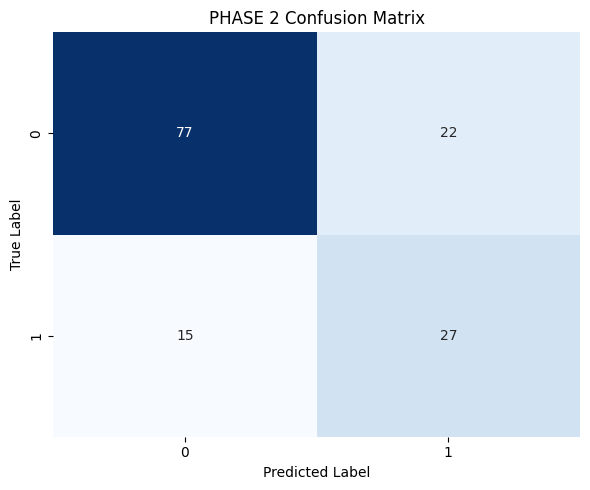


------------------------------------------------------------
TRAINING FOR PHASE 3
------------------------------------------------------------
Original Shape: (141, 908)
Class Distribution: [99 42]

Shape After Variance Threshold: (141, 898)
Shape After SelectKBest: (141, 220)

----- Fold 1 -----
Fold ROC-AUC: 0.64

----- Fold 2 -----
Fold ROC-AUC: 0.925

----- Fold 3 -----
Fold ROC-AUC: 0.475

----- Fold 4 -----
Fold ROC-AUC: 0.75

----- Fold 5 -----
Fold ROC-AUC: 0.725

----- Fold 6 -----
Fold ROC-AUC: 0.575

----- Fold 7 -----
Fold ROC-AUC: 0.65

----- Fold 8 -----
Fold ROC-AUC: 0.825

----- Fold 9 -----
Fold ROC-AUC: 0.425

----- Fold 10 -----
Fold ROC-AUC: 0.6444

------------------------------------------------------------
FINAL RESULTS FOR PHASE 3
------------------------------------------------------------

Fold ROC-AUC Scores:
[0.64   0.925  0.475  0.75   0.725  0.575  0.65   0.825  0.425  0.6444]

Mean Fold ROC-AUC:
0.6634

Overall ROC-AUC:
0.6635

Classification Report:
   

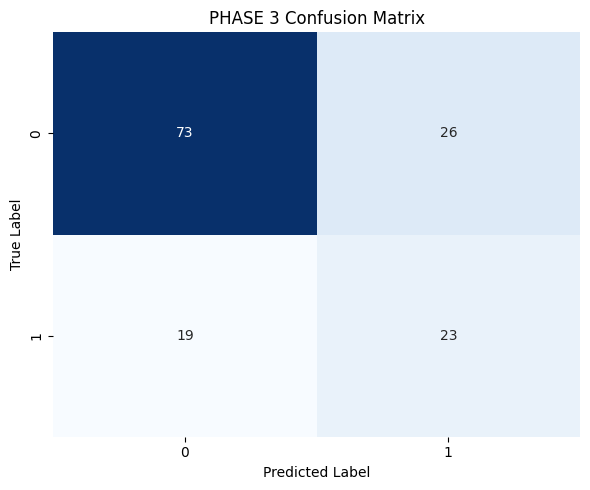


------------------------------------------------------------
FINAL ROC-AUC SCORES
------------------------------------------------------------
Phase 1 ROC-AUC: 0.8011
Phase 1 Precision: 0.5536
Phase 1 Recall: 0.7381
Phase 1 F1 Score: 0.6327

Phase 2 ROC-AUC: 0.7698
Phase 2 Precision: 0.5510
Phase 2 Recall: 0.6429
Phase 2 F1 Score: 0.5934

Phase 3 ROC-AUC: 0.6635
Phase 3 Precision: 0.4694
Phase 3 Recall: 0.5476
Phase 3 F1 Score: 0.5055


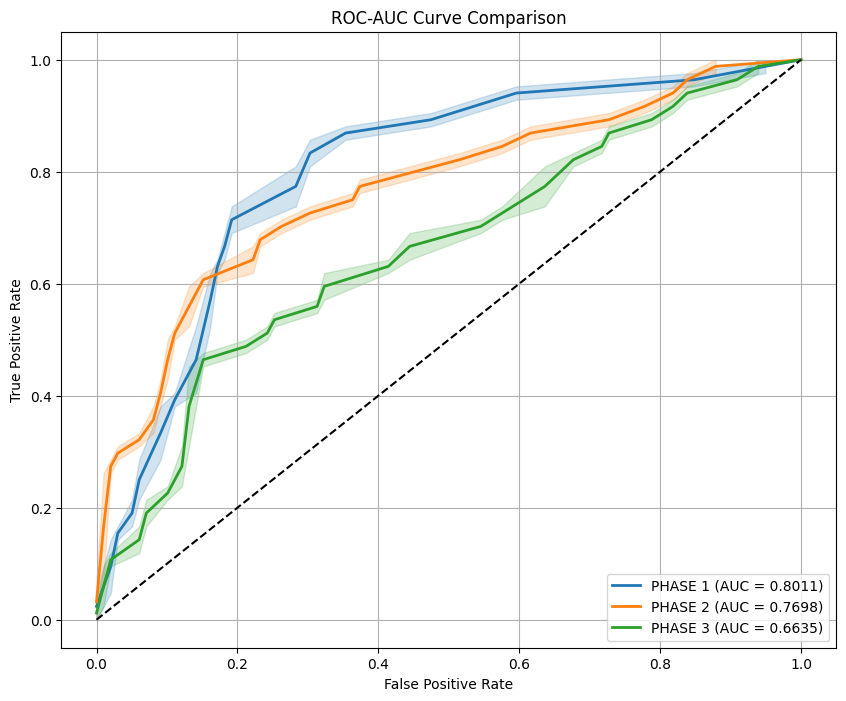

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler

from sklearn.feature_selection import (
    VarianceThreshold,
    SelectKBest,
    mutual_info_classif
)

from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_curve
)

from catboost import CatBoostClassifier

# load dataset
df = pd.read_csv("../../data/multimodal_audio_text_features.csv")

print("-" * 60)
print("DATASET INFORMATION")
print("-" * 60)

print("Dataset Shape:", df.shape)

# normalize phase column
df["phase"] = df["phase"].astype(str).str.lower().str.strip()

print("\nAvailable Phases:")
print(df["phase"].unique())

# remove non-feature columns
remove_cols = [
    "participant_id",
    "phase",
    "label"
]

feature_cols = [
    col for col in df.columns
    if col not in remove_cols
]

print("\nTotal Features:", len(feature_cols))

# store roc data
roc_data = {}

# training function
def train_phase_model(df_phase, phase_name):

    print("\n" + "-" * 60)
    print(f"TRAINING FOR {phase_name}")
    print("-" * 60)

    # drop missing values
    df_phase = df_phase.dropna()

    # features & labels
    X = df_phase[feature_cols]
    y = df_phase["label"].values

    print("Original Shape:", X.shape)
    print("Class Distribution:", np.bincount(y))

    # remove low variance features
    variance_selector = VarianceThreshold(
        threshold=0.00001
    )

    X = variance_selector.fit_transform(X)

    print("\nShape After Variance Threshold:", X.shape)

    # keep important multimodal features
    kbest_selector = SelectKBest(
        score_func=mutual_info_classif,
        k=min(220, X.shape[1])
    )

    X = kbest_selector.fit_transform(X, y)

    print("Shape After SelectKBest:", X.shape)

    # 10-fold stratified cross validation
    skf = StratifiedKFold(
        n_splits=10,
        shuffle=True,
        random_state=42
    )

    # store predictions
    all_probs = np.zeros(len(y))
    all_preds = np.zeros(len(y))

    fold_aucs = []

    # train each fold
    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):

        print(f"\n----- Fold {fold} -----")

        X_train, X_test = X[train_idx], X[test_idx]

        y_train, y_test = y[train_idx], y[test_idx]

        # feature scaling
        scaler = StandardScaler()

        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        # handle class imbalance
        neg = np.sum(y_train == 0)
        pos = np.sum(y_train == 1)

        class_weights = [
            1,
            neg / pos
        ]

        # phase-1 optimized multimodal catboost
        model = CatBoostClassifier(

            # core
            loss_function="Logloss",
            eval_metric="AUC",

            # moderate boosting
            iterations=450,

            # simpler trees
            depth=4,

            # slower learning
            learning_rate=0.018,

            # stronger regularization
            l2_leaf_reg=8,

            # lower randomness
            random_strength=1,

            # conservative sampling
            bootstrap_type="Bernoulli",
            subsample=0.75,

            # handle imbalance
            class_weights=class_weights,

            # stable growth
            grow_policy="SymmetricTree",

            random_seed=42,

            verbose=0
        )

        # train model
        model.fit(
            X_train,
            y_train
        )

        # predict
        y_prob = model.predict_proba(X_test)[:, 1]

        THRESHOLD = 0.36

        y_pred = (y_prob > THRESHOLD).astype(int)

        # store predictions
        all_probs[test_idx] = y_prob
        all_preds[test_idx] = y_pred

        # fold roc-auc
        fold_auc = roc_auc_score(y_test, y_prob)

        fold_aucs.append(fold_auc)

        print("Fold ROC-AUC:", round(fold_auc, 4))

    # final results
    overall_auc = roc_auc_score(y, all_probs)

    print("\n" + "-" * 60)
    print(f"FINAL RESULTS FOR {phase_name}")
    print("-" * 60)

    print("\nFold ROC-AUC Scores:")
    print(np.round(fold_aucs, 4))

    print("\nMean Fold ROC-AUC:")
    print(round(np.mean(fold_aucs), 4))

    print("\nOverall ROC-AUC:")
    print(round(overall_auc, 4))

    # classification report
    print("\nClassification Report:")
    print(classification_report(
        y,
        all_preds,
        zero_division=0
    ))

    # precision score
    precision = precision_score(
        y,
        all_preds,
        zero_division=0
    )

    print("Precision Score:", round(precision, 4))

    # recall score
    recall = recall_score(
        y,
        all_preds,
        zero_division=0
    )

    print("Recall Score:", round(recall, 4))

    # f1 score
    f1 = f1_score(
        y,
        all_preds,
        zero_division=0
    )

    print("F1 Score:", round(f1, 4))

    # confusion matrix
    cm = confusion_matrix(y, all_preds)

    print("\nConfusion Matrix:")
    print(cm)

    # draw confusion matrix
    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False
    )

    plt.title(f"{phase_name} Confusion Matrix")

    plt.xlabel("Predicted Label")

    plt.ylabel("True Label")

    plt.tight_layout()

    plt.show()

    # roc curve values
    fpr, tpr, _ = roc_curve(y, all_probs)

    roc_data[phase_name] = {
        "fpr": fpr,
        "tpr": tpr,
        "auc": overall_auc
    }

    return overall_auc, precision, recall, f1

# filter data phase-wise
df_p1 = df[df["phase"] == "phase1"]

df_p2 = df[df["phase"] == "phase2"]

df_p3 = df[df["phase"] == "phase3"]

# train models
roc_p1, prec_p1, rec_p1, f1_p1 = train_phase_model(
    df_p1,
    "PHASE 1"
)

roc_p2, prec_p2, rec_p2, f1_p2 = train_phase_model(
    df_p2,
    "PHASE 2"
)

roc_p3, prec_p3, rec_p3, f1_p3 = train_phase_model(
    df_p3,
    "PHASE 3"
)

# final summary
print("\n" + "-" * 60)
print("FINAL ROC-AUC SCORES")
print("-" * 60)

print(f"Phase 1 ROC-AUC: {roc_p1:.4f}")
print(f"Phase 1 Precision: {prec_p1:.4f}")
print(f"Phase 1 Recall: {rec_p1:.4f}")
print(f"Phase 1 F1 Score: {f1_p1:.4f}")

print()

print(f"Phase 2 ROC-AUC: {roc_p2:.4f}")
print(f"Phase 2 Precision: {prec_p2:.4f}")
print(f"Phase 2 Recall: {rec_p2:.4f}")
print(f"Phase 2 F1 Score: {f1_p2:.4f}")

print()

print(f"Phase 3 ROC-AUC: {roc_p3:.4f}")
print(f"Phase 3 Precision: {prec_p3:.4f}")
print(f"Phase 3 Recall: {rec_p3:.4f}")
print(f"Phase 3 F1 Score: {f1_p3:.4f}")

# final roc auc curve
plt.figure(figsize=(10, 8))

for phase_name, values in roc_data.items():

    sns.lineplot(
        x=values["fpr"],
        y=values["tpr"],
        linewidth=2,
        label=f"{phase_name} (AUC = {values['auc']:.4f})"
    )

sns.lineplot(
    x=[0, 1],
    y=[0, 1],
    linestyle="--",
    color="black"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC-AUC Curve Comparison")

plt.legend(loc="lower right")

plt.grid(True)

plt.show()

FNN

------------------------------------------------------------
device info
------------------------------------------------------------
Using Device: cuda
GPU: NVIDIA GeForce RTX 3050 Laptop GPU

Dataset Shape: (423, 911)

Available Phases:
<StringArray>
['phase1', 'phase2', 'phase3']
Length: 3, dtype: str

Total Features: 908

------------------------------------------------------------
training for PHASE 1
------------------------------------------------------------
Original Shape: (141, 908)
Class Distribution: [99 42]

Shape After Variance Threshold: (141, 898)
Shape After SelectKBest: (141, 260)

Starting Training...

Epoch [1/70] Loss: 1.0429 AUC: 0.5167
Epoch [2/70] Loss: 1.0417 AUC: 0.5611
Epoch [3/70] Loss: 1.0286 AUC: 0.5778
Epoch [4/70] Loss: 0.9149 AUC: 0.6444
Epoch [5/70] Loss: 0.9418 AUC: 0.6556
Epoch [6/70] Loss: 0.9549 AUC: 0.7000
Epoch [7/70] Loss: 0.9481 AUC: 0.6611
Epoch [8/70] Loss: 0.9334 AUC: 0.6667
Epoch [9/70] Loss: 0.8565 AUC: 0.7000
Epoch [10/70] Loss: 0.8980 AU

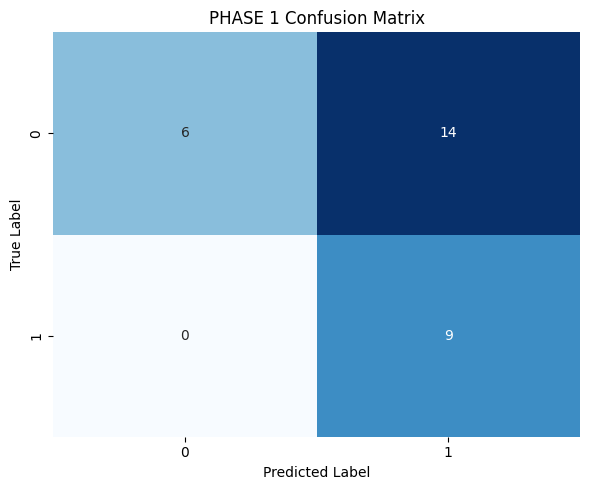


------------------------------------------------------------
training for PHASE 2
------------------------------------------------------------
Original Shape: (141, 908)
Class Distribution: [99 42]

Shape After Variance Threshold: (141, 897)
Shape After SelectKBest: (141, 260)

Starting Training...

Epoch [1/70] Loss: 1.0120 AUC: 0.5667
Epoch [2/70] Loss: 1.0397 AUC: 0.5833
Epoch [3/70] Loss: 0.9819 AUC: 0.6222
Epoch [4/70] Loss: 0.9704 AUC: 0.6056
Epoch [5/70] Loss: 0.9178 AUC: 0.6722
Epoch [6/70] Loss: 0.9533 AUC: 0.6667
Epoch [7/70] Loss: 0.9247 AUC: 0.7000
Epoch [8/70] Loss: 0.8564 AUC: 0.6667
Epoch [9/70] Loss: 0.9387 AUC: 0.6944
Epoch [10/70] Loss: 0.8878 AUC: 0.6833
Epoch [11/70] Loss: 0.8285 AUC: 0.7222
Epoch [12/70] Loss: 0.8520 AUC: 0.7056
Epoch [13/70] Loss: 0.8521 AUC: 0.7278
Epoch [14/70] Loss: 0.8091 AUC: 0.7278
Epoch [15/70] Loss: 0.8161 AUC: 0.7167
Epoch [16/70] Loss: 0.8036 AUC: 0.7278
Epoch [17/70] Loss: 0.7778 AUC: 0.7278
Epoch [18/70] Loss: 0.8058 AUC: 0.7222
Epoch

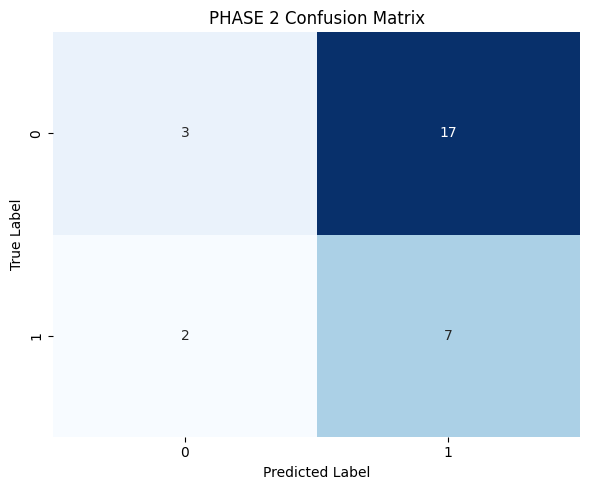


------------------------------------------------------------
training for PHASE 3
------------------------------------------------------------
Original Shape: (141, 908)
Class Distribution: [99 42]

Shape After Variance Threshold: (141, 898)
Shape After SelectKBest: (141, 260)

Starting Training...

Epoch [1/70] Loss: 1.0618 AUC: 0.6944
Epoch [2/70] Loss: 0.9994 AUC: 0.6667
Epoch [3/70] Loss: 0.9472 AUC: 0.6500
Epoch [4/70] Loss: 1.0333 AUC: 0.6333
Epoch [5/70] Loss: 0.9718 AUC: 0.6444
Epoch [6/70] Loss: 0.9534 AUC: 0.6278
Epoch [7/70] Loss: 0.9341 AUC: 0.6611
Epoch [8/70] Loss: 0.9802 AUC: 0.6667
Epoch [9/70] Loss: 0.9126 AUC: 0.6333
Epoch [10/70] Loss: 0.9047 AUC: 0.6500
Epoch [11/70] Loss: 0.9259 AUC: 0.6333
Epoch [12/70] Loss: 0.9127 AUC: 0.6444
Epoch [13/70] Loss: 0.8452 AUC: 0.6222
Epoch [14/70] Loss: 0.8480 AUC: 0.6167
Epoch [15/70] Loss: 0.7753 AUC: 0.6167
Epoch [16/70] Loss: 0.8422 AUC: 0.5944
Epoch [17/70] Loss: 0.8034 AUC: 0.5833
Epoch [18/70] Loss: 0.7728 AUC: 0.5556
Epoch

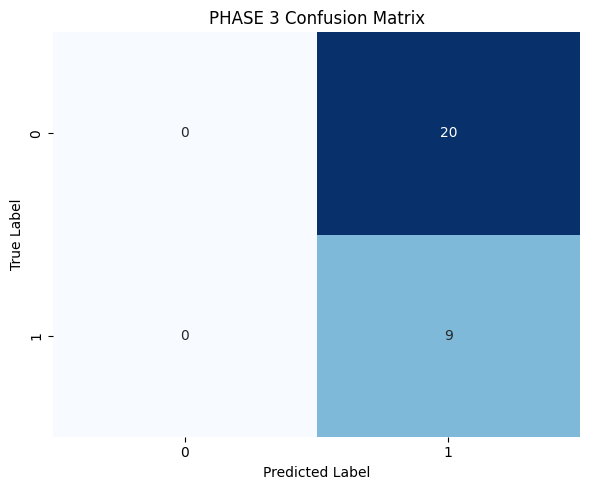


------------------------------------------------------------
final roc-auc scores
------------------------------------------------------------
Phase 1 ROC-AUC: 0.8056
Phase 1 Precision: 0.3913
Phase 1 Recall: 1.0000
Phase 1 F1 Score: 0.5625

Phase 2 ROC-AUC: 0.7500
Phase 2 Precision: 0.2917
Phase 2 Recall: 0.7778
Phase 2 F1 Score: 0.4242

Phase 3 ROC-AUC: 0.6944
Phase 3 Precision: 0.3103
Phase 3 Recall: 1.0000
Phase 3 F1 Score: 0.4737


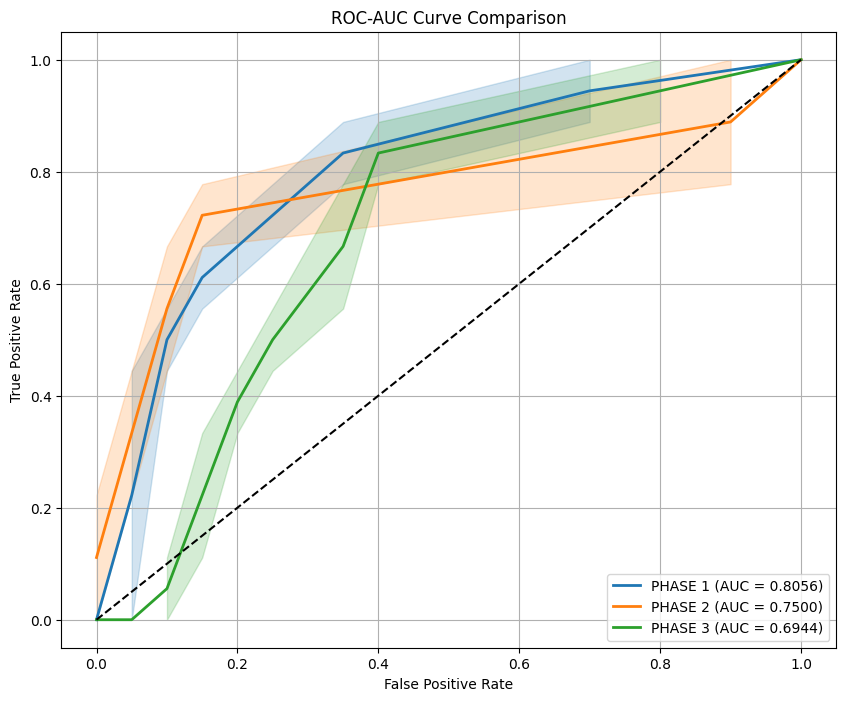

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.feature_selection import (
    VarianceThreshold,
    SelectKBest,
    mutual_info_classif
)

from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_curve
)

# gpu setup

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("-" * 60)
print("device info")
print("-" * 60)

print("Using Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# load dataset

df = pd.read_csv("../../data/multimodal_audio_text_features.csv")

df["phase"] = (
    df["phase"]
    .astype(str)
    .str.lower()
    .str.strip()
)

print("\nDataset Shape:", df.shape)

print("\nAvailable Phases:")
print(df["phase"].unique())

# remove non-feature columns

remove_cols = [
    "participant_id",
    "phase",
    "label"
]

feature_cols = [
    col for col in df.columns
    if col not in remove_cols
]

print("\nTotal Features:", len(feature_cols))

# store roc data

roc_data = {}

# custom dataset

class DepressionDataset(Dataset):

    def __init__(self, X, y):

        self.X = torch.tensor(
            X,
            dtype=torch.float32
        )

        self.y = torch.tensor(
            y,
            dtype=torch.float32
        )

    def __len__(self):

        return len(self.X)

    def __getitem__(self, idx):

        return self.X[idx], self.y[idx]

# phase-1 optimized dnn

class DepressionDNN(nn.Module):

    def __init__(self, input_dim):

        super(DepressionDNN, self).__init__()

        self.network = nn.Sequential(

            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.45),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.40),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.35),

            nn.Linear(64, 1)
        )

    def forward(self, x):

        return self.network(x).squeeze()

# train function

def train_phase_model(df_phase, phase_name):

    print("\n" + "-" * 60)
    print(f"training for {phase_name}")
    print("-" * 60)

    df_phase = df_phase.dropna()

    # features & labels

    X = df_phase[feature_cols]
    y = df_phase["label"].values

    print("Original Shape:", X.shape)

    print("Class Distribution:", np.bincount(y))

    # remove low variance features

    variance_selector = VarianceThreshold(
        threshold=0.00001
    )

    X = variance_selector.fit_transform(X)

    print("\nShape After Variance Threshold:", X.shape)

    # keep important features

    kbest_selector = SelectKBest(
        score_func=mutual_info_classif,
        k=min(260, X.shape[1])
    )

    X = kbest_selector.fit_transform(X, y)

    print("Shape After SelectKBest:", X.shape)

    # train test split

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        stratify=y,
        random_state=42
    )

    # feature scaling

    scaler = StandardScaler()

    X_train = scaler.fit_transform(X_train)

    X_test = scaler.transform(X_test)

    # datasets

    train_dataset = DepressionDataset(
        X_train,
        y_train
    )

    test_dataset = DepressionDataset(
        X_test,
        y_test
    )

    # dataloaders

    train_loader = DataLoader(
        train_dataset,
        batch_size=8,
        shuffle=True
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=8,
        shuffle=False
    )

    # model

    model = DepressionDNN(
        input_dim=X_train.shape[1]
    ).to(device)

    # class weighting

    class_counts = np.bincount(y_train)

    pos_weight = torch.tensor(
        class_counts[0] / class_counts[1],
        dtype=torch.float32
    ).to(device)

    # loss function

    criterion = nn.BCEWithLogitsLoss(
        pos_weight=pos_weight
    )

    # optimizer

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=0.00015,
        weight_decay=1e-3
    )

    # learning rate scheduler

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=70
    )

    # training

    EPOCHS = 70

    best_auc = 0

    best_probs = None

    print("\nStarting Training...\n")

    for epoch in range(EPOCHS):

        model.train()

        total_loss = 0

        for X_batch, y_batch in train_loader:

            X_batch = X_batch.to(device)

            y_batch = y_batch.to(device)

            optimizer.zero_grad()

            outputs = model(X_batch)

            loss = criterion(
                outputs,
                y_batch
            )

            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1.0
            )

            optimizer.step()

            total_loss += loss.item()

        scheduler.step()

        avg_loss = total_loss / len(train_loader)

        # validation

        model.eval()

        val_probs = []

        with torch.no_grad():

            for X_batch, _ in test_loader:

                X_batch = X_batch.to(device)

                outputs = model(X_batch)

                probs = torch.sigmoid(outputs)

                probs = probs.cpu().numpy()

                val_probs.extend(probs)

        val_auc = roc_auc_score(
            y_test,
            val_probs
        )

        if val_auc > best_auc:

            best_auc = val_auc

            best_probs = val_probs.copy()

        print(
            f"Epoch [{epoch+1}/{EPOCHS}] "
            f"Loss: {avg_loss:.4f} "
            f"AUC: {val_auc:.4f}"
        )

    # final evaluation

    final_probs = np.array(best_probs)

    y_pred = (final_probs > 0.36).astype(int)

    print("\nPredicted Distribution:")
    print(np.bincount(y_pred))

    print("\nActual Distribution:")
    print(np.bincount(y_test))

    print("\nClassification Report:")
    print(classification_report(
        y_test,
        y_pred,
        zero_division=0
    ))

    # precision score

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    print("Precision Score:", round(precision, 4))

    # recall score

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    print("Recall Score:", round(recall, 4))

    # f1 score

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    print("F1 Score:", round(f1, 4))

    final_auc = roc_auc_score(
        y_test,
        final_probs
    )

    print("Best ROC-AUC:", round(final_auc, 4))

    # confusion matrix

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    print("\nConfusion Matrix:")
    print(cm)

    # draw confusion matrix

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False
    )

    plt.title(f"{phase_name} Confusion Matrix")

    plt.xlabel("Predicted Label")

    plt.ylabel("True Label")

    plt.tight_layout()

    plt.show()

    # roc curve values

    fpr, tpr, _ = roc_curve(
        y_test,
        final_probs
    )

    roc_data[phase_name] = {
        "fpr": fpr,
        "tpr": tpr,
        "auc": final_auc
    }

    return final_auc, precision, recall, f1

# phase-wise data

df_p1 = df[df["phase"] == "phase1"]

df_p2 = df[df["phase"] == "phase2"]

df_p3 = df[df["phase"] == "phase3"]

# train models

roc_p1, prec_p1, rec_p1, f1_p1 = train_phase_model(
    df_p1,
    "PHASE 1"
)

roc_p2, prec_p2, rec_p2, f1_p2 = train_phase_model(
    df_p2,
    "PHASE 2"
)

roc_p3, prec_p3, rec_p3, f1_p3 = train_phase_model(
    df_p3,
    "PHASE 3"
)

# final results

print("\n" + "-" * 60)
print("final roc-auc scores")
print("-" * 60)

print(f"Phase 1 ROC-AUC: {roc_p1:.4f}")
print(f"Phase 1 Precision: {prec_p1:.4f}")
print(f"Phase 1 Recall: {rec_p1:.4f}")
print(f"Phase 1 F1 Score: {f1_p1:.4f}")

print()

print(f"Phase 2 ROC-AUC: {roc_p2:.4f}")
print(f"Phase 2 Precision: {prec_p2:.4f}")
print(f"Phase 2 Recall: {rec_p2:.4f}")
print(f"Phase 2 F1 Score: {f1_p2:.4f}")

print()

print(f"Phase 3 ROC-AUC: {roc_p3:.4f}")
print(f"Phase 3 Precision: {prec_p3:.4f}")
print(f"Phase 3 Recall: {rec_p3:.4f}")
print(f"Phase 3 F1 Score: {f1_p3:.4f}")

# final roc auc curve

plt.figure(figsize=(10, 8))

for phase_name, values in roc_data.items():

    sns.lineplot(
        x=values["fpr"],
        y=values["tpr"],
        linewidth=2,
        label=f"{phase_name} (AUC = {values['auc']:.4f})"
    )

sns.lineplot(
    x=[0, 1],
    y=[0, 1],
    linestyle="--",
    color="black"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC-AUC Curve Comparison")

plt.legend(loc="lower right")

plt.grid(True)

plt.show()